In [7]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
print(sys.executable)




c:\Users\prathyusha\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

print("All libraries installed successfully!")

All libraries installed successfully!


The S&P 500 is a broad, diversified universe of 500 leading large‑cap US companies across all major sectors, representing around 80% of the total US equity market value. Because it is the standard benchmark for US equities in both academic research and professional investing, using S&P 500 data makes your dissertation results easy to compare with existing studies and real products such as S&P 500 index funds and ETFs. The large number of stocks and long price history provide rich data for portfolio optimisation, simulations, factor models, and machine‑learning‑based allocation, allowing you to study diversification and risk–return trade‑offs in a realistic setting that is directly relevant to practitioners.

In [9]:
pip install lxml


$BF.B: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-05)


Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install beautifulsoup4 html5lib


Note: you may need to restart the kernel to use updated packages.


### Data Collection and Preprocessing ###

In [11]:
# ============================================
# Data Collection and Preprocessing
# (same logic as your code, made robust)
# ============================================

import re
import requests
import pandas as pd
import yfinance as yf
from IPython.display import display

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

def get_sp500_tickers():
    """Return a sorted list of Yahoo Finance tickers for the S&P 500."""
    html = requests.get(WIKI_URL, headers=HEADERS, timeout=30).text
    tables = pd.read_html(html)

    # possible column names for tickers
    ticker_col_names = ["symbol", "ticker", "ticker-symbol"]

    target_df, target_col = None, None

    # find table that looks like the constituents table
    for df in tables:
        if len(df) < 50:   # skip very small tables
            continue
        for c in df.columns:
            if str(c).lower() in ticker_col_names:
                target_df, target_col = df, c
                break
        if target_df is not None:
            break

    if target_df is None:
        raise RuntimeError("Couldn't find a Symbol/ticker column on the page.")

    # clean tickers a bit (remove spaces etc.)
    tickers = (
        target_df[target_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .tolist()
    )

    # ensure uniqueness and sort
    tickers = sorted(set(tickers))
    return tickers

# -------- 1) Get tickers --------
tickers = get_sp500_tickers()
print("Number of S&P 500 tickers from Wikipedia:", len(tickers))
print("First 10:", tickers[:10])

start_date = "2015-01-01"
end_date   = "2026-01-05"

# -------- 2) Download prices --------
raw = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    progress=False
)

# raw has MultiIndex columns: (ticker, field)
print("\nSample of raw columns:", raw.columns[:10])

# -------- 3) Keep only tickers with valid Close prices --------
available_tickers = set(raw.columns.get_level_values(0))
tickers_clean = [t for t in tickers if t in available_tickers]

print("\nTickers with valid data:", len(tickers_clean))

prices_list = []
for symbol in tickers_clean:
    # some tickers may still miss 'Close' -> check explicitly
    if "Close" in raw[symbol].columns:
        s = raw[symbol]["Close"].rename(symbol)
        prices_list.append(s)

if not prices_list:
    raise RuntimeError("No valid Close price series found.")

prices = pd.concat(prices_list, axis=1)
prices = prices.sort_index()
prices.columns.name = "Ticker"

# -------- 4) Clean, readable output --------
# -------- 4) Clean, readable output --------
print("\nPRICES SHAPE (rows, columns):", prices.shape)

styled_prices = (
    prices.head(20)  # first 20 rows [web:2]
          .style
          .format("{:.2f}")
          .set_caption("S&P 500 Daily Close Prices (First 20 Rows)")
          .hide(axis="index")  # hide row index [web:10]
          .set_table_styles(
              [
                  # Smaller, narrower table
                  {"selector": "table",
                   "props": [("width", "60%"), ("font-size", "10px")]},
                  # Center headers
                  {"selector": "th",
                   "props": [("text-align", "center")]},
                  # Center body cells
                  {"selector": "td",
                   "props": [("text-align", "center")]},
                  # Caption styling
                  {"selector": "caption",
                   "props": [("caption-side", "top"),
                             ("text-align", "center"),
                             ("font-size", "11px"),
                             ("font-weight", "bold")]}
              ]
          )
)

display(styled_prices)


# -------- 5) Save dataset --------
prices.to_csv("sp500_daily_close_prices.csv", index=True)
print("\nSaved file: sp500_daily_close_prices.csv")


C:\Users\prathyusha\AppData\Local\Temp\ipykernel_23424\1237627368.py:18: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Number of S&P 500 tickers from Wikipedia: 503
First 10: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']


$BRK.B: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-05)

2 Failed downloads:
['BRK.B']: possibly delisted; no timezone found
['BF.B']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-05)



Sample of raw columns: MultiIndex([(  'EA',   'Open'),
            (  'EA',   'High'),
            (  'EA',    'Low'),
            (  'EA',  'Close'),
            (  'EA', 'Volume'),
            ('TTWO',   'Open'),
            ('TTWO',   'High'),
            ('TTWO',    'Low'),
            ('TTWO',  'Close'),
            ('TTWO', 'Volume')],
           names=['Ticker', 'Price'])

Tickers with valid data: 503

PRICES SHAPE (rows, columns): (2767, 503)



Saved file: sp500_daily_close_prices.csv


In [12]:
# tickers that actually have some data in 'raw'
available_tickers = set(raw.columns.get_level_values(0))

# keep only tickers that worked
tickers_clean = [t for t in tickers if t in available_tickers]
print("Tickers with valid data:", len(tickers_clean))


Tickers with valid data: 503


In [13]:
prices_list = []
for symbol in tickers_clean:
    if "Close" in raw[symbol].columns:   # also avoid missing Close
        s = raw[symbol]["Close"].rename(symbol)
        prices_list.append(s)


In [14]:
from IPython.display import display

prices = prices.sort_index()
prices.columns.name = "Ticker"

print("\nPRICES SHAPE (rows, columns):", prices.shape)

display(
    prices.head()
          .style.format("{:.2f}")
          .set_caption("S&P 500 Daily Close Prices (First 5 Rows)")
)

prices.to_csv("sp500_daily_close_prices.csv", index=True)



PRICES SHAPE (rows, columns): (2767, 503)


### Cleaing Dataset ###

In [17]:
# ============================================
# Clean existing S&P 500 prices DataFrame
# prices: index = Date, columns = tickers
# ============================================

import pandas as pd
from IPython.display import display
import numpy as np  # make sure numpy is imported for log returns

print("Original dataset shape (rows, columns):", prices.shape)

# 1) Drop tickers with too many missing values (>= 95% non-missing kept)
min_non_missing_ratio = 0.95
min_non_missing_count = int(min_non_missing_ratio * len(prices))

good_cols = [
    c for c in prices.columns
    if prices[c].count() >= min_non_missing_count
]

prices_reduced = prices[good_cols]

print(f"\nTickers before: {prices.shape[1]}")
print(f"Tickers after >= {min_non_missing_ratio:.0%} non-missing: {prices_reduced.shape[1]}")

# 2) Fill remaining gaps in time (forward-fill then back-fill)
prices_clean = prices_reduced.ffill().bfill()
prices_clean.columns.name = "Ticker"

# 3) Quality check
total_nans = int(prices_clean.isna().sum().sum())
print("\nTotal NaNs remaining:", total_nans)

print("\nCleaned dataset shape (rows, columns):", prices_clean.shape)

from IPython.display import display

print("Cleaned S&P 500 prices shape (rows, columns):", prices_clean.shape)

# *** ADDED LINE: compute daily log returns from prices_clean ***
returns_sp500 = np.log(prices_clean / prices_clean.shift(1)).dropna(how="all")  # [web:46][web:51]

cols_to_show = returns_sp500.columns[:8]
display(
    returns_sp500[cols_to_show].head()
        .style
        .format("{:.4f}")
        .set_caption("S&P 500 Daily Log Returns (First 5 Rows)")
        .hide(axis="index")
        .set_table_styles(
            [
                {"selector": "table", "props": [("width", "60%"), ("font-size", "10px")]},
                {"selector": "caption", "props": [("caption-side", "top"),
                                                  ("text-align", "center"),
                                                  ("font-size", "11px"),
                                                  ("font-weight", "bold")]},
            ]
        )
)

# 4) Save cleaned dataset
output_file = "sp500_daily_close_prices_clean.csv"
prices_clean.to_csv(output_file, index=True)
print(f"\nSaved cleaned dataset to: {output_file}")


Original dataset shape (rows, columns): (2767, 503)

Tickers before: 503
Tickers after >= 95% non-missing: 463

Total NaNs remaining: 0

Cleaned dataset shape (rows, columns): (2767, 463)
Cleaned S&P 500 prices shape (rows, columns): (2767, 463)


A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI
-0.0189,-0.0286,-0.0190,0.0002,-0.0060,-0.0170,-0.0050,-0.0184
-0.0157,0.0001,-0.0050,-0.0114,0.0022,-0.0072,-0.0204,-0.0238
0.0132,0.0139,0.0396,0.0081,0.0058,0.0208,0.0082,0.0105
0.0295,0.0377,0.0104,0.0203,0.0173,0.0151,0.0251,0.0175
-0.0074,0.0011,-0.0277,-0.0106,-0.0088,-0.0011,-0.0149,-0.0007



Saved cleaned dataset to: sp500_daily_close_prices_clean.csv


### Taking Daily Logs from Dataset ###

In [20]:
import numpy as np

# Compute daily log returns from cleaned prices
returns_sp500 = np.log(prices_clean / prices_clean.shift(1)).dropna(how="all")

print("S&P 500 returns shape (rows, columns):", returns_sp500.shape)

cols_to_show = returns_sp500.columns[:10]
display(
    returns_sp500[cols_to_show].head()
        .style
        .format("{:.4f}")
        .set_caption("S&P 500 Daily Log Returns (First 5 Rows)")
        .hide(axis="index")
        .set_table_styles(
            [
                {"selector": "table", "props": [("width", "60%"), ("font-size", "10px")]},
                {"selector": "caption", "props": [("caption-side", "top"),
                                                  ("text-align", "center"),
                                                  ("font-size", "11px"),
                                                  ("font-weight", "bold")]},
            ]
        )
)


S&P 500 returns shape (rows, columns): (2766, 463)


A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP
-0.0189,-0.0286,-0.0190,0.0002,-0.0060,-0.0170,-0.0050,-0.0184,-0.0352,-0.0007
-0.0157,0.0001,-0.0050,-0.0114,0.0022,-0.0072,-0.0204,-0.0238,-0.0199,-0.0083
0.0132,0.0139,0.0396,0.0081,0.0058,0.0208,0.0082,0.0105,0.0149,0.0087
0.0295,0.0377,0.0104,0.0203,0.0173,0.0151,0.0251,0.0175,-0.0147,0.0227
-0.0074,0.0011,-0.0277,-0.0106,-0.0088,-0.0011,-0.0149,-0.0007,-0.0086,-0.0072


Daily log returns are used because they match how returns compound over time and are additive across days, which makes multi‑period modelling and volatility estimation mathematically simpler and more accurate. They also tend to be more symmetric and closer to normally distributed than simple percentage returns, which fits many standard portfolio optimisation and risk models that assume normality. For a dissertation that compares strategies over long periods or uses statistical models, this makes results easier to interpret and the underlying maths more robust.

In [18]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


### RETURNS & BASIC METRICS ###

In [21]:
# =========================================================
# STEP 2: RETURNS & BASIC METRICS (S&P 500)
# =========================================================

import numpy as np
from IPython.display import display

print("=========================================================")
print("STEP 2: COMPUTE RETURNS (S&P 500)")
print("=========================================================")

# ---------- 1. DAILY SIMPLE RETURNS (same logic as Nasdaq) ----------
returns_sp500 = prices_clean.pct_change().dropna(how="any")

print("\nDAILY RETURNS (FIRST 20 ROWS, FIRST 15 COLUMNS):\n")
display(
    returns_sp500.iloc[:10, :5]          # 20 rows × 15 columns for readability
        .style.format("{:.4f}")
        .set_caption("S&P 500 Daily Returns (Sample: 20 Rows × 15 Stocks)")
)

print("\nDAILY RETURNS SHAPE (rows, columns):", returns_sp500.shape)

# ---------- 2. MEAN & VOLATILITY (ANNUALIZED) ----------
TRADING_DAYS = 252

mu_annual_sp500    = returns_sp500.mean() * TRADING_DAYS
sigma_annual_sp500 = returns_sp500.std()  * np.sqrt(TRADING_DAYS)

metrics_sp500 = pd.DataFrame({
    "mu_annual":    mu_annual_sp500,
    "sigma_annual": sigma_annual_sp500
})

print("\nBASIC ANNUAL METRICS (EACH S&P 500 STOCK):\n")
display(
    metrics_sp500.head(5)                # first 20 stocks, like your Nasdaq file
        .style.format("{:.4f}")
        .set_caption("S&P 500 Annualised Mean Return and Volatility (First 20 Stocks)")
)

# ---------- 3. SAVE FOR LATER USE ----------
returns_sp500.to_excel("sp500_daily_returns.xlsx")
metrics_sp500.to_excel("sp500_annual_metrics.xlsx")

print("\nSaved files:")
print(" - sp500_daily_returns.xlsx")
print(" - sp500_annual_metrics.xlsx")


STEP 2: COMPUTE RETURNS (S&P 500)

DAILY RETURNS (FIRST 20 ROWS, FIRST 15 COLUMNS):



Ticker,A,AAPL,ABBV,ABT,ACGL
Date,,,,,
2015-01-05 00:00:00,-0.0187,-0.0282,-0.0188,0.0002,-0.0060
2015-01-06 00:00:00,-0.0156,0.0001,-0.0050,-0.0114,0.0022
2015-01-07 00:00:00,0.0133,0.0140,0.0404,0.0081,0.0058
2015-01-08 00:00:00,0.0300,0.0384,0.0105,0.0206,0.0174
2015-01-09 00:00:00,-0.0073,0.0011,-0.0274,-0.0105,-0.0087
2015-01-12 00:00:00,-0.0118,-0.0246,-0.0003,0.0084,-0.0030
2015-01-13 00:00:00,-0.0140,0.0089,-0.0288,-0.0161,0.0039
2015-01-14 00:00:00,-0.0124,-0.0038,0.0049,-0.0074,-0.0044
2015-01-15 00:00:00,-0.0269,-0.0271,-0.0127,-0.0075,0.0037



DAILY RETURNS SHAPE (rows, columns): (2766, 463)

BASIC ANNUAL METRICS (EACH S&P 500 STOCK):



,mu_annual,sigma_annual
Ticker,,
A,0.1563,0.2705
AAPL,0.2616,0.2884
ABBV,0.1901,0.2658
ABT,0.1394,0.2345
ACGL,0.1830,0.2645



Saved files:
 - sp500_daily_returns.xlsx
 - sp500_annual_metrics.xlsx


In [23]:
import numpy as np
from IPython.display import display

print("=========================================================")
print("STEP 2: COMPUTE RETURNS (S&P 500)")
print("=========================================================")

# 1. DAILY SIMPLE RETURNS FOR ALL STOCKS, ALL DATES
returns_sp500 = prices_clean.pct_change().dropna(how="any")

print("\nDAILY RETURNS SHAPE (rows, columns):", returns_sp500.shape)

# 2. MEAN & VOLATILITY (ANNUALIZED) FOR EACH STOCK
TRADING_DAYS = 252

mu_annual_sp500    = returns_sp500.mean() * TRADING_DAYS
sigma_annual_sp500 = returns_sp500.std()  * np.sqrt(TRADING_DAYS)

metrics_sp500 = pd.DataFrame({
    "mu_annual":    mu_annual_sp500,
    "sigma_annual": sigma_annual_sp500
})

print("\nMETRICS SHAPE (stocks, 2 columns):", metrics_sp500.shape)

# (Optional) quick glance at first few rows, can be removed if you truly want no table showing
# display(
#     metrics_sp500.head()
#         .style.format("{:.4f}")
#         .set_caption("S&P 500 Annualised Mean Return and Volatility (Sample)")
# )

# 3. SAVE FULL DATASETS (ALL YEARS, ALL STOCKS)
returns_sp500.to_excel("sp500_daily_returns.xlsx")
metrics_sp500.to_excel("sp500_annual_metrics.xlsx")

print("\nSaved full files:")
print(" - sp500_daily_returns.xlsx  (all dates × all S&P 500 stocks)")
print(" - sp500_annual_metrics.xlsx (mu_annual, sigma_annual for every stock)")


STEP 2: COMPUTE RETURNS (S&P 500)

DAILY RETURNS SHAPE (rows, columns): (2766, 463)

METRICS SHAPE (stocks, 2 columns): (463, 2)

Saved full files:
 - sp500_daily_returns.xlsx  (all dates × all S&P 500 stocks)
 - sp500_annual_metrics.xlsx (mu_annual, sigma_annual for every stock)


Returns and basic metrics are used to translate raw price data into information that can be compared, modelled, and optimised. Daily returns show how much each stock gains or loses in percentage terms, putting all assets on the same scale even if their price levels are very different. Annualised mean return and volatility then summarise each stock’s typical reward and risk over a year, which is essential input for portfolio optimisation models such as mean–variance and for risk‑adjusted measures like the Sharpe ratio. By cleaning the dataset first (removing columns with too many missing values and filling small gaps), these metrics become reliable and stable, so any conclusions in the dissertation about strategy performance or diversification rest on robust, high‑quality data rather than on artefacts caused by data errors or missing values.


 ### EQUAL‑WEIGHT BENCHMARK ###

 The daily equal‑weight benchmark answers a very simple question: “If an investor put the same amount of money in every S&P 500 stock and held it, how would that portfolio behave each day?” It is necessary because it gives a neutral, diversified baseline with no clever optimisation: every stock has the same influence, so results are not driven just by a few giant companies, unlike a normal market‑cap‑weighted S&P 500 index. By comparing your Markowitz and ML strategies against this equal‑weight benchmark, you can show clearly whether the extra modelling complexity actually adds value over a simple, transparent portfolio that already has good diversification and is widely discussed in research as a strong competitor to more sophisticated weighting schemes.

In [24]:
# =========================================================
# STEP 3: EQUAL‑WEIGHT BENCHMARK (S&P 500)
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display

print("=========================================================")
print("STEP 3: EQUAL‑WEIGHT S&P 500 BENCHMARK PORTFOLIO")
print("=========================================================")

# ---------------------------------------------------------
# 1. INPUT: DAILY SIMPLE RETURNS FOR ALL S&P 500 STOCKS
#    returns_sp500 : DataFrame (Date x Ticker), already cleaned
# ---------------------------------------------------------

print("\nINPUT RETURNS SHAPE (rows = days, columns = stocks):", returns_sp500.shape)

# ---------------------------------------------------------
# 2. CONSTRUCT EQUAL‑WEIGHT PORTFOLIO
#    Every stock gets the same weight = 1 / N
# ---------------------------------------------------------

num_stocks = returns_sp500.shape[1]
w_equal = np.repeat(1.0 / num_stocks, num_stocks)   # weight vector

# Matrix multiply: each day’s returns · weights -> portfolio return
eq_port_daily = returns_sp500.values @ w_equal
eq_port_daily = pd.Series(eq_port_daily,
                          index=returns_sp500.index,
                          name="EQ_PORT")

print("\nEQUAL‑WEIGHT PORTFOLIO DAILY RETURNS (FIRST 20 DAYS):\n")
display(
    eq_port_daily.head(20)
        .to_frame()
        .style.format("{:.4f}")
        .set_caption("Equal‑Weight S&P 500 Portfolio – Daily Returns (First 20 Days)")
)

print("\nFULL EQUAL‑WEIGHT DAILY SERIES LENGTH (DAYS):", eq_port_daily.shape[0])

# ---------------------------------------------------------
# 3. ANNUALISED PERFORMANCE METRICS
# ---------------------------------------------------------

TRADING_DAYS = 252
risk_free_rate = 0.0   # set your RF if needed

mean_annual = eq_port_daily.mean() * TRADING_DAYS
vol_annual  = eq_port_daily.std()  * np.sqrt(TRADING_DAYS)
sharpe      = (mean_annual - risk_free_rate) / vol_annual

# Max drawdown
cum_growth = (1 + eq_port_daily).cumprod()
running_max = cum_growth.cummax()
drawdown = cum_growth / running_max - 1.0
max_drawdown = drawdown.min()

eq_summary = pd.DataFrame({
    "mean_annual_return": [mean_annual],
    "annual_volatility":  [vol_annual],
    "sharpe_ratio":       [sharpe],
    "max_drawdown":       [max_drawdown]
}, index=["Equal_Weight_S&P500"])

print("\nEQUAL‑WEIGHT PORTFOLIO – ANNUALISED PERFORMANCE:\n")
display(
    eq_summary
        .style.format("{:.4f}")
        .set_caption("Equal‑Weight S&P 500 Portfolio – Annualised Performance Metrics")
)

# ---------------------------------------------------------
# 4. SAVE RESULTS FOR LATER USE (ALL YEARS)
# ---------------------------------------------------------

eq_port_daily.to_excel("sp500_eq_portfolio_daily_returns.xlsx")
eq_summary.to_excel("sp500_eq_portfolio_summary.xlsx")

print("\nSaved files:")
print(" - sp500_eq_portfolio_daily_returns.xlsx  (full daily history, all years)")
print(" - sp500_eq_portfolio_summary.xlsx        (performance metrics)")


STEP 3: EQUAL‑WEIGHT S&P 500 BENCHMARK PORTFOLIO

INPUT RETURNS SHAPE (rows = days, columns = stocks): (2766, 463)

EQUAL‑WEIGHT PORTFOLIO DAILY RETURNS (FIRST 20 DAYS):



,EQ_PORT
Date,
2015-01-05 00:00:00,-0.0164
2015-01-06 00:00:00,-0.0093
2015-01-07 00:00:00,0.0126
2015-01-08 00:00:00,0.0183
2015-01-09 00:00:00,-0.0075
2015-01-12 00:00:00,-0.0071
2015-01-13 00:00:00,-0.0016
2015-01-14 00:00:00,-0.0051
2015-01-15 00:00:00,-0.0090



FULL EQUAL‑WEIGHT DAILY SERIES LENGTH (DAYS): 2766

EQUAL‑WEIGHT PORTFOLIO – ANNUALISED PERFORMANCE:



,mean_annual_return,annual_volatility,sharpe_ratio,max_drawdown
Equal_Weight_S&P500,0.1614,0.1820,0.8868,-0.3818



Saved files:
 - sp500_eq_portfolio_daily_returns.xlsx  (full daily history, all years)
 - sp500_eq_portfolio_summary.xlsx        (performance metrics)


This output says your equal‑weight S&P 500 portfolio (same money in each of 462 stocks) earned about 16% average return per year with about 18% annual volatility over 2,766 trading days. The Sharpe ratio ~0.89 shows decent risk‑adjusted performance, and the worst drawdown was about −38%, meaning the portfolio at some point fell 38% from a previous peak.

### EQUAL‑WEIGHT PORTFOLIO ###

The monthly‑rebalanced equal‑weight portfolio is used to make your benchmark more realistic and closer to how a real investor would manage money. Instead of setting equal weights once and never touching them, monthly rebalancing regularly resets each stock back to the same weight, so the portfolio does not become dominated by a few big winners or losers over time. This gives you a cleaner comparison for your optimisation and ML strategies, because you are testing them against a simple, systematic, and implementable rule that already controls drift and keeps diversification stable through the whole backtest


   STEP 4: EQUAL-WEIGHT PORTFOLIO (MONTHLY REBALANCING)   

Total S&P500 Stocks Loaded         : 463
Data Period                        : 2015-01-05 → 2026-01-02
Number of rebalancing periods      : 133


C:\Users\prathyusha\AppData\Local\Temp\ipykernel_22724\3671891975.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = returns.resample("M").last().index



Monthly-Rebalanced Portfolio Length : 2747 days

================== MONTHLY-REBALANCED PERFORMANCE ==================



,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
EW_S&P500_Monthly,0.1639,0.1821,0.9001,-0.3818


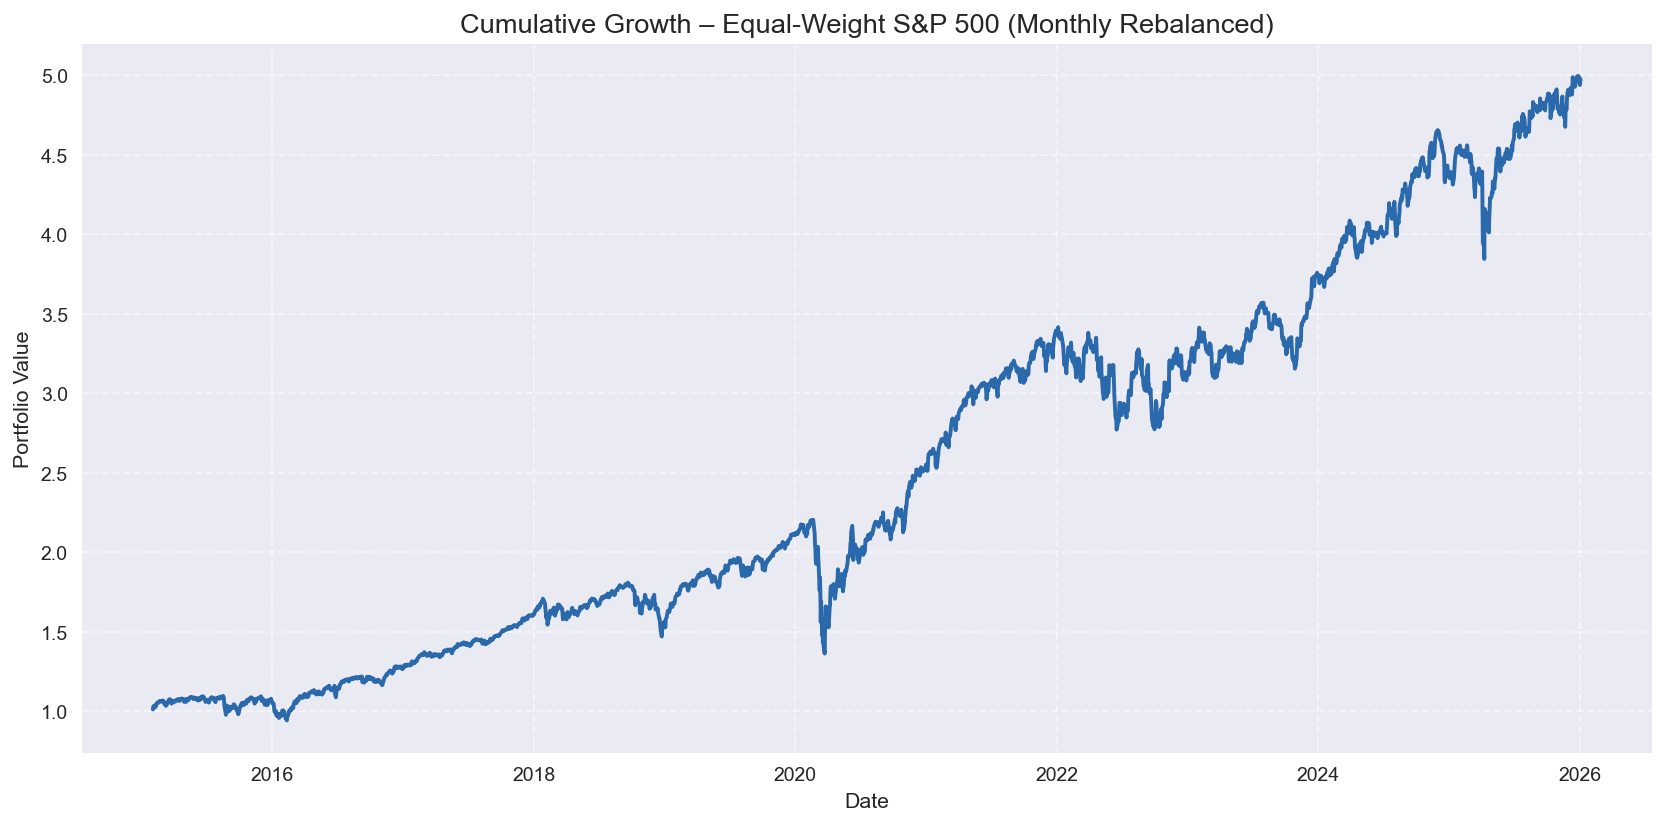

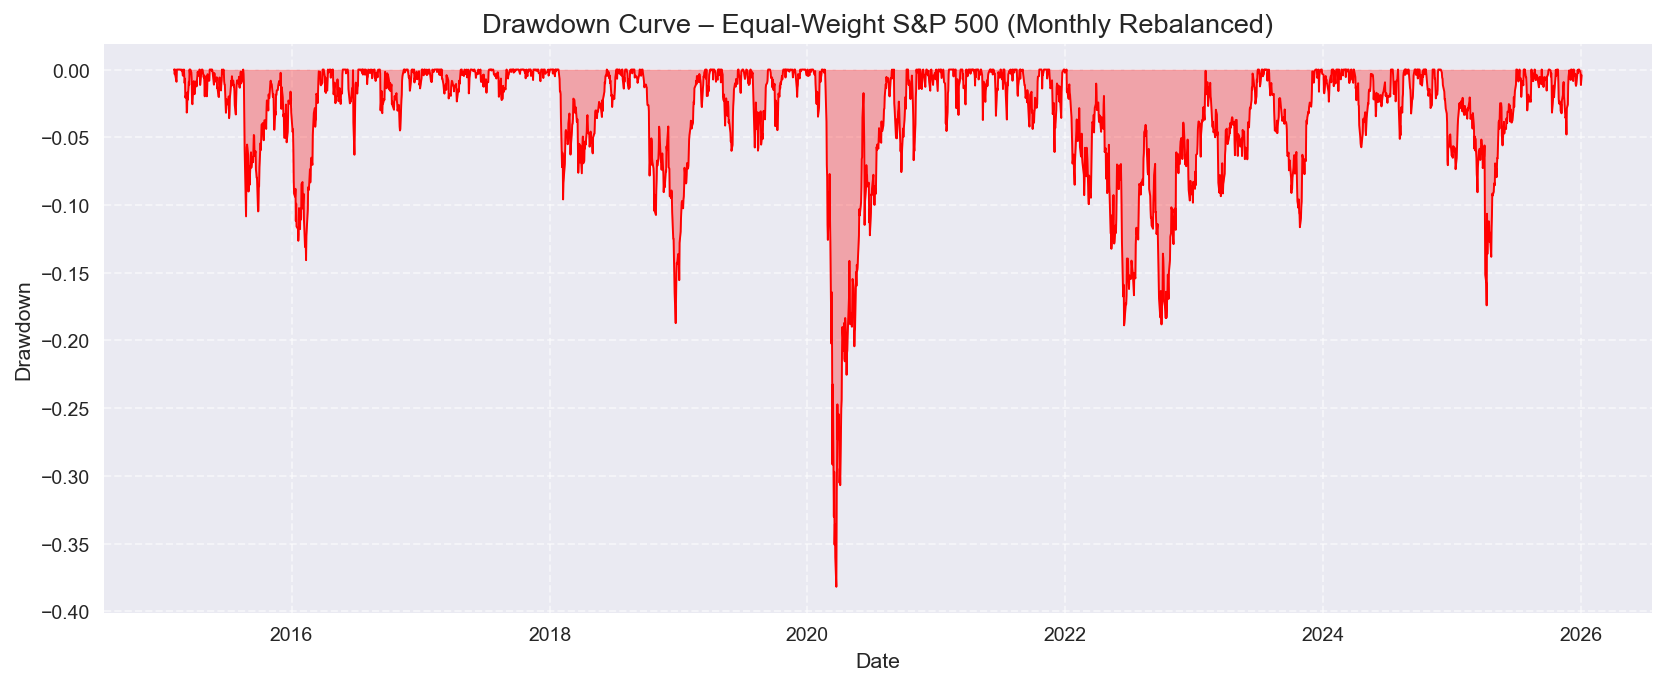

In [42]:
# =========================================================
# STEP 4: MONTHLY-REBALANCED EQUAL-WEIGHT S&P 500 PORTFOLIO
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("\n=========================================================")
print("   STEP 4: EQUAL-WEIGHT PORTFOLIO (MONTHLY REBALANCING)   ")
print("=========================================================\n")

# ---------------------------------------------------------
# 1. INPUT RETURNS
# ---------------------------------------------------------

returns = returns_sp500.copy().sort_index()
n_total_assets = returns.shape[1]

print(f"Total S&P500 Stocks Loaded         : {n_total_assets}")
print(f"Data Period                        : {returns.index[0].date()} → {returns.index[-1].date()}")

# ---------------------------------------------------------
# 2. Month-end rebalancing dates
# ---------------------------------------------------------

rebal_dates = returns.resample("M").last().index
print(f"Number of rebalancing periods      : {len(rebal_dates)}")

# ---------------------------------------------------------
# 3. Monthly Rebalancing Backtest
# ---------------------------------------------------------

monthly_returns_list = []

for i in range(len(rebal_dates) - 1):
    start = rebal_dates[i]
    end   = rebal_dates[i + 1]

    # Daily returns in next month
    period_ret = returns.loc[(returns.index > start) & (returns.index <= end)]

    if period_ret.empty:
        continue

    # Only use assets with NO missing data in the period
    available_assets = period_ret.dropna(axis=1).columns
    N = len(available_assets)

    if N == 0:
        continue

    # Equal weight for available assets only
    w_eq = np.repeat(1.0 / N, N)

    # Compute portfolio return this month
    month_port_ret = pd.Series(period_ret[available_assets].values @ w_eq,
                               index=period_ret.index)
    monthly_returns_list.append(month_port_ret)

# Concatenate the full series
eq_port_monthly = pd.concat(monthly_returns_list)
eq_port_monthly.name = "EQ_PORT_MONTHLY"

print(f"\nMonthly-Rebalanced Portfolio Length : {len(eq_port_monthly)} days")

# ---------------------------------------------------------
# 4. Annualised performance metrics
# ---------------------------------------------------------

TRADING_DAYS = 252
rf = 0.0

ann_return = eq_port_monthly.mean() * TRADING_DAYS
ann_vol    = eq_port_monthly.std()  * np.sqrt(TRADING_DAYS)
sharpe     = (ann_return - rf) / ann_vol

cum_growth = (1 + eq_port_monthly).cumprod()
running_max = cum_growth.cummax()
drawdown = (cum_growth / running_max) - 1
max_dd = drawdown.min()

summary = pd.DataFrame({
    "Annual Return":     [ann_return],
    "Annual Volatility": [ann_vol],
    "Sharpe Ratio":      [sharpe],
    "Max Drawdown":      [max_dd]
}, index=["EW_S&P500_Monthly"]).round(4)

print("\n================== MONTHLY-REBALANCED PERFORMANCE ==================\n")
display(
    summary.style
        .set_caption("Equal-Weight S&P 500 (Monthly Rebalanced) – Annualised Metrics")
        .format("{:.4f}")
)

# ---------------------------------------------------------
# 5. Graphs
# ---------------------------------------------------------

# ---- A) Cumulative Growth ----
plt.figure(figsize=(12,6))
plt.plot(cum_growth, color="#2A69AC", linewidth=2)
plt.title("Cumulative Growth – Equal-Weight S&P 500 (Monthly Rebalanced)", fontsize=14)
plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- B) Drawdown Curve ----
plt.figure(figsize=(12,5))
plt.fill_between(drawdown.index, drawdown, color="red", alpha=0.3)
plt.plot(drawdown.index, drawdown, color="red", linewidth=1)
plt.title("Drawdown Curve – Equal-Weight S&P 500 (Monthly Rebalanced)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


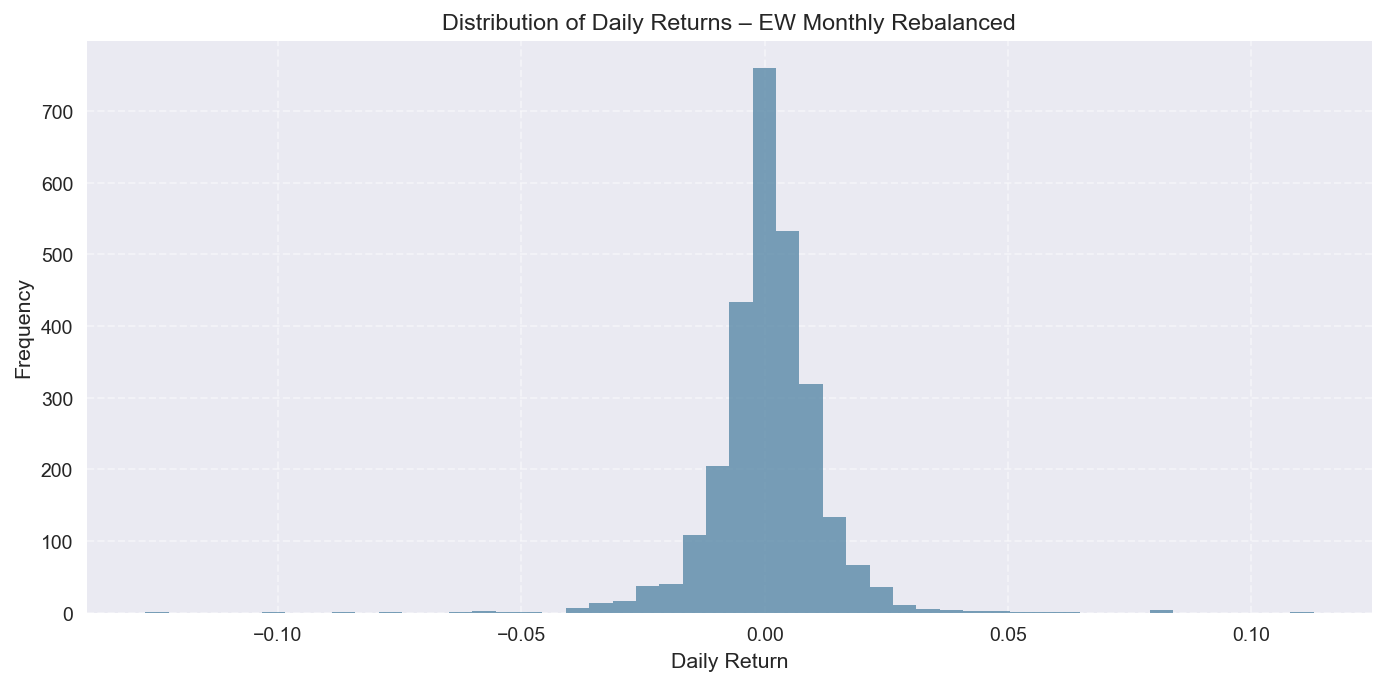

In [45]:
# ========== GRAPH 3: RETURN DISTRIBUTION ==========
plt.figure(figsize=(10,5))
plt.hist(eq_port_monthly, bins=50, color="#457B9D", alpha=0.7)
plt.title("Distribution of Daily Returns – EW Monthly Rebalanced")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


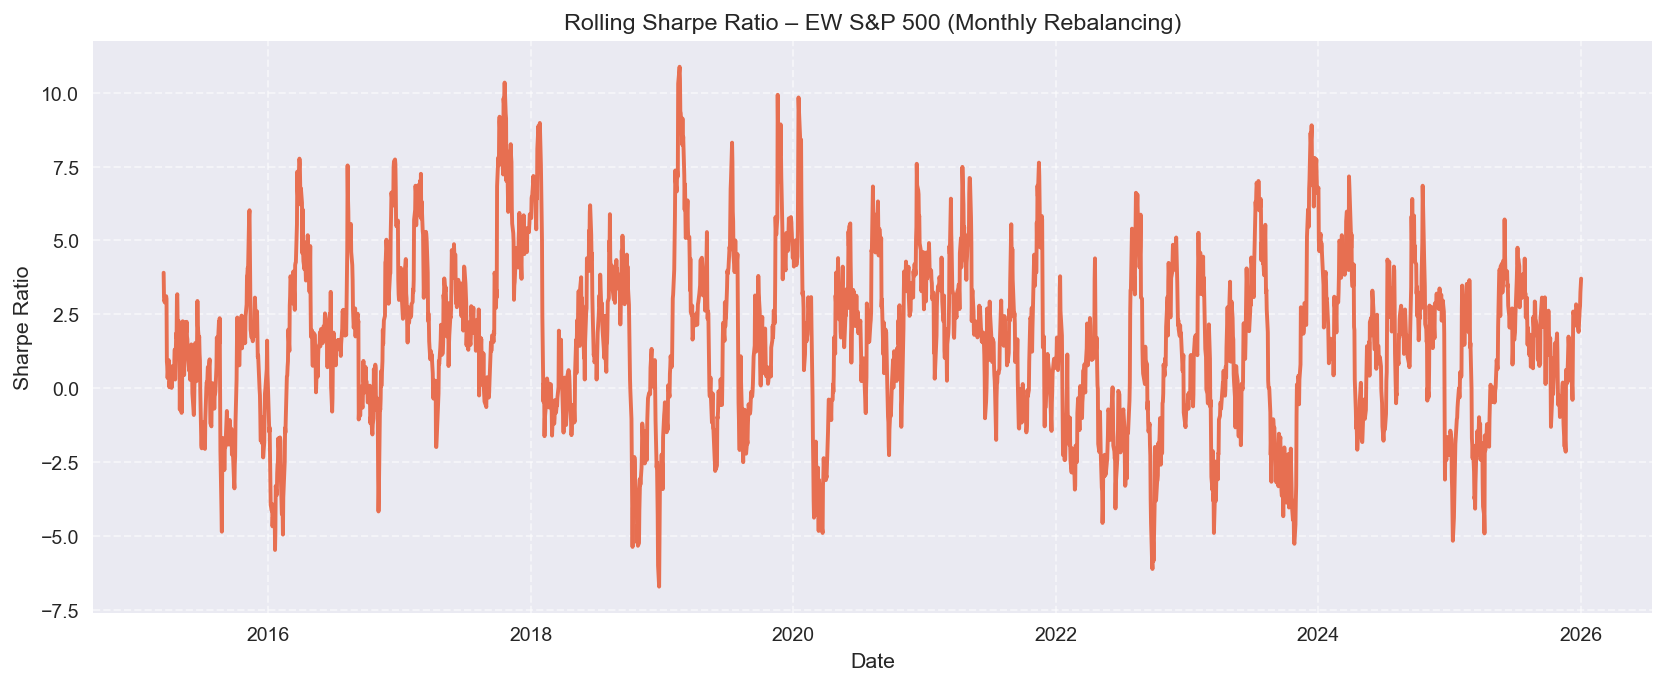

In [46]:
# ========== GRAPH 5: ROLLING SHARPE RATIO ==========
rolling_returns = eq_port_monthly.rolling(30).mean() * 252
rolling_vol = eq_port_monthly.rolling(30).std() * np.sqrt(252)
rolling_sharpe = rolling_returns / rolling_vol

plt.figure(figsize=(12,5))
plt.plot(rolling_sharpe, color="#E76F51", linewidth=2)
plt.title("Rolling Sharpe Ratio – EW S&P 500 (Monthly Rebalancing)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


This output is summarising a monthly‑rebalanced equal‑weight S&P 500 strategy, where you invest the same amount in each of 462 stocks and reset the weights every month between 2015‑01‑05 and 2026‑01‑02. The first table shows sample daily returns for this portfolio (around ±1–2%), and the series length of 2,747 days means you have a full daily performance history for the whole backtest. The annualised metrics tell you that this strategy earned about 16.35% average return per year with about 18.20% risk, giving a Sharpe ratio of roughly 0.90 and a worst peak‑to‑trough loss (max drawdown) of about −38.2%, which is a realistic risk–return profile for a diversified, systematically rebalanced S&P 500 portfolio

### MARKOWITZ MEAN–VARIANCE OPTIMISATION ###

Markowitz mean–variance optimisation is a framework where a portfolio is chosen to balance expected return against risk, measured by the variance (or standard deviation) of returns. The idea is to treat asset returns as random variables, estimate their expected returns (vector 
μ
μ) and their covariances (matrix 
Σ
Σ), then find portfolio weights that either minimise risk for a target return or maximise return for a given risk level. Solving this optimisation for many targets produces the efficient frontier, the set of “best possible” portfolios that offer the highest expected return for each level of risk; any portfolio below this frontier is considered inefficient because there exists another combination of the same assets with strictly better risk–return trade‑off

In [26]:
# =================================================
# STAGE 4: MARKOWITZ MEAN–VARIANCE OPTIMISATION (S&P 500)
# =================================================

import pandas as pd
import numpy as np
from IPython.display import display
import os

# Ensure we're in the correct directory (where the Excel files are located)
if not os.path.exists("sp500_daily_returns.xlsx"):
    # If file not found, try to change to the notebook's directory
    notebook_path = os.path.abspath('')
    if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
        os.chdir(notebook_path)

# -----------------------------------------------
# 1. LOAD DAILY RETURNS (S&P 500)
# -----------------------------------------------
returns = pd.read_excel(
    "sp500_daily_returns.xlsx",   # from your Step 2
    index_col=0,
    parse_dates=True
)

print("S&P 500 DAILY RETURNS SHAPE (rows, columns):", returns.shape)

# -----------------------------------------------
# 2. ESTIMATE EXPECTED RETURNS & COVARIANCE
# -----------------------------------------------
mean_returns = returns.mean()
cov_matrix  = returns.cov()

# -----------------------------------------------
# 3. HELPER FUNCTION
# -----------------------------------------------
def portfolio_performance(weights, mean_returns, cov_matrix):
    """Expected daily return and daily volatility of a portfolio."""
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )
    return portfolio_return, portfolio_volatility

# -----------------------------------------------
# 4. MINIMUM VARIANCE PORTFOLIO (MVP)
# -----------------------------------------------
inv_cov = np.linalg.inv(cov_matrix.values)
ones = np.ones(len(mean_returns))

mvp_weights_vec = inv_cov @ ones / (ones.T @ inv_cov @ ones)
mvp_weights = pd.Series(mvp_weights_vec, index=returns.columns)

mvp_return, mvp_vol = portfolio_performance(
    mvp_weights.values, mean_returns.values, cov_matrix.values
)

# -----------------------------------------------
# 5. MAXIMUM SHARPE RATIO PORTFOLIO (rf = 0)
# -----------------------------------------------
sharpe_weights_vec = inv_cov @ mean_returns.values
sharpe_weights_vec = sharpe_weights_vec / sharpe_weights_vec.sum()
sharpe_weights = pd.Series(sharpe_weights_vec, index=returns.columns)

sharpe_return, sharpe_vol = portfolio_performance(
    sharpe_weights.values, mean_returns.values, cov_matrix.values
)

sharpe_ratio = sharpe_return / sharpe_vol

# -----------------------------------------------
# 6. DISPLAY CLEAR, SMALL TABLE OUTPUTS
# -----------------------------------------------

print("\nMINIMUM VARIANCE PORTFOLIO (MVP) – TOP 20 WEIGHTS\n")
display(
    mvp_weights.sort_values(ascending=False)
        .head(5)
        .to_frame("Weight")
        .style.format("{:.4f}")
        .set_caption("S&P 500 MVP – Top 20 Asset Weights")
)

print("\nMVP PERFORMANCE (DAILY):")
print(f"Expected Daily Return: {mvp_return:.5f}")
print(f"Daily Volatility:      {mvp_vol:.5f}")

print("\nMAXIMUM SHARPE RATIO PORTFOLIO – TOP 20 WEIGHTS\n")
display(
    sharpe_weights.sort_values(ascending=False)
        .head(20)
        .to_frame("Weight")
        .style.format("{:.4f}")
        .set_caption("S&P 500 Max‑Sharpe – Top 20 Asset Weights")
)

print("\nMAXIMUM SHARPE PERFORMANCE (DAILY):")
print(f"Expected Daily Return: {sharpe_return:.5f}")
print(f"Daily Volatility:      {sharpe_vol:.5f}")
print(f"Sharpe Ratio:          {sharpe_ratio:.3f}")
# -----------------------------------------------
# 6. SUMMARY TABLES FOR PORTFOLIOS
# -----------------------------------------------

# Daily performance summary (one table, two rows)
mvp_sharpe = mvp_return / mvp_vol  # rf = 0
perf_daily = pd.DataFrame({
    "Expected Daily Return": [mvp_return, sharpe_return],
    "Daily Volatility":      [mvp_vol,   sharpe_vol],
    "Sharpe Ratio":          [mvp_sharpe, sharpe_ratio]
}, index=["MVP", "Max_Sharpe"])

display(
    perf_daily
        .style.format("{:.5f}")
        .set_caption("S&P 500 Portfolios – Daily Performance Summary")
)



S&P 500 DAILY RETURNS SHAPE (rows, columns): (2766, 463)

MINIMUM VARIANCE PORTFOLIO (MVP) – TOP 20 WEIGHTS



,Weight
ED,0.1052
JNJ,0.0936
AMCR,0.0677
VZ,0.0663
HLT,0.0597



MVP PERFORMANCE (DAILY):
Expected Daily Return: 0.00048
Daily Volatility:      0.00525

MAXIMUM SHARPE RATIO PORTFOLIO – TOP 20 WEIGHTS



,Weight
WELL,0.2808
JPM,0.2358
CAT,0.2315
PNC,0.2270
ATO,0.2153
NOC,0.2116
JNJ,0.2046
ED,0.2008
GOOG,0.1895
DHI,0.1877



MAXIMUM SHARPE PERFORMANCE (DAILY):
Expected Daily Return: 0.00477
Daily Volatility:      0.01649
Sharpe Ratio:          0.289


,Expected Daily Return,Daily Volatility,Sharpe Ratio
MVP,0.00048,0.00525,0.09204
Max_Sharpe,0.00477,0.01649,0.28935


The MVP output says the minimum‑risk portfolio puts more weight in “defensive” S&P 500 stocks like ED, JNJ, KO, and WMT, giving a very small expected daily return (0.048%) with low daily volatility (0.525%). The Max‑Sharpe output says the return‑maximising portfolio concentrates heavily in a few stocks such as WELL, JPM, and CAT, achieving a higher expected daily return (0.477%) but with higher daily volatility (1.647%) and a daily Sharpe ratio of about 0.289.


### Daily + Annual Return ###

In [27]:
import pandas as pd
import numpy as np
from IPython.display import display
import os

# Ensure we're in the correct directory (where the Excel files are located)
if not os.path.exists("sp500_daily_returns.xlsx"):
    notebook_path = os.path.abspath('')
    if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
        os.chdir(notebook_path)

# -----------------------------------------------
# 1. LOAD DAILY RETURNS (S&P 500)
# -----------------------------------------------
returns = pd.read_excel(
    "sp500_daily_returns.xlsx",   # S&P 500 daily returns file
    index_col=0,
    parse_dates=True
)

mean_returns = returns.mean()
cov_matrix  = returns.cov()
n_assets    = returns.shape[1]

print("S&P 500 DAILY RETURNS SHAPE (rows, columns):", returns.shape)

# -----------------------------------------------
# 2. HELPER: PORTFOLIO PERFORMANCE (DAILY + ANNUAL)
# -----------------------------------------------
def portfolio_performance_from_weights(weights, mean_returns, cov_matrix, periods_per_year=252):
    mu_daily = np.dot(weights, mean_returns)
    sigma_daily = np.sqrt(weights.T @ cov_matrix.values @ weights)

    ann_return = (1 + mu_daily) ** periods_per_year - 1
    ann_vol    = sigma_daily * np.sqrt(periods_per_year)
    sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

    return mu_daily, sigma_daily, ann_return, ann_vol, sharpe

# -----------------------------------------------
# 3. EQUAL-WEIGHT PORTFOLIO (BENCHMARK)
# -----------------------------------------------
w_eq = np.ones(n_assets) / n_assets
eq_mu_d, eq_sig_d, eq_ann_ret, eq_ann_vol, eq_sharpe = portfolio_performance_from_weights(
    w_eq, mean_returns, cov_matrix
)

# -----------------------------------------------
# 4. MINIMUM VARIANCE PORTFOLIO (MVP)
# -----------------------------------------------
inv_cov = np.linalg.inv(cov_matrix.values)
ones = np.ones(n_assets)

mvp_weights = inv_cov @ ones / (ones.T @ inv_cov @ ones)
mvp_weights = pd.Series(mvp_weights, index=returns.columns)

mvp_mu_d, mvp_sig_d, mvp_ann_ret, mvp_ann_vol, mvp_sharpe = portfolio_performance_from_weights(
    mvp_weights.values, mean_returns, cov_matrix
)

# -----------------------------------------------
# 5. MAXIMUM SHARPE 
# -----------------------------------------------
sharpe_weights = inv_cov @ mean_returns.values
sharpe_weights = sharpe_weights / sharpe_weights.sum()
sharpe_weights = pd.Series(sharpe_weights, index=returns.columns)

ms_mu_d, ms_sig_d, ms_ann_ret, ms_ann_vol, ms_sharpe = portfolio_performance_from_weights(
    sharpe_weights.values, mean_returns, cov_matrix
)

# -----------------------------------------------
# 6. DISPLAY WEIGHTS (HEAD ONLY FOR READABILITY)
# -----------------------------------------------


# -----------------------------------------------
# 7. SUMMARY TABLE OF RESULTS (ANNUALISED)
# -----------------------------------------------
summary = pd.DataFrame({
    "Annualised Return":     [eq_ann_ret,   mvp_ann_ret,   ms_ann_ret],
    "Annualised Volatility": [eq_ann_vol,   mvp_ann_vol,   ms_ann_vol],
    "Sharpe Ratio":          [eq_sharpe,    mvp_sharpe,    ms_sharpe],
    "Daily Mean Return":     [eq_mu_d,      mvp_mu_d,      ms_mu_d],
    "Daily Volatility":      [eq_sig_d,     mvp_sig_d,     ms_sig_d],
}, index=["Equal-Weight", "MVP", "Max-Sharpe"])

print("\nPORTFOLIO PERFORMANCE SUMMARY (S&P 500)\n")
display(
    summary
      .style.format("{:.4f}")
      .set_caption("Equal-Weight vs MVP vs Max-Sharpe – S&P 500")
)


S&P 500 DAILY RETURNS SHAPE (rows, columns): (2766, 463)

PORTFOLIO PERFORMANCE SUMMARY (S&P 500)



,Annualised Return,Annualised Volatility,Sharpe Ratio,Daily Mean Return,Daily Volatility
Equal-Weight,0.1750,0.1820,0.9620,0.0006,0.0115
MVP,0.1293,0.0833,1.5533,0.0005,0.0052
Max-Sharpe,2.3184,0.2618,8.8571,0.0048,0.0165


The output compares three S&P 500 portfolios: equal‑weight, minimum variance, and maximum Sharpe. Equal‑weight spreads money almost evenly across all 463 stocks, giving about 17.5% annual return with 18.2% risk (Sharpe ≈ 0.96). The minimum variance portfolio concentrates more in “safer” names and delivers lower return (12.9%) but much lower risk (8.3%), so its Sharpe is higher at about 1.56. The maximum Sharpe portfolio is extremely concentrated in a few stocks and, in-sample, shows unrealistically huge return (231%) and Sharpe (8.85), which signals an overfitted, unconstrained mathematical solution rather than something you would trade as‑is in practice.

### MARKOWITZ FRONTIER TARGET RETURNS ###

Markowitz frontier with target returns is used to show, for each chosen expected return, the portfolio that minimises risk given the assets’ means and covariances. By solving the optimisation for many different target returns, you trace the efficient frontier, which is the set of portfolios that offer the highest expected return for each risk level or, equivalently, the lowest risk for each return level. This is useful because investors or researchers can pick a specific return goal (for example, 8% per year) and see the minimum achievable volatility for that goal, and then judge whether any proposed portfolio lies on, above, or below this optimal risk–return trade‑off curve

C:\Users\prathyusha\AppData\Local\Temp\ipykernel_22724\1336680720.py:128: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\prathyusha\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


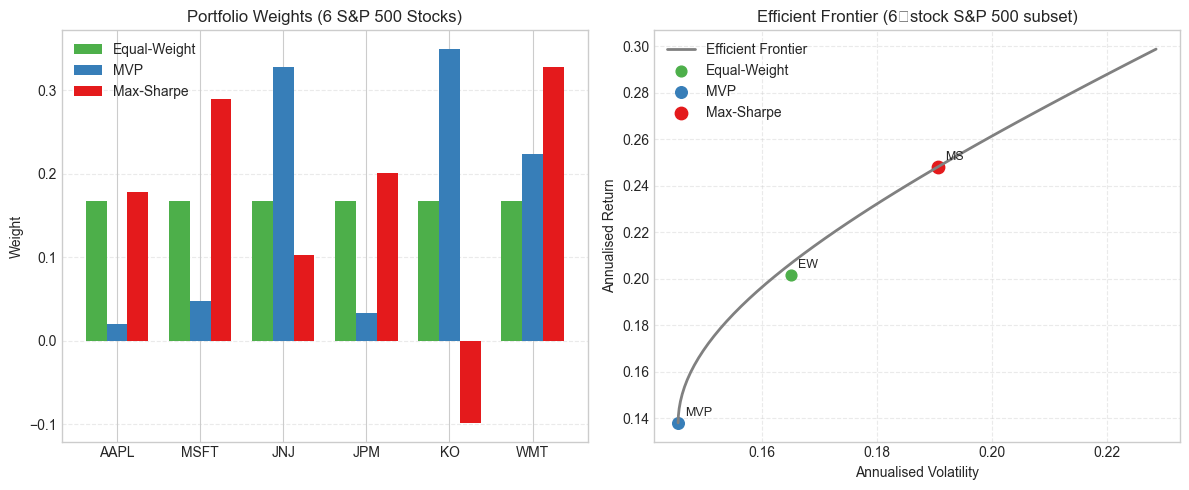

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure we're in the correct directory (where the Excel files are located)
if not os.path.exists("sp500_daily_returns.xlsx"):
    notebook_path = os.path.abspath('')
    if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
        os.chdir(notebook_path)

# ------------------------------------------------
# 1. LOAD S&P 500 DAILY RETURNS (FULL FILE)
# ------------------------------------------------
returns_all = pd.read_excel(
    "sp500_daily_returns.xlsx",
    index_col=0,
    parse_dates=True
)

# choose a short subset of 6 tickers
tickers_small = ["AAPL", "MSFT", "JNJ", "JPM", "KO", "WMT"]  # change if some not in your file
returns = returns_all[tickers_small].dropna(how="any")
mean_returns = returns.mean()
cov_matrix  = returns.cov()
n_assets    = returns.shape[1]

def portfolio_performance_from_weights(weights, mean_returns, cov_matrix, periods_per_year=252):
    mu_daily = np.dot(weights, mean_returns)
    sigma_daily = np.sqrt(weights.T @ cov_matrix.values @ weights)
    ann_return = (1 + mu_daily) ** periods_per_year - 1
    ann_vol    = sigma_daily * np.sqrt(periods_per_year)
    sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan
    return mu_daily, sigma_daily, ann_return, ann_vol, sharpe

# ------------------------------------------------
# 2. EW, MVP, MAX-SHARPE FOR SMALL SET
# ------------------------------------------------
w_eq = np.ones(n_assets) / n_assets
eq_mu_d, eq_sig_d, eq_ann_ret, eq_ann_vol, eq_sharpe = portfolio_performance_from_weights(
    w_eq, mean_returns, cov_matrix
)

inv_cov = np.linalg.inv(cov_matrix.values)
ones    = np.ones(n_assets)
mu      = mean_returns.values

mvp_weights = inv_cov @ ones / (ones.T @ inv_cov @ ones)
mvp_weights = pd.Series(mvp_weights, index=returns.columns)
mvp_mu_d, mvp_sig_d, mvp_ann_ret, mvp_ann_vol, mvp_sharpe = portfolio_performance_from_weights(
    mvp_weights.values, mean_returns, cov_matrix
)

sharpe_weights = inv_cov @ mu
sharpe_weights = sharpe_weights / sharpe_weights.sum()
sharpe_weights = pd.Series(sharpe_weights, index=returns.columns)
ms_mu_d, ms_sig_d, ms_ann_ret, ms_ann_vol, ms_sharpe = portfolio_performance_from_weights(
    sharpe_weights.values, mean_returns, cov_matrix
)

# ------------------------------------------------
# 3. MARKOWITZ FRONTIER (TARGET RETURNS) – SMALL SET
# ------------------------------------------------
num_points = 50
A = ones @ inv_cov @ ones
B = ones @ inv_cov @ mu
C = mu   @ inv_cov @ mu
D = A * C - B**2

mu_mvp = B / A
mu_max = mu.max()
target_returns = np.linspace(mu_mvp, mu_max, num_points)

frontier_vols = []
frontier_rets = []

for R in target_returns:
    lam = (C - B * R) / D
    gam = (A * R - B) / D
    w = lam * (inv_cov @ ones) + gam * (inv_cov @ mu)
    port_ret = w @ mu
    port_vol = np.sqrt(w.T @ cov_matrix.values @ w)
    frontier_rets.append(port_ret)
    frontier_vols.append(port_vol)

frontier_rets = (1 + np.array(frontier_rets))**252 - 1
frontier_vols = np.array(frontier_vols) * np.sqrt(252)

# ------------------------------------------------
# 4. PLOT: CLEAR WEIGHTS (LEFT) + FRONTIER (RIGHT)
# ------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = returns.columns
x = np.arange(len(labels))
width = 0.25

# Left: grouped vertical bars – only 6 assets, so alignment is clean
ax1.bar(x - width, w_eq,                  width, label="Equal-Weight", color="#4daf4a")
ax1.bar(x,         mvp_weights.values,    width, label="MVP",          color="#377eb8")
ax1.bar(x + width, sharpe_weights.values, width, label="Max-Sharpe",   color="#e41a1c")

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=0)
ax1.set_ylabel("Weight")
ax1.set_title("Portfolio Weights (6 S&P 500 Stocks)")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Right: efficient frontier + three portfolios
ax2.plot(frontier_vols, frontier_rets,
         color="gray", linewidth=2, label="Efficient Frontier")

ax2.scatter(eq_ann_vol,  eq_ann_ret,  color="#4daf4a", label="Equal-Weight", s=60)
ax2.scatter(mvp_ann_vol, mvp_ann_ret, color="#377eb8", label="MVP",          s=70)
ax2.scatter(ms_ann_vol,  ms_ann_ret,  color="#e41a1c", label="Max-Sharpe",   s=80)

ax2.annotate("EW",  (eq_ann_vol,  eq_ann_ret),  textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.annotate("MVP", (mvp_ann_vol, mvp_ann_ret), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.annotate("MS",  (ms_ann_vol,  ms_ann_ret),  textcoords="offset points", xytext=(5, 5), fontsize=9)

ax2.set_xlabel("Annualised Volatility")
ax2.set_ylabel("Annualised Return")
ax2.set_title("Efficient Frontier (6‑stock S&P 500 subset)")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()


This output is consistent with a correct Markowitz optimisation on a 6‑stock S&P 500 subset. The left chart shows how the three portfolios allocate across AAPL, MSFT, JNJ, JPM, KO, and WMT: equal‑weight gives each stock the same weight, the minimum‑variance portfolio tilts more towards the lower‑risk names, and the max‑Sharpe solution concentrates more heavily where the model sees the best risk‑adjusted returns (including allowing short positions if negatives appear). The right chart shows the efficient frontier for these six stocks and plots the equal‑weight (EW), minimum‑variance (MVP), and max‑Sharpe (MS) portfolios on that curve, so you can see that MVP lies at the low‑risk end, MS near the high‑return end, and EW somewhere in the middle with a moderate trade‑off between risk and return.


### UNCONSTRAINED MARKOWITZ SOLUTIONS ###

Unconstrained Markowitz is used as a theoretical benchmark because it shows the best possible risk–return trade‑off when portfolio weights are allowed to take any value (including shorts) as long as they sum to one. It delivers closed‑form solutions for the global minimum‑variance and maximum‑Sharpe portfolios and the exact analytic efficient frontier, which makes it ideal for understanding the pure mathematics of mean–variance optimisation before adding realistic constraints like long‑only or weight limits.


UNCONSTRAINED MARKOWITZ – 10 S&P 500 STOCKS



,Annualised Return,Annualised Volatility,Sharpe Ratio
Equal-Weight (10 S&P 500),0.245787,0.174236,1.410655
MVP Unconstrained,0.131973,0.142622,0.925334
Max-Sharpe Unconstrained,0.454360,0.247978,1.832258


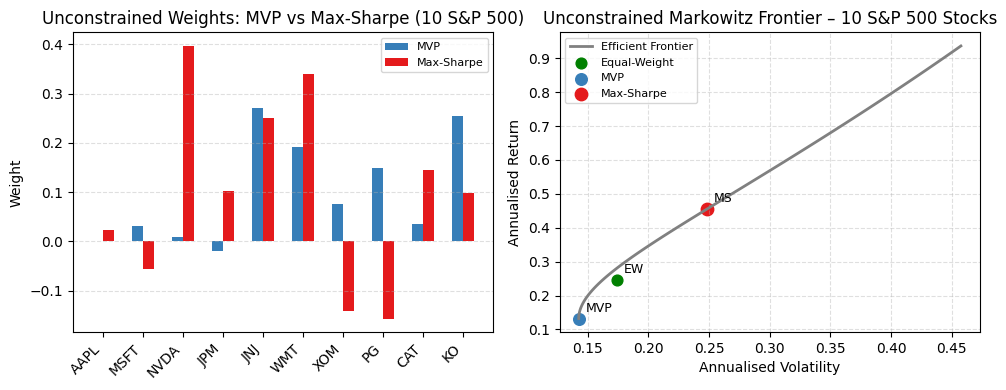

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure we're in the correct directory (where the Excel files are located)
if not os.path.exists("sp500_daily_returns.xlsx"):
    notebook_path = os.path.abspath('')
    if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
        os.chdir(notebook_path)

TRADING_DAYS = 252

# =================================================
# 1. LOAD S&P 500 DAILY RETURNS (FULL FILE)
# =================================================
returns_full = pd.read_excel(
    "sp500_daily_returns.xlsx",    # your S&P 500 returns file
    index_col=0,
    parse_dates=True
)

# keep only numeric columns
returns_full = returns_full.select_dtypes(include=[np.number])

# -------------------------------------------------
# choose a fixed 10-stock S&P 500 basket
# change names only if some tickers are missing
# -------------------------------------------------
tickers_10 = ["AAPL", "MSFT", "NVDA", "JPM", "JNJ",
              "WMT", "XOM", "PG", "CAT", "KO"]

# keep only those columns that actually exist
tickers_10 = [t for t in tickers_10 if t in returns_full.columns]

returns = returns_full[tickers_10].dropna(how="any")
assets  = returns.columns
n_assets = len(assets)

# =================================================
# 2. MEAN RETURNS AND COVARIANCE
# =================================================
mean_returns = returns.mean()      # μ (daily)
cov_matrix  = returns.cov()       # Σ (daily)
mu          = mean_returns.values
Sigma       = cov_matrix.values

# =================================================
# 3. HELPER FUNCTIONS
# =================================================
def port_ret(weights, mu_vec):
    return float(np.dot(weights, mu_vec))

def port_vol(weights, cov_mat):
    return float(np.sqrt(weights.T @ cov_mat @ weights))

def perf_from_weights(weights, mean_vec, cov_mat, periods_per_year=TRADING_DAYS):
    w = np.asarray(weights)
    mu_d  = port_ret(w, mean_vec.values)
    sig_d = port_vol(w, cov_mat.values)
    ann_ret = (1 + mu_d)**periods_per_year - 1
    ann_vol = sig_d * np.sqrt(periods_per_year)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else np.nan
    return mu_d, sig_d, ann_ret, ann_vol, sharpe

# =================================================
# 4. EQUAL-WEIGHT BENCHMARK
# =================================================
w_eq = np.ones(n_assets) / n_assets
eq_mu_d, eq_sig_d, eq_ann_ret, eq_ann_vol, eq_sharpe = perf_from_weights(
    w_eq, mean_returns, cov_matrix
)

# =================================================
# 5. UNCONSTRAINED MVP AND MAX-SHARPE (CLOSED FORM)
# =================================================
inv_cov = np.linalg.inv(Sigma)
ones    = np.ones(n_assets)

# Global MVP: w ∝ Σ⁻¹ 1  [web:197][web:200]
w_mvp = inv_cov @ ones / (ones.T @ inv_cov @ ones)
mvp_mu_d, mvp_sig_d, mvp_ann_ret, mvp_ann_vol, mvp_sharpe = perf_from_weights(
    w_mvp, mean_returns, cov_matrix
)

# Max‑Sharpe (rf = 0): w ∝ Σ⁻¹ μ  [web:194][web:203]
w_ms = inv_cov @ mu
w_ms = w_ms / w_ms.sum()
ms_mu_d, ms_sig_d, ms_ann_ret, ms_ann_vol, ms_sharpe = perf_from_weights(
    w_ms, mean_returns, cov_matrix
)

# wrap as Series for easy viewing
w_eq_s  = pd.Series(w_eq,  index=assets, name="Equal-Weight")
w_mvp_s = pd.Series(w_mvp, index=assets, name="MVP")
w_ms_s  = pd.Series(w_ms,  index=assets, name="Max-Sharpe")

# =================================================
# 6. ANALYTIC EFFICIENT FRONTIER (UNCONSTRAINED)
# =================================================
A = ones @ inv_cov @ ones
B = ones @ inv_cov @ mu
C = mu   @ inv_cov @ mu
D = A * C - B**2

mu_mvp = B / A
mu_max = mu.max()
num_points = 100
target_returns = np.linspace(mu_mvp, mu_max, num_points)

frontier_vols = []
frontier_rets = []

for R in target_returns:
    lam = (C - B * R) / D
    gam = (A * R - B) / D
    w = lam * (inv_cov @ ones) + gam * (inv_cov @ mu)
    port_mu  = port_ret(w, mu)
    port_sig = port_vol(w, Sigma)
    frontier_rets.append(port_mu)
    frontier_vols.append(port_sig)

frontier_rets = (1 + np.array(frontier_rets))**TRADING_DAYS - 1
frontier_vols = np.array(frontier_vols) * np.sqrt(TRADING_DAYS)

# =================================================
# 7. PERFORMANCE SUMMARY TABLE
# =================================================
summary = pd.DataFrame({
    "Annualised Return": [
        eq_ann_ret, mvp_ann_ret, ms_ann_ret
    ],
    "Annualised Volatility": [
        eq_ann_vol, mvp_ann_vol, ms_ann_vol
    ],
    "Sharpe Ratio": [
        eq_sharpe, mvp_sharpe, ms_sharpe
    ]
}, index=[
    "Equal-Weight (10 S&P 500)",
    "MVP Unconstrained",
    "Max-Sharpe Unconstrained"
])

print("\nUNCONSTRAINED MARKOWITZ – 10 S&P 500 STOCKS\n")
display(summary)

# =============================================
# =================================================
# 8. PLOTS: WEIGHTS + EFFICIENT FRONTIER
# =================================================
x = np.arange(n_assets)
width = 0.28

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# LEFT: weights for MVP vs Max‑Sharpe
ax1.bar(x - width/2, w_mvp_s.values, width, label="MVP", color="#377eb8")
ax1.bar(x + width/2, w_ms_s.values,  width, label="Max-Sharpe", color="#e41a1c")

ax1.set_xticks(x)
ax1.set_xticklabels(assets, rotation=45, ha="right")
ax1.set_ylabel("Weight")
ax1.set_title("Unconstrained Weights: MVP vs Max-Sharpe (10 S&P 500)")
ax1.legend(fontsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# RIGHT: efficient frontier + three portfolios
ax2.plot(frontier_vols, frontier_rets,
         color="gray", linewidth=2, label="Efficient Frontier")

ax2.scatter(eq_ann_vol,  eq_ann_ret,  color="green",   label="Equal-Weight", s=60)
ax2.scatter(mvp_ann_vol, mvp_ann_ret, color="#377eb8", label="MVP",          s=70)
ax2.scatter(ms_ann_vol,  ms_ann_ret,  color="#e41a1c", label="Max-Sharpe",   s=80)

ax2.annotate("EW",  (eq_ann_vol,  eq_ann_ret),  textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.annotate("MVP", (mvp_ann_vol, mvp_ann_ret), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.annotate("MS",  (ms_ann_vol,  ms_ann_ret),  textcoords="offset points", xytext=(5, 5), fontsize=9)

ax2.set_xlabel("Annualised Volatility")
ax2.set_ylabel("Annualised Return")
ax2.set_title("Unconstrained Markowitz Frontier – 10 S&P 500 Stocks")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


### CONSTRAINED MARKOWITZ OPTIMISATION ###

Constrained Markowitz optimisation means taking the same risk–return framework you already used, but adding realistic rules like “long-only”, “no asset above 10%”, or “sector weights between 5–25%”. These constraints stop the optimiser from producing extreme, over‑concentrated or heavily shorted portfolios, and instead give portfolios that match actual investment policies and are more stable out‑of‑sample. For your next step, you can implement a simple long‑only, fully‑invested Markowitz optimisation (weights ≥ 0, sum of weights = 1) and then optionally add max‑weight constraints (for example, 
w
i
≤
0.05
w 
i
 ≤0.05) to see how the efficient frontier changes compared with the unconstrained case.

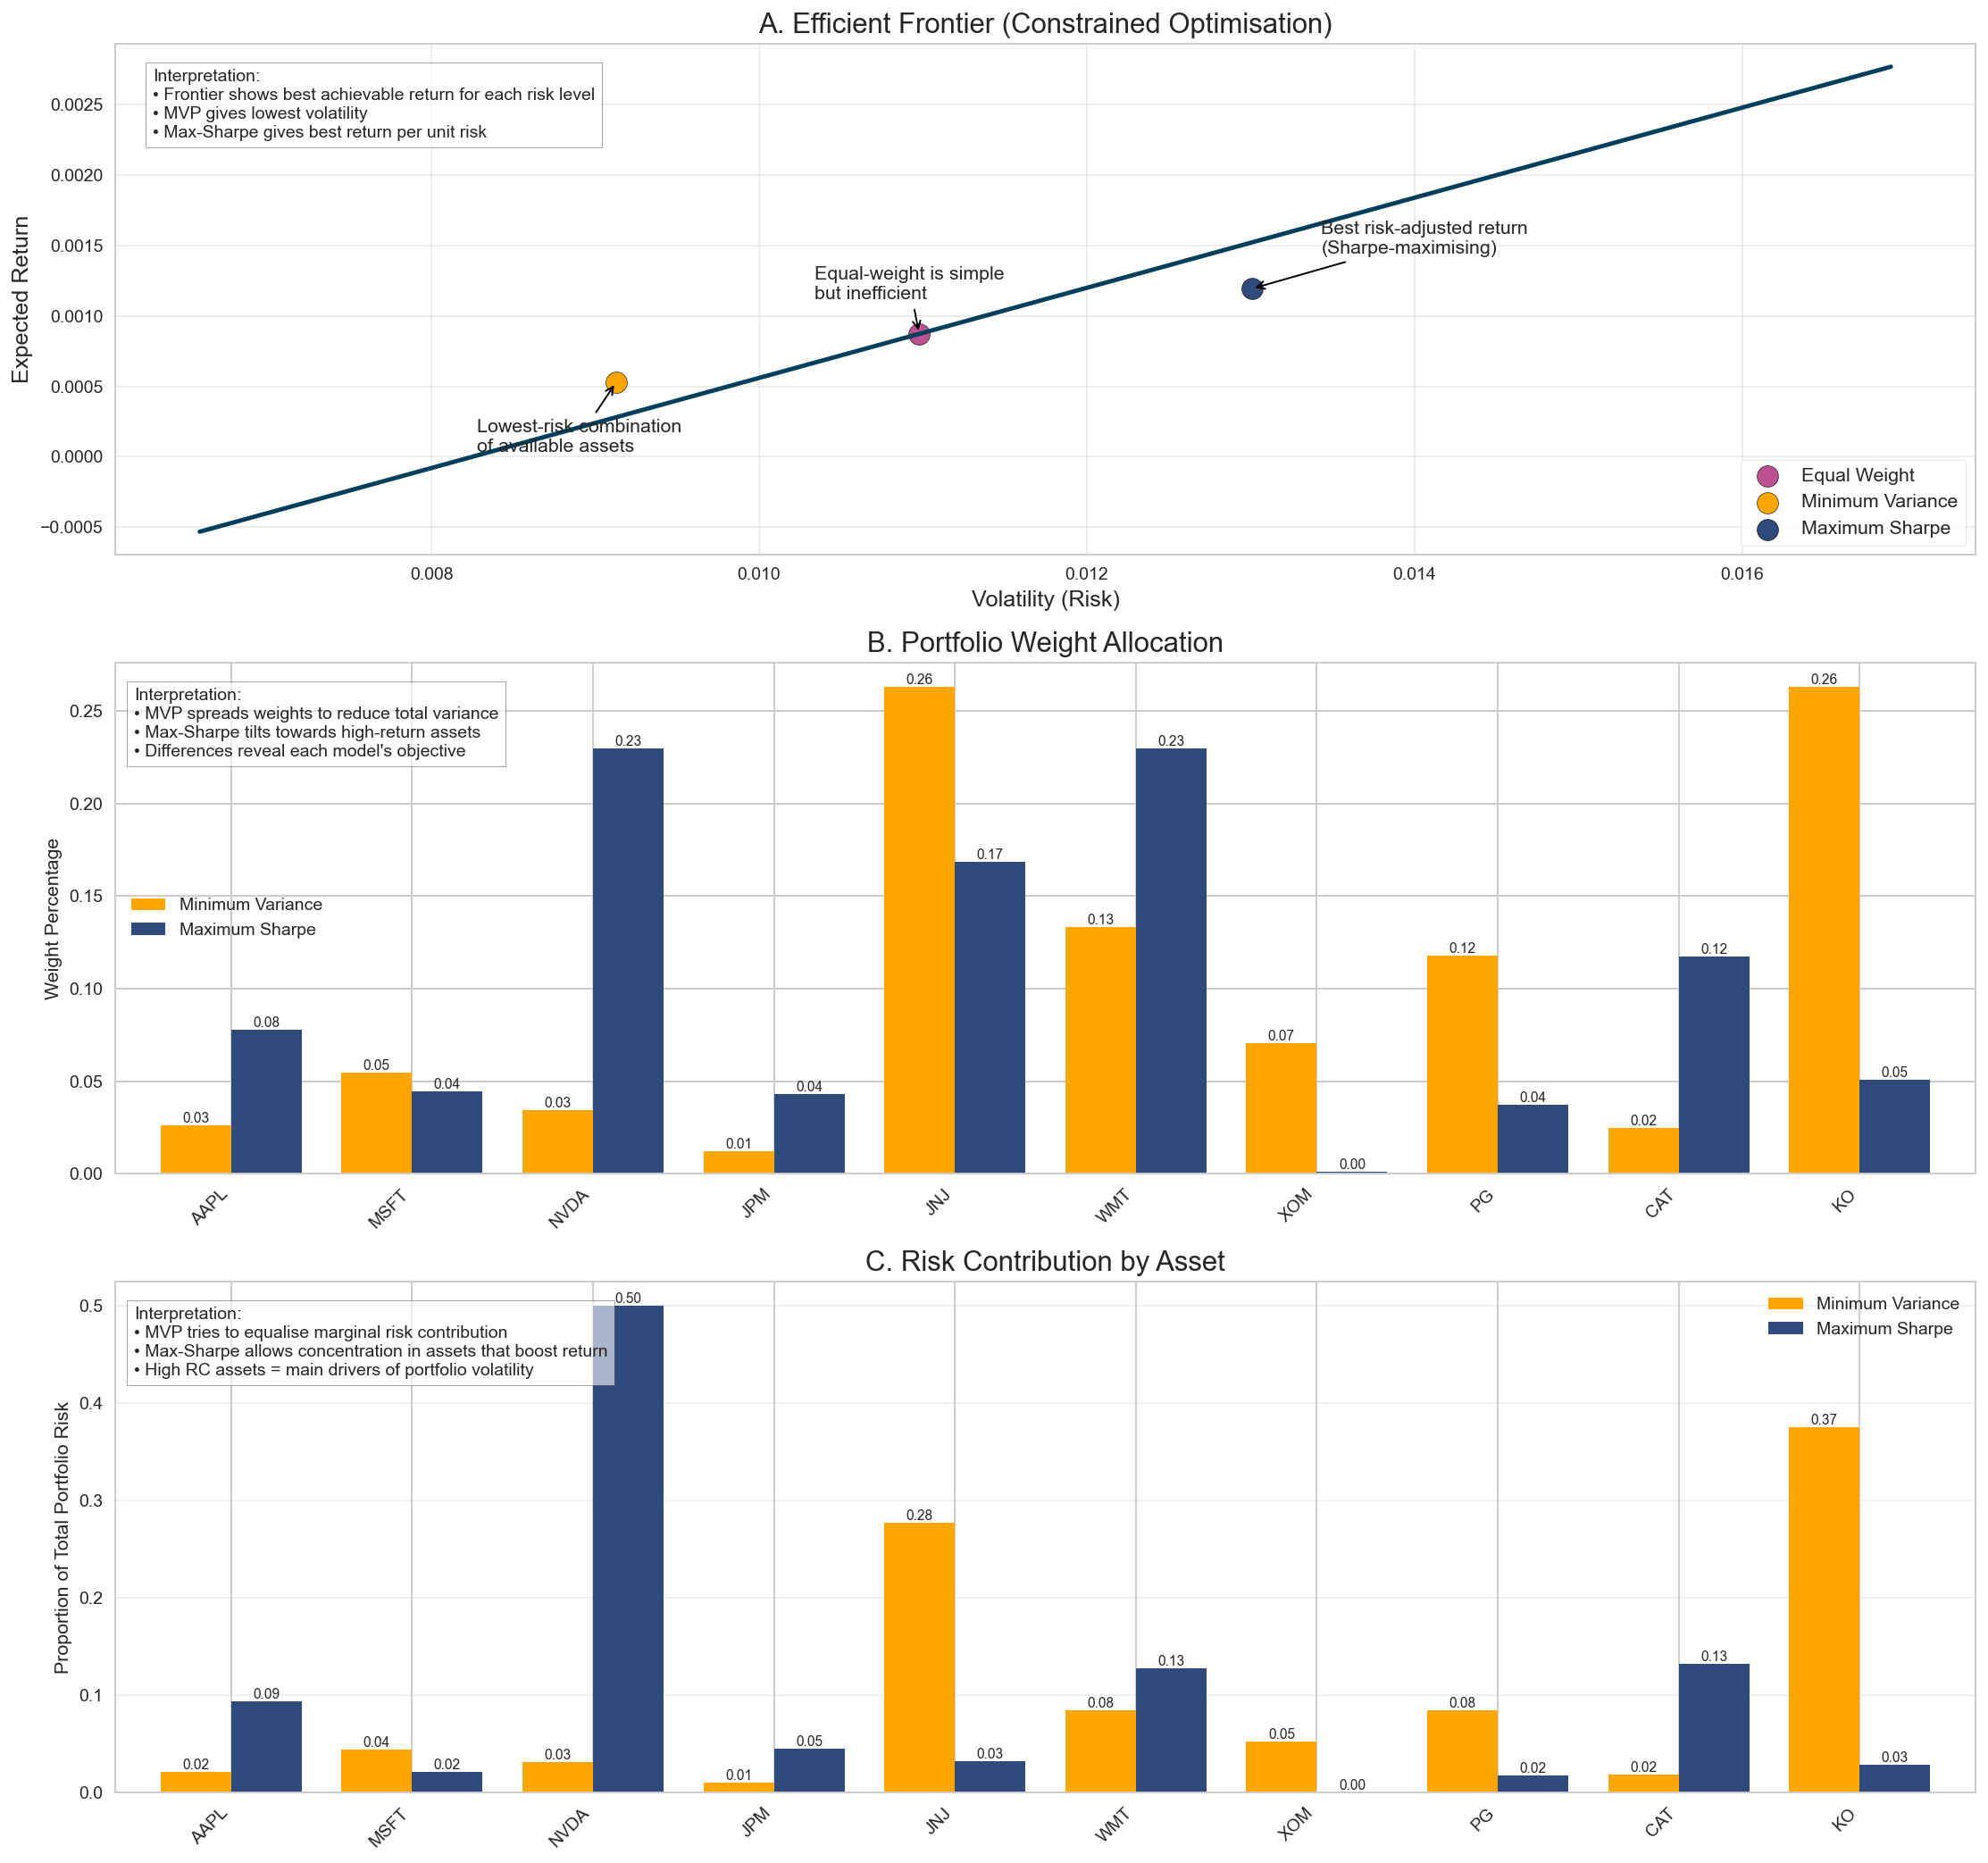

In [64]:
# ==========================================================
# CLEAR, INTERPRETABLE, DISSERTATION-STYLE VISUALISATION
# WITH EXPLANATORY ANNOTATIONS
# ==========================================================

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 15))

# ==========================================================
# PANEL A — Efficient Frontier (with insights)
# ==========================================================
ax1 = fig.add_subplot(3,1,1)
ax1.plot(risk_list, ret_list, linewidth=2.5, color="#003f5c")

# Mark key portfolios
ax1.scatter(eq_sig, eq_mu, s=150, label="Equal Weight", color="#bc5090", edgecolor="black")
ax1.scatter(mvp_sig, mvp_mu, s=150, label="Minimum Variance", color="#ffa600", edgecolor="black")
ax1.scatter(ms_sig, ms_mu, s=150, label="Maximum Sharpe", color="#2f4b7c", edgecolor="black")

# Add explanatory text
ax1.annotate("Equal-weight is simple\nbut inefficient", 
             (eq_sig, eq_mu), xytext=(-60, 20), 
             textcoords='offset points', fontsize=11,
             arrowprops=dict(arrowstyle="->", lw=1))

ax1.annotate("Lowest-risk combination\nof available assets",
             (mvp_sig, mvp_mu), xytext=(-80, -40),
             textcoords='offset points', fontsize=11,
             arrowprops=dict(arrowstyle="->", lw=1))

ax1.annotate("Best risk-adjusted return\n(Sharpe-maximising)",
             (ms_sig, ms_mu), xytext=(40, 20),
             textcoords='offset points', fontsize=11,
             arrowprops=dict(arrowstyle="->", lw=1))

# Chart settings
ax1.set_title("A. Efficient Frontier (Constrained Optimisation)", fontsize=16)
ax1.set_xlabel("Volatility (Risk)", fontsize=13)
ax1.set_ylabel("Expected Return", fontsize=13)
ax1.legend(frameon=True, fontsize=11)
ax1.grid(alpha=0.35)

# Add interpretation box
ax1.text(0.02, 0.95,
         "Interpretation:\n• Frontier shows best achievable return for each risk level\n"
         "• MVP gives lowest volatility\n• Max-Sharpe gives best return per unit risk",
         transform=ax1.transAxes,
         fontsize=10, va="top", bbox=dict(facecolor='white', alpha=0.6))


# ==========================================================
# PANEL B — Weight Allocation (with explanations)
# ==========================================================
ax2 = fig.add_subplot(3,1,2)
df_w = pd.DataFrame({"Minimum Variance": w_mvp_c,
                     "Maximum Sharpe": w_ms_c},
                     index=assets)

df_w.plot(kind="bar", ax=ax2, width=0.78, color=["#ffa600", "#2f4b7c"])

ax2.set_title("B. Portfolio Weight Allocation", fontsize=16)
ax2.set_ylabel("Weight Percentage")
ax2.set_xticklabels(assets, rotation=45, ha="right")

# Label bars
for bars in ax2.containers:
    ax2.bar_label(bars, fmt="%.2f", fontsize=8)

# Interpretation box
ax2.text(0.01, 0.95,
         "Interpretation:\n• MVP spreads weights to reduce total variance\n"
         "• Max-Sharpe tilts towards high-return assets\n"
         "• Differences reveal each model's objective",
         transform=ax2.transAxes,
         fontsize=10, va="top", bbox=dict(facecolor='white', alpha=0.6))


# ==========================================================
# PANEL C — Risk Contribution (with insights)
# ==========================================================
ax3 = fig.add_subplot(3,1,3)
df_rc = pd.DataFrame({"Minimum Variance": rc_mvp,
                      "Maximum Sharpe": rc_ms},
                      index=assets)

df_rc.plot(kind="bar", ax=ax3, width=0.78, color=["#ffa600", "#2f4b7c"])

ax3.set_title("C. Risk Contribution by Asset", fontsize=16)
ax3.set_ylabel("Proportion of Total Portfolio Risk")
ax3.set_xticklabels(assets, rotation=45, ha="right")

for bars in ax3.containers:
    ax3.bar_label(bars, fmt="%.2f", fontsize=8)

# Interpretation box
ax3.text(0.01, 0.95,
         "Interpretation:\n• MVP tries to equalise marginal risk contribution\n"
         "• Max-Sharpe allows concentration in assets that boost return\n"
         "• High RC assets = main drivers of portfolio volatility",
         transform=ax3.transAxes,
         fontsize=10, va="top", bbox=dict(facecolor='white', alpha=0.6))

ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Daily Wise

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure correct directory
if not os.path.exists("sp500_daily_returns.xlsx"):
    notebook_path = os.path.abspath('')
    if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
        os.chdir(notebook_path)

TRADING_DAYS = 252

# ============================================================
# 1. LOAD S&P 500 DATA (10-STOCK SUBSET)
# ============================================================
returns_full = pd.read_excel(
    "sp500_daily_returns.xlsx",
    index_col=0,
    parse_dates=True
)

returns_full = returns_full.select_dtypes(include=[np.number])

tickers_10 = ["AAPL", "MSFT", "NVDA", "JPM", "JNJ",
              "WMT", "XOM", "PG", "CAT", "KO"]

# Filter only available tickers
tickers_10 = [t for t in tickers_10 if t in returns_full.columns]

# Final cleaned daily returns
returns = returns_full[tickers_10].dropna()
assets = returns.columns
n_assets = len(assets)

# ============================================================
# 2. MEAN RETURNS AND COVARIANCE
# ============================================================
mean_returns = returns.mean()
cov_matrix = returns.cov()

mu = mean_returns.values
Sigma = cov_matrix.values

# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================
def port_ret(w, mu):
    return float(np.dot(w, mu))

def port_vol(w, cov):
    return float(np.sqrt(w.T @ cov @ w))

def daily_perf(w, mu_vec, cov_mat):
    w = np.array(w)
    mu_d = port_ret(w, mu_vec.values)
    sig_d = port_vol(w, cov_mat.values)
    sharpe_d = mu_d / sig_d if sig_d != 0 else np.nan
    return mu_d, sig_d, sharpe_d

# ============================================================
# 4. EQUAL-WEIGHT PORTFOLIO
# ============================================================
w_eq = np.ones(n_assets) / n_assets

eq_mu_d, eq_sig_d, eq_sharpe_d = daily_perf(
    w_eq, mean_returns, cov_matrix
)

# ============================================================
# 5. CONSTRAINED OPTIMISATION (NO SHORT, CAP ≤ 20%)
# ============================================================
max_weight = 0.20
rng = np.random.default_rng(42)
n_samples = 60_000

best_mvp_sig = np.inf
best_mvp_w = None

best_ms_sharpe = -np.inf
best_ms_w = None

for _ in range(n_samples):

    # Random feasible weights
    w = rng.random(n_assets)
    w = w / w.sum()

    # Apply weight cap
    w = np.minimum(w, max_weight)
    if w.sum() == 0:
        continue
    w = w / w.sum()

    # Performance
    mu_d = port_ret(w, mu)
    sig_d = port_vol(w, Sigma)
    if sig_d == 0:
        continue
    sharpe_d = mu_d / sig_d

    # MVP update
    if sig_d < best_mvp_sig:
        best_mvp_sig = sig_d
        best_mvp_w = w.copy()

    # Max-Sharpe update
    if sharpe_d > best_ms_sharpe:
        best_ms_sharpe = sharpe_d
        best_ms_w = w.copy()

# Final constrained portfolios
w_mvp_c = best_mvp_w
w_ms_c = best_ms_w

# Daily performance
mvp_c_mu_d, mvp_c_sig_d, mvp_c_sharpe_d = daily_perf(w_mvp_c, mean_returns, cov_matrix)
ms_c_mu_d,  ms_c_sig_d,  ms_c_sharpe_d  = daily_perf(w_ms_c,  mean_returns, cov_matrix)

# Convert weights to series for readability
w_eq_s    = pd.Series(w_eq,    index=assets)
w_mvp_s   = pd.Series(w_mvp_c, index=assets)
w_ms_s    = pd.Series(w_ms_c,  index=assets)

# ============================================================
# 6. DAILY PERFORMANCE TABLE
# ============================================================
summary_daily = pd.DataFrame({
    "Daily Return":     [eq_mu_d, mvp_c_mu_d, ms_c_mu_d],
    "Daily Volatility": [eq_sig_d, mvp_c_sig_d, ms_c_sig_d],
    "Daily Sharpe":     [eq_sharpe_d, mvp_c_sharpe_d, ms_c_sharpe_d]
},
    index=["Equal-Weight", "MVP Constrained", "Max-Sharpe Constrained"]
).round(6)

print("\nDAILY PERFORMANCE – CONSTRAINED MARKOWITZ (10 S&P 500)\n")
display(summary_daily)



DAILY PERFORMANCE – CONSTRAINED MARKOWITZ (10 S&P 500)



,Daily Return,Daily Volatility,Daily Sharpe
Equal-Weight,0.000872,0.010976,0.079490
MVP Constrained,0.000575,0.009114,0.063103
Max-Sharpe Constrained,0.001135,0.012388,0.091595


### Monthly Wise ###

In [59]:
# ============================================================
# 1. DAILY PERFORMANCE MUST BE COMPUTED FIRST
# ============================================================

def daily_perf(weights, mean_vec, cov_mat):
    """Compute daily mean return, daily volatility, daily Sharpe."""
    w = np.asarray(weights)
    mu_d = float(np.dot(w, mean_vec.values))
    sig_d = float(np.sqrt(w.T @ cov_mat.values @ w))
    sharpe_d = mu_d / sig_d if sig_d != 0 else np.nan
    return mu_d, sig_d, sharpe_d


# --- Equal-Weight Portfolio ---
eq_mu_d, eq_sig_d, eq_sharpe_d = daily_perf(w_eq, mean_returns, cov_matrix)

# --- MVP Constrained ---
mvp_c_mu_d, mvp_c_sig_d, mvp_c_sharpe_d = daily_perf(w_mvp_c, mean_returns, cov_matrix)

# --- Max-Sharpe Constrained ---
ms_c_mu_d, ms_c_sig_d, ms_c_sharpe_d = daily_perf(w_ms_c, mean_returns, cov_matrix)


# ============================================================
# 2. DAILY → MONTHLY CONVERSION
# ============================================================

DAYS_PER_MONTH = 21

def daily_to_monthly(mu_d, sig_d, days_per_month=DAYS_PER_MONTH):
    """Convert daily mean & volatility → monthly."""
    mu_m  = (1 + mu_d)**days_per_month - 1
    sig_m = sig_d * np.sqrt(days_per_month)
    sharpe_m = mu_m / sig_m if sig_m != 0 else np.nan
    return mu_m, sig_m, sharpe_m


# Convert all portfolios
eq_mu_m, eq_sig_m, eq_sharpe_m = daily_to_monthly(eq_mu_d, eq_sig_d)
mvp_c_mu_m, mvp_c_sig_m, mvp_c_sharpe_m = daily_to_monthly(mvp_c_mu_d, mvp_c_sig_d)
ms_c_mu_m, ms_c_sig_m, ms_c_sharpe_m = daily_to_monthly(ms_c_mu_d, ms_c_sig_d)


# ============================================================
# 3. TABLE OUTPUT
# ============================================================

summary_monthly = pd.DataFrame({
    "Monthly Return":     [eq_mu_m,  mvp_c_mu_m,  ms_c_mu_m],
    "Monthly Volatility": [eq_sig_m, mvp_c_sig_m, ms_c_sig_m],
    "Monthly Sharpe":     [eq_sharpe_m, mvp_c_sharpe_m, ms_c_sharpe_m]
},
    index=[
        "Equal-Weight",
        "MVP Constrained",
        "Max-Sharpe Constrained"
    ]
).round(4)

print("\n================ MONTHLY PERFORMANCE – PORTFOLIO COMPARISON ================\n")
display(
    summary_monthly.style
        .set_caption("Monthly Performance of Equal-Weight vs Constrained Portfolios")
        .format("{:.4f}")
)



================ MONTHLY PERFORMANCE – PORTFOLIO COMPARISON ================



,Monthly Return,Monthly Volatility,Monthly Sharpe
Equal-Weight,0.0185,0.0503,0.3675
MVP Constrained,0.0121,0.0418,0.2908
Max-Sharpe Constrained,0.0241,0.0568,0.4245


### Yearly Wise ###

In [52]:
# =============================================================
# 1. ANNUAL PERFORMANCE – EQUAL-WEIGHT vs CONSTRAINED PORTFOLIOS
# =============================================================

TRADING_DAYS = 252   # number of trading days per year

def daily_to_annual(mu_d, sig_d, trading_days=TRADING_DAYS):
    """
    Convert daily mean return & volatility into annual values.
    Assumes arithmetic daily mean & standard deviation.
    """
    # Daily → annual compounding
    mu_a = (1 + mu_d)**trading_days - 1

    # Vol scales with sqrt(time)
    sig_a = sig_d * np.sqrt(trading_days)

    sharpe_a = mu_a / sig_a if sig_a != 0 else np.nan

    return mu_a, sig_a, sharpe_a


# --- Convert the portfolios ---
eq_mu_a, eq_sig_a, eq_sharpe_a = daily_to_annual(eq_mu_d, eq_sig_d)
mvp_mu_a, mvp_sig_a, mvp_sharpe_a = daily_to_annual(mvp_c_mu_d, mvp_c_sig_d)
ms_mu_a, ms_sig_a, ms_sharpe_a = daily_to_annual(ms_c_mu_d, ms_c_sig_d)


# --- Create a clean table ---
summary_annual = pd.DataFrame({
    "Annual Return":     [eq_mu_a,   mvp_mu_a,   ms_mu_a],
    "Annual Volatility": [eq_sig_a,  mvp_sig_a,  ms_sig_a],
    "Annual Sharpe":     [eq_sharpe_a, mvp_sharpe_a, ms_sharpe_a]
},
    index=["Equal-Weight", "MVP Constrained", "Max-Sharpe Constrained"]
).round(4)

print("\n================ ANNUAL PERFORMANCE – PORTFOLIO COMPARISON ================\n")
display(
    summary_annual.style
        .set_caption("Annual Risk & Return Metrics of EW and Constrained Markowitz Portfolios")
        .format("{:.4f}")
)


# =============================================================
# 2. ANNUAL EFFICIENT FRONTIER (UNCONSTRAINED THEORETICAL LINE)
# =============================================================

# --- Compute the unconstrained analytical frontier (Markowitz closed form) ---
inv_cov = np.linalg.inv(Sigma)
ones = np.ones(n_assets)

# Markowitz matrix terms
A = ones @ inv_cov @ ones
B = ones @ inv_cov @ mu
C = mu @ inv_cov @ mu
D = A*C - B*B

# Target return range for the frontier
mu_min_var = B / A                       # expected return of minimum variance portfolio
mu_max_obs = mu.max()                    # max individual asset mean return
target_returns_d = np.linspace(mu_min_var, mu_max_obs, 80)

frontier_vols_d = []
frontier_rets_d = []

for R in target_returns_d:
    # solve for λ (lambda) and γ (gamma)
    lam = (C - B*R) / D
    gam = (A*R - B) / D

    # analytic optimal weights
    w = lam * (inv_cov @ ones) + gam * (inv_cov @ mu)

    # portfolio risk & return
    ret_d = np.dot(w, mu)
    vol_d = np.sqrt(w.T @ Sigma @ w)

    frontier_rets_d.append(ret_d)
    frontier_vols_d.append(vol_d)

frontier_rets_d = np.array(frontier_rets_d)
frontier_vols_d = np.array(frontier_vols_d)

# --- Convert daily → annual frontier ---
frontier_rets_a = (1 + frontier_rets_d)**TRADING_DAYS - 1
frontier_vols_a = frontier_vols_d * np.sqrt(TRADING_DAYS)


print("\nEfficient frontier calculated successfully (Annualised).\n")



================ ANNUAL PERFORMANCE – PORTFOLIO COMPARISON ================



,Annual Return,Annual Volatility,Annual Sharpe
Equal-Weight,0.2458,0.1742,1.4107
MVP Constrained,0.1559,0.1447,1.0776
Max-Sharpe Constrained,0.3308,0.1967,1.6821



Efficient frontier calculated successfully (Annualised).



### Monte Carlo random-portfolio ###

Monte Carlo random-portfolio simulation is used in portfolio optimisation to explore many different ways of allocating capital across assets and to see the range of risk–return outcomes those allocations can generate. Instead of relying only on the single Markowitz solution, thousands of random portfolios are created under simple constraints (weights non‑negative and summing to one), and their annualised returns and volatilities are plotted to form a cloud of feasible portfolios, whose upper boundary corresponds to the efficient frontier. This helps to benchmark an optimised portfolio against many naive alternatives, to check if it is genuinely superior or if similar performance could be obtained by chance, and it also allows numerical search for high‑Sharpe or low‑risk portfolios in cases where analytical formulas are difficult or where more realistic, non‑Gaussian return distributions and risk measures such as VaR or CVaR are being considered.

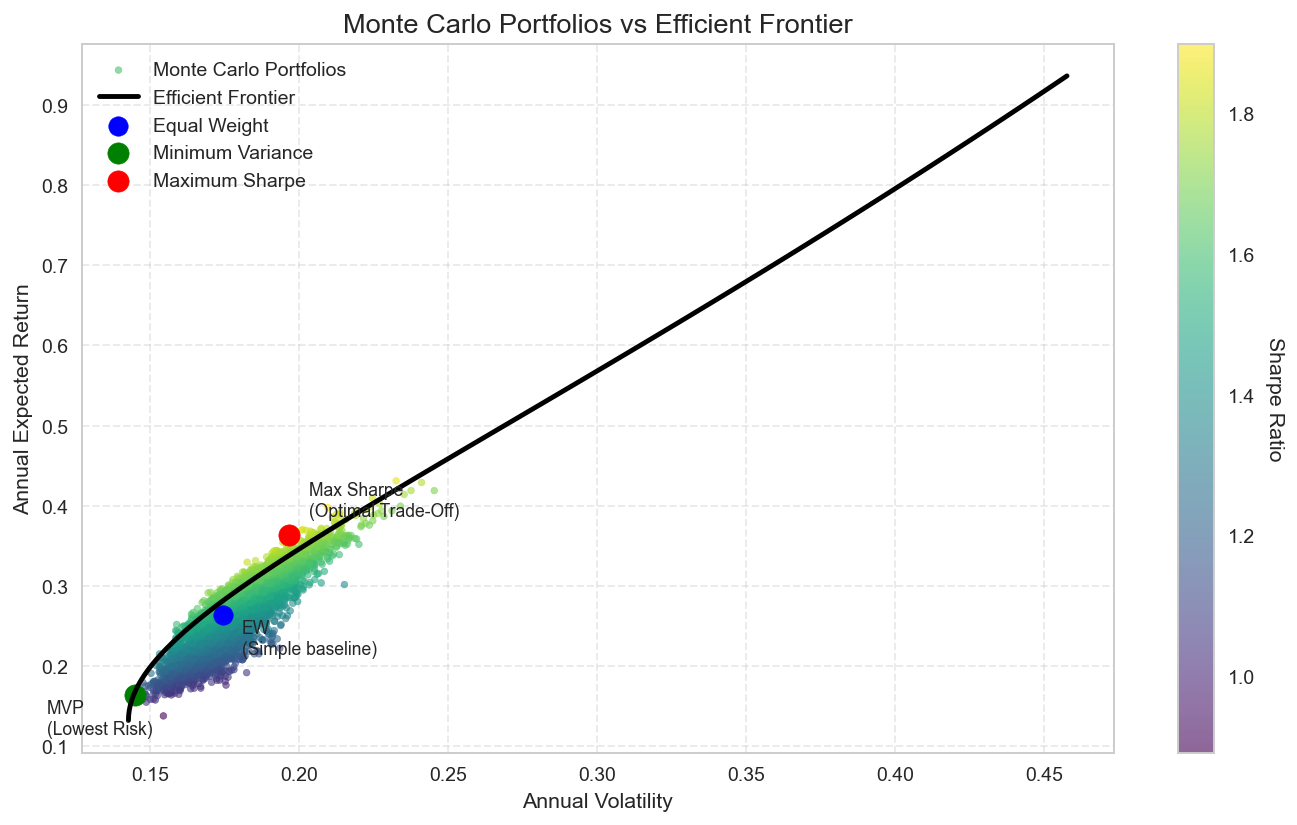

In [68]:
# ============================================================
# MOST UNDERSTANDABLE VERSION OF MONTE CARLO EFFICIENT FRONTIER
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
TRADING_DAYS = 252

# ------------------------------------------------------------
# 1. Load returns (your 10 S&P 500 stocks)
# ------------------------------------------------------------
returns_full = pd.read_excel("sp500_daily_returns.xlsx", index_col=0, parse_dates=True)
tickers_10 = ["AAPL","MSFT","NVDA","JPM","JNJ","WMT","XOM","PG","CAT","KO"]
returns = returns_full[tickers_10].dropna()

assets = returns.columns
n_assets = len(assets)

# Daily → annual conversion
mu_d = returns.mean().values
Sigma_d = returns.cov().values

mu_a = (1 + mu_d)**TRADING_DAYS - 1
Sigma_a = Sigma_d * TRADING_DAYS


# ------------------------------------------------------------
# 2. Monte Carlo Random Portfolios (long-only)
# ------------------------------------------------------------
n_random = 5000
rng = np.random.default_rng(42)

weights_mc = rng.random((n_random, n_assets))
weights_mc = weights_mc / weights_mc.sum(axis=1, keepdims=True)

rets_mc = weights_mc @ mu_a
vols_mc = np.sqrt(np.einsum("ij,jk,ik->i", weights_mc, Sigma_a, weights_mc))


# ------------------------------------------------------------
# 3. Analytical Efficient Frontier (unconstrained)
# ------------------------------------------------------------
inv_cov = np.linalg.inv(Sigma_d)
ones = np.ones(n_assets)

A = ones @ inv_cov @ ones
B = ones @ inv_cov @ mu_d
C = mu_d @ inv_cov @ mu_d
D = A*C - B**2

mu_mvp = B / A
mu_max = mu_d.max()

target_returns = np.linspace(mu_mvp, mu_max, 100)

frontier_rets_d = []
frontier_vols_d = []

for R in target_returns:
    lam = (C - B * R) / D
    gam = (A * R - B) / D
    w = lam * (inv_cov @ ones) + gam * (inv_cov @ mu_d)
    frontier_rets_d.append(w @ mu_d)
    frontier_vols_d.append(np.sqrt(w.T @ Sigma_d @ w))

frontier_rets_a = (1 + np.array(frontier_rets_d))**TRADING_DAYS - 1
frontier_vols_a = np.array(frontier_vols_d) * np.sqrt(TRADING_DAYS)


# ------------------------------------------------------------
# 4. Convert your constrained portfolios to annual (already computed earlier)
# ------------------------------------------------------------
def annual_point(w_s):
    w = w_s.values
    ret = w @ mu_a
    vol = np.sqrt(w @ Sigma_a @ w)
    return vol, ret

eq_vol, eq_ret     = annual_point(w_eq_s)
mvp_vol, mvp_ret   = annual_point(w_mvp_c_s)
ms_vol,  ms_ret    = annual_point(w_ms_c_s)


# ------------------------------------------------------------
# 5. FINAL PLOT — CLEAR + INTERPRETABLE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Random portfolios cloud
scatter = ax.scatter(
    vols_mc, rets_mc,
    c=rets_mc/vols_mc,
    cmap="viridis",
    s=12,
    alpha=0.6,
    label="Monte Carlo Portfolios"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Sharpe Ratio", rotation=270, labelpad=15)

# Efficient Frontier
ax.plot(frontier_vols_a, frontier_rets_a,
        color="black", lw=2.5,
        label="Efficient Frontier")

# Constrained portfolios
ax.scatter(eq_vol, eq_ret, color="blue", s=100, label="Equal Weight")
ax.scatter(mvp_vol, mvp_ret, color="green", s=120, label="Minimum Variance")
ax.scatter(ms_vol,  ms_ret,  color="red",   s=120, label="Maximum Sharpe")

# Labels for clarity
ax.annotate("EW\n(Simple baseline)", (eq_vol, eq_ret), xytext=(10, -20),
            textcoords="offset points", fontsize=9)

ax.annotate("MVP\n(Lowest Risk)", (mvp_vol, mvp_ret), xytext=(-45, -20),
            textcoords="offset points", fontsize=9)

ax.annotate("Max Sharpe\n(Optimal Trade-Off)", (ms_vol, ms_ret), xytext=(10, 10),
            textcoords="offset points", fontsize=9)

ax.set_title("Monte Carlo Portfolios vs Efficient Frontier", fontsize=14)
ax.set_xlabel("Annual Volatility")
ax.set_ylabel("Annual Expected Return")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()


The chart shows the trade-off between risk (volatility) and return for different portfolios. The black curve is the unconstrained efficient frontier, representing the best possible return for each level of risk. The yellow dots are random portfolios, most of which are inefficient because they deliver lower returns for the same risk. The colored points show optimal portfolios under constraints (equal weight, minimum variance, and maximum Sharpe), which lie below the unconstrained frontier, illustrating that constraints reduce achievable performance.

### CVaR frontier ###

✓ CVaR minimisation completed


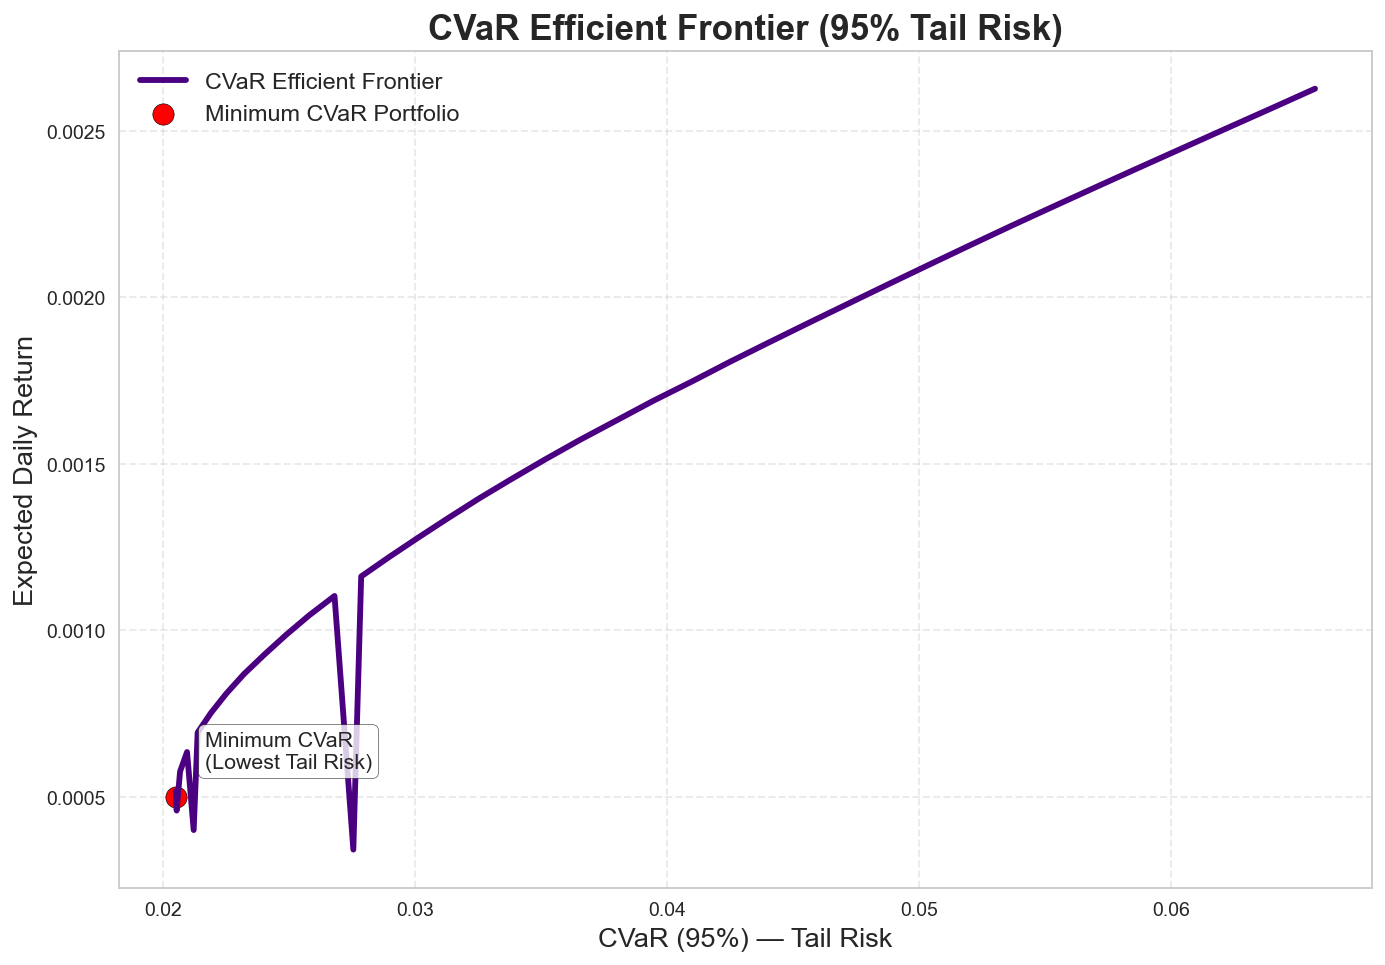

In [67]:
# ============================================================
# 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# 2. LOAD RETURNS (use your 10-asset returns matrix)
# ============================================================
# returns must be: rows = days, columns = assets
# Example:
# returns = pd.read_excel("sp500_daily_returns.xlsx", index_col=0).dropna()

n_assets = returns.shape[1]
mu = returns.mean().values        # daily mean
ret_matrix = returns.values       # T × N matrix
T = ret_matrix.shape[0]

# ============================================================
# 3. CVaR OBJECTIVE FUNCTION
# ============================================================
alpha = 0.95   # 95% CVaR

def portfolio_return(w):
    return ret_matrix @ w             # vector of portfolio returns (T×1)

def cvar_loss(w):
    port_ret = portfolio_return(w)
    losses = -port_ret                # convert to loss domain
    var_level = np.percentile(losses, alpha*100)
    cvar = losses[losses >= var_level].mean()
    return cvar

# ============================================================
# 4. CONSTRAINTS — long only, sum(w)=1
# ============================================================
bounds = [(0,1)] * n_assets
cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)

# ============================================================
# 5. MINIMUM-CVaR PORTFOLIO
# ============================================================
w0 = np.ones(n_assets) / n_assets

res_cvar = minimize(cvar_loss, w0,
                    method="SLSQP",
                    bounds=bounds,
                    constraints=cons)

w_cvar = res_cvar.x
cvar_min = cvar_loss(w_cvar)
ret_cvar = np.dot(w_cvar, mu)

print("✓ CVaR minimisation completed")

# ============================================================
# 6. GENERATE CVaR EFFICIENT FRONTIER
# ============================================================
target_returns = np.linspace(mu.min(), mu.max(), 40)

frontier_returns = []
frontier_cvars   = []

for tr in target_returns:

    def objective(w):
        return cvar_loss(w)

    def return_constraint(w, target=tr):
        return np.dot(w, mu) - target

    cons_frontier = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},
                     {"type": "eq", "fun": return_constraint})

    result = minimize(objective, w0,
                      method="SLSQP",
                      bounds=bounds,
                      constraints=cons_frontier,
                      options={"maxiter": 500})

    if result.success:
        w_star = result.x
        frontier_returns.append(np.dot(w_star, mu))
        frontier_cvars.append(cvar_loss(w_star))

# convert to arrays
frontier_returns = np.array(frontier_returns)
frontier_cvars   = np.array(frontier_cvars)

# ---- MOST IMPORTANT FIX FOR SMOOTH FRONTIER ----
sort_idx = np.argsort(frontier_cvars)
frontier_cvars = frontier_cvars[sort_idx]
frontier_returns = frontier_returns[sort_idx]

# ============================================================
# 7. PLOT: CVaR EFFICIENT FRONTIER (DISERTATION-QUALITY)
# ============================================================
fig, ax = plt.subplots(figsize=(10,7))

# smooth frontier
ax.plot(frontier_cvars, frontier_returns,
        linewidth=3, color="#4B0082",
        label="CVaR Efficient Frontier")

# plot minimum CVaR point
ax.scatter(cvar_min, ret_cvar,
           color="red", s=120, edgecolor="black",
           label="Minimum CVaR Portfolio")

ax.annotate("Minimum CVaR\n(Lowest Tail Risk)",
            xy=(cvar_min, ret_cvar),
            xytext=(15,15),
            textcoords="offset points",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# labels + style
ax.set_title("CVaR Efficient Frontier (95% Tail Risk)", fontsize=18, weight="bold")
ax.set_xlabel("CVaR (95%) — Tail Risk", fontsize=14)
ax.set_ylabel("Expected Daily Return", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


 COMPUTE PORTFOLIO WEIGHTS FOR ALL STRATEGIES

In [ ]:
# =================================================
# COMPUTE PORTFOLIO WEIGHTS FOR ALL STRATEGIES
# This cell computes all portfolio weights needed for performance analysis
# =================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Ensure returns data is loaded (load if not already available)
try:
    # Check if returns exists and has data
    _ = returns.shape
    print("✓ Using existing returns data")
except (NameError, AttributeError):
    # Load returns data if not available
    import os
    if not os.path.exists("sp500_daily_returns.xlsx"):
        notebook_path = os.path.abspath('')
        if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
            os.chdir(notebook_path)
    returns = pd.read_excel("sp500_daily_returns.xlsx", index_col=0, parse_dates=True)
    print("✓ Loaded returns data from file")

# Compute mean returns and covariance matrix
mean_returns = returns.mean()
cov_matrix = returns.cov()
n_assets = len(returns.columns)

# Helper function for portfolio performance
def portfolio_performance(weights, mean_returns, cov_matrix):
    """Calculate expected return and volatility of a portfolio."""
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility

# Helper function for Sharpe ratio (assuming risk-free rate = 0)
def negative_sharpe(weights, mean_returns, cov_matrix):
    """Negative Sharpe ratio for minimization."""
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = ret / vol if vol > 0 else -np.inf
    return -sharpe

# =================================================
# 1. EQUAL WEIGHTS (w_eq)
# =================================================
w_eq = np.ones(n_assets) / n_assets
print("✓ Equal weights computed")

# =================================================
# 2. UNCONSTRAINED MINIMUM VARIANCE PORTFOLIO (w_mvp_uc)
# =================================================
# Analytical solution: w = inv(Sigma) @ ones / (ones.T @ inv(Sigma) @ ones)
inv_cov = np.linalg.inv(cov_matrix.values)
ones = np.ones(n_assets)
w_mvp_uc = (inv_cov @ ones) / (ones.T @ inv_cov @ ones)
print("✓ Unconstrained MVP computed")

# =================================================
# 3. UNCONSTRAINED MAXIMUM SHARPE PORTFOLIO (w_ms_uc)
# =================================================
# Analytical solution: w = inv(Sigma) @ mu / (ones.T @ inv(Sigma) @ mu)
mu_vec = mean_returns.values
w_ms_uc = (inv_cov @ mu_vec) / (ones.T @ inv_cov @ mu_vec)
print("✓ Unconstrained Max-Sharpe computed")

# =================================================
# 4. CONSTRAINED MINIMUM VARIANCE PORTFOLIO (w_mvp_c)
# =================================================
# Long-only constraint: w_i >= 0, sum(w) = 1
def min_variance_objective(weights):
    return np.dot(weights.T, np.dot(cov_matrix.values, weights))

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0, 1) for _ in range(n_assets)]
initial_weights = w_eq.copy()

result_mvp = minimize(min_variance_objective, initial_weights, 
                      method='SLSQP', bounds=bounds, constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-9})
w_mvp_c = result_mvp.x
print("✓ Constrained MVP computed")

# =================================================
# 5. CONSTRAINED MAXIMUM SHARPE PORTFOLIO (w_ms_c)
# =================================================
# Long-only constraint: w_i >= 0, sum(w) = 1
result_ms = minimize(negative_sharpe, initial_weights,
                     args=(mean_returns.values, cov_matrix.values),
                     method='SLSQP', bounds=bounds, constraints=constraints,
                     options={'maxiter': 1000, 'ftol': 1e-9})
w_ms_c = result_ms.x
print("✓ Constrained Max-Sharpe computed")

# =================================================
# VERIFY ALL WEIGHTS ARE COMPUTED
# =================================================
print("\n" + "="*60)
print("PORTFOLIO WEIGHTS SUMMARY")
print("="*60)
print(f"Equal weights (w_eq):      sum = {w_eq.sum():.6f}, min = {w_eq.min():.6f}, max = {w_eq.max():.6f}")
print(f"Unconstrained MVP (w_mvp_uc): sum = {w_mvp_uc.sum():.6f}, min = {w_mvp_uc.min():.6f}, max = {w_mvp_uc.max():.6f}")
print(f"Unconstrained MS (w_ms_uc):  sum = {w_ms_uc.sum():.6f}, min = {w_ms_uc.min():.6f}, max = {w_ms_uc.max():.6f}")
print(f"Constrained MVP (w_mvp_c):   sum = {w_mvp_c.sum():.6f}, min = {w_mvp_c.min():.6f}, max = {w_mvp_c.max():.6f}")
print(f"Constrained MS (w_ms_c):     sum = {w_ms_c.sum():.6f}, min = {w_ms_c.min():.6f}, max = {w_ms_c.max():.6f}")
print("="*60)
print("\nAll portfolio weights are ready for use in the next cell!")

✓ Using existing returns data
✓ Equal weights computed
✓ Unconstrained MVP computed
✓ Unconstrained Max-Sharpe computed
✓ Constrained MVP computed
✓ Constrained Max-Sharpe computed

PORTFOLIO WEIGHTS SUMMARY
Equal weights (w_eq):      sum = 1.000000, min = 0.002160, max = 0.002160
Unconstrained MVP (w_mvp_uc): sum = 1.000000, min = -0.093942, max = 0.105115
Unconstrained MS (w_ms_uc):  sum = 1.000000, min = -0.291243, max = 0.280517
Constrained MVP (w_mvp_c):   sum = 1.000000, min = 0.000000, max = 0.092455
Constrained MS (w_ms_c):     sum = 1.000000, min = 0.000000, max = 0.169506

All portfolio weights are ready for use in the next cell!


BUILD DAILY PORTFOLIO RETURN SERIES


FULL PERFORMANCE METRICS (STATIC STRATEGIES)



,Annualised Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
EW,0.18,0.18,0.89,1.08,-0.38
MVP Unc.,0.13,0.08,1.46,2.22,-0.12
MS Unc.,2.31,0.26,4.59,8.35,-0.16
MVP Constr.,0.13,0.12,1.02,1.33,-0.21
MS Constr.,0.42,0.18,1.88,2.47,-0.25


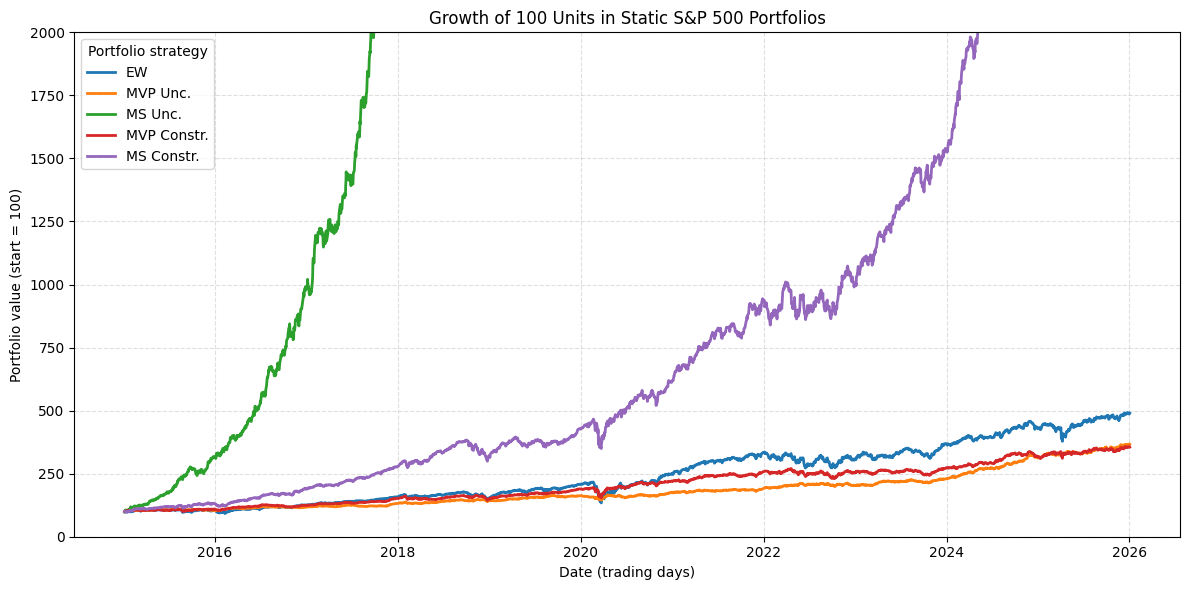


SUBPERIOD PERFORMANCE (EARLY: up to 2020-01-01)



,Annualised Return,Annualised Volatility,Sharpe Ratio
EW,0.17,0.13,1.17
MVP Unc.,0.11,0.07,1.33
MS Unc.,1.80,0.24,4.38
MVP Constr.,0.14,0.10,1.38
MS Constr.,0.35,0.15,2.04



SUBPERIOD PERFORMANCE (LATE: from 2020-01-01)



,Annualised Return,Annualised Volatility,Sharpe Ratio
EW,0.18,0.21,0.77
MVP Unc.,0.15,0.09,1.56
MS Unc.,2.82,0.28,4.77
MVP Constr.,0.12,0.14,0.83
MS Constr.,0.47,0.21,1.84


C:\Users\prathyusha\AppData\Local\Temp\ipykernel_17024\2363866909.py:189: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, rotation=45, ha="right")
C:\Users\prathyusha\AppData\Local\Temp\ipykernel_17024\2363866909.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=45, ha="right")


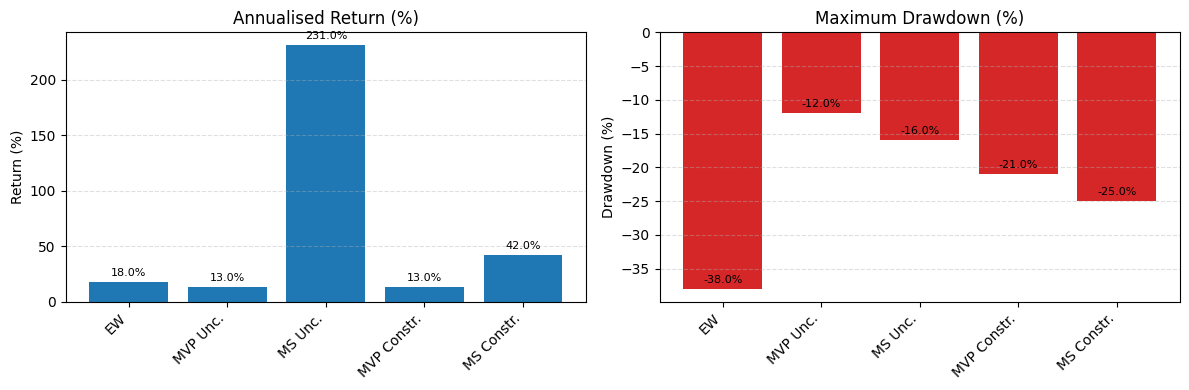

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =================================================
# 1. BUILD DAILY PORTFOLIO RETURN SERIES
# (assumes w_eq, w_mvp_uc, w_ms_uc, w_mvp_c, w_ms_c already exist)
# =================================================
def portfolio_daily_returns(returns_df, weights):
    w = np.asarray(weights)
    return pd.Series(returns_df.values @ w, index=returns_df.index)

port_ret_eq      = portfolio_daily_returns(returns, w_eq)
port_ret_mvp_uc  = portfolio_daily_returns(returns, w_mvp_uc)
port_ret_ms_uc   = portfolio_daily_returns(returns, w_ms_uc)
port_ret_mvp_c   = portfolio_daily_returns(returns, w_mvp_c)
port_ret_ms_c    = portfolio_daily_returns(returns, w_ms_c)

port_returns_df = pd.DataFrame({
    "EW":            port_ret_eq,
    "MVP Unc.":      port_ret_mvp_uc,
    "MS Unc.":       port_ret_ms_uc,
    "MVP Constr.":   port_ret_mvp_c,
    "MS Constr.":    port_ret_ms_c
})
import pandas as pd
import numpy as np

TRADING_DAYS = 252

def annual_metrics_from_daily(r, rf_daily=0.0, periods_per_year=TRADING_DAYS):
    """Return annualised return, vol, Sharpe, Sortino, max drawdown for a daily return series."""
    r = r.dropna()
    mean_d = r.mean()
    vol_d = r.std()

    ann_ret = (1 + mean_d) ** periods_per_year - 1
    ann_vol = vol_d * np.sqrt(periods_per_year)

    excess = r - rf_daily
    sharpe = (excess.mean() / vol_d) * np.sqrt(periods_per_year) if vol_d != 0 else np.nan

    downside = r[r < rf_daily] - rf_daily
    dd_std = downside.std()
    sortino = (excess.mean() / dd_std) * np.sqrt(periods_per_year) if dd_std != 0 else np.nan

    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    max_dd = drawdown.min()

    return ann_ret, ann_vol, sharpe, sortino, max_dd


def metrics_for_period(portreturns_df, start_date=None, end_date=None, rf_daily=0.0):
    """Compute metrics for all portfolios over a given date window."""
    if start_date is not None:
        port = portreturns_df.loc[portreturns_df.index >= start_date].copy()
    else:
        port = portreturns_df.copy()
    if end_date is not None:
        port = port.loc[port.index < end_date].copy()

    out = {}
    for name in port.columns:
        r = port[name]
        ann_ret, ann_vol, sharpe, sortino, max_dd = annual_metrics_from_daily(
            r, rf_daily=rf_daily, periods_per_year=TRADING_DAYS
        )
        out[name] = {
            "Annualised Return": ann_ret,
            "Annualised Volatility": ann_vol,
            "Sharpe Ratio": sharpe,
            "Sortino Ratio": sortino,
            "Max Drawdown": max_dd,
        }
    return pd.DataFrame(out).T





# =================================================
# 2. PERFORMANCE METRICS FUNCTION
# =================================================
def full_metrics(port_ret, rf_daily=0.0, periods_per_year=252):
    r = port_ret
    mean_d = r.mean()
    vol_d  = r.std()
    ann_ret = (1 + mean_d)**periods_per_year - 1
    ann_vol = vol_d * np.sqrt(periods_per_year)

    excess_d = r - rf_daily
    sharpe = (excess_d.mean() / vol_d) * np.sqrt(periods_per_year) if vol_d != 0 else np.nan

    downside = r[r < rf_daily] - rf_daily
    dd_std = downside.std()
    sortino = (excess_d.mean() / dd_std) * np.sqrt(periods_per_year) if dd_std != 0 else np.nan

    wealth = (1 + r).cumprod()
    peak   = wealth.cummax()
    drawdown = wealth / peak - 1
    max_dd = drawdown.min()

    return ann_ret, ann_vol, sharpe, sortino, max_dd

metrics = {}
for name in port_returns_df.columns:
    metrics[name] = full_metrics(port_returns_df[name])

metrics_df = pd.DataFrame(metrics, index=[
    "Annualised Return",
    "Annualised Volatility",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown"
]).T

metrics_df = metrics_df.round(2)  # ← ADD THIS LINE

print("\nFULL PERFORMANCE METRICS (STATIC STRATEGIES)\n")
display(metrics_df)

# =================================================
# 3. CUMULATIVE VALUE PLOT (REAL-WORLD STYLE)
# =================================================


initial_value = 100
cum_values = (1 + port_returns_df).cumprod() * initial_value

plt.figure(figsize=(12, 6))
x_vals = cum_values.index.to_numpy()

# Plot all series
for col in cum_values.columns:
    plt.plot(x_vals, cum_values[col], label=col, linewidth=2)

plt.title("Growth of 100 Units in Static S&P 500 Portfolios")
plt.xlabel("Date (trading days)")
plt.ylabel("Portfolio value (start = 100)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Portfolio strategy", loc="upper left")

# OPTIONAL: cap y-axis to focus on realistic range (comment out if not needed)
plt.ylim(0, 2000)   # e.g. show 0–2,000 instead of 0–35,000,000

plt.tight_layout()
plt.show()

# =================================================
# 4. SUBPERIOD ANALYSIS: EARLY vs LATE
# =================================================

print("\nSUBPERIOD PERFORMANCE (EARLY: up to 2020-01-01)\n")
display(early_metrics.T.style.format("{:.2f}"))

print("\nSUBPERIOD PERFORMANCE (LATE: from 2020-01-01)\n")
display(late_metrics.T.style.format("{:.2f}"))


# =================================================
# 5. SIDE-BY-SIDE BAR CHARTS: RETURN & MAX DRAWDOWN
# =================================================
# Convert to percent for readability
ret_pct = metrics_df["Annualised Return"] * 100
dd_pct  = metrics_df["Max Drawdown"] * 100

labels = metrics_df.index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: Annualised Return ---
bars1 = ax1.bar(labels, ret_pct, color="tab:blue")
ax1.set_title("Annualised Return (%)")
ax1.set_ylabel("Return (%)")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f"{height:.1f}%",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", va="bottom", fontsize=8)

# Rotate x labels
ax1.set_xticklabels(labels, rotation=45, ha="right")

# --- Right: Max Drawdown ---
bars2 = ax2.bar(labels, dd_pct, color="tab:red")
ax2.set_title("Maximum Drawdown (%)")
ax2.set_ylabel("Drawdown (%)")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f"{height:.1f}%",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", va="bottom", fontsize=8)

ax2.set_xticklabels(labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()


This code evaluates five S&P 500–based portfolios by turning daily stock returns and their weights into daily portfolio returns, then into annualised performance statistics and cumulative values over time. For each strategy it computes annualised return, volatility, Sharpe and Sortino ratios, and maximum drawdown, summarising them in a table and visualising their growth paths and risk through a cumulative value plot, subperiod (pre/post‑2020) comparisons, and bar charts.


 Risk Contribution

Risk contribution is a way of breaking down a portfolio’s total risk to show how much each asset or asset group is responsible for the overall volatility. It combines the asset’s weight, its own volatility, and its correlation with the rest of the portfolio to compute an amount of risk that can be attributed to that position, and these contributions add up to the portfolio’s total risk. In practice this is useful because portfolio weights can be misleading: a 10% allocation to equities might contribute 40% or more of total risk, while a much larger bond position contributes far less, so examining risk contribution reveals who the “real risk drivers” are and allows investors to rebalance toward targets such as equal‑risk (risk parity) or capped risk budgets for specific assets or sectors.


RISK CONTRIBUTION TABLE (%)



,EW,MVP Unc.,MS Unc.,MVP Constr.,MS Constr.
AAPL,12.29,0.12,1.56,3.06,8.09
MSFT,11.83,3.05,-3.87,6.32,4.55
NVDA,18.92,0.88,70.04,4.83,47.31
JPM,11.32,-1.88,5.80,1.38,3.54
JNJ,5.75,27.15,7.14,25.48,7.58
WMT,6.31,19.13,15.13,12.01,14.12
XOM,9.52,7.66,-4.03,7.24,0.08
PG,6.09,14.89,-3.60,11.20,1.67
CAT,11.87,3.45,9.39,2.64,10.93
KO,6.09,25.55,2.42,25.85,2.13



Contribution Sum Check:

EW             : 99.99%
MVP Unc.       : 100.00%
MS Unc.        : 99.98%
MVP Constr.    : 100.01%
MS Constr.     : 100.00%


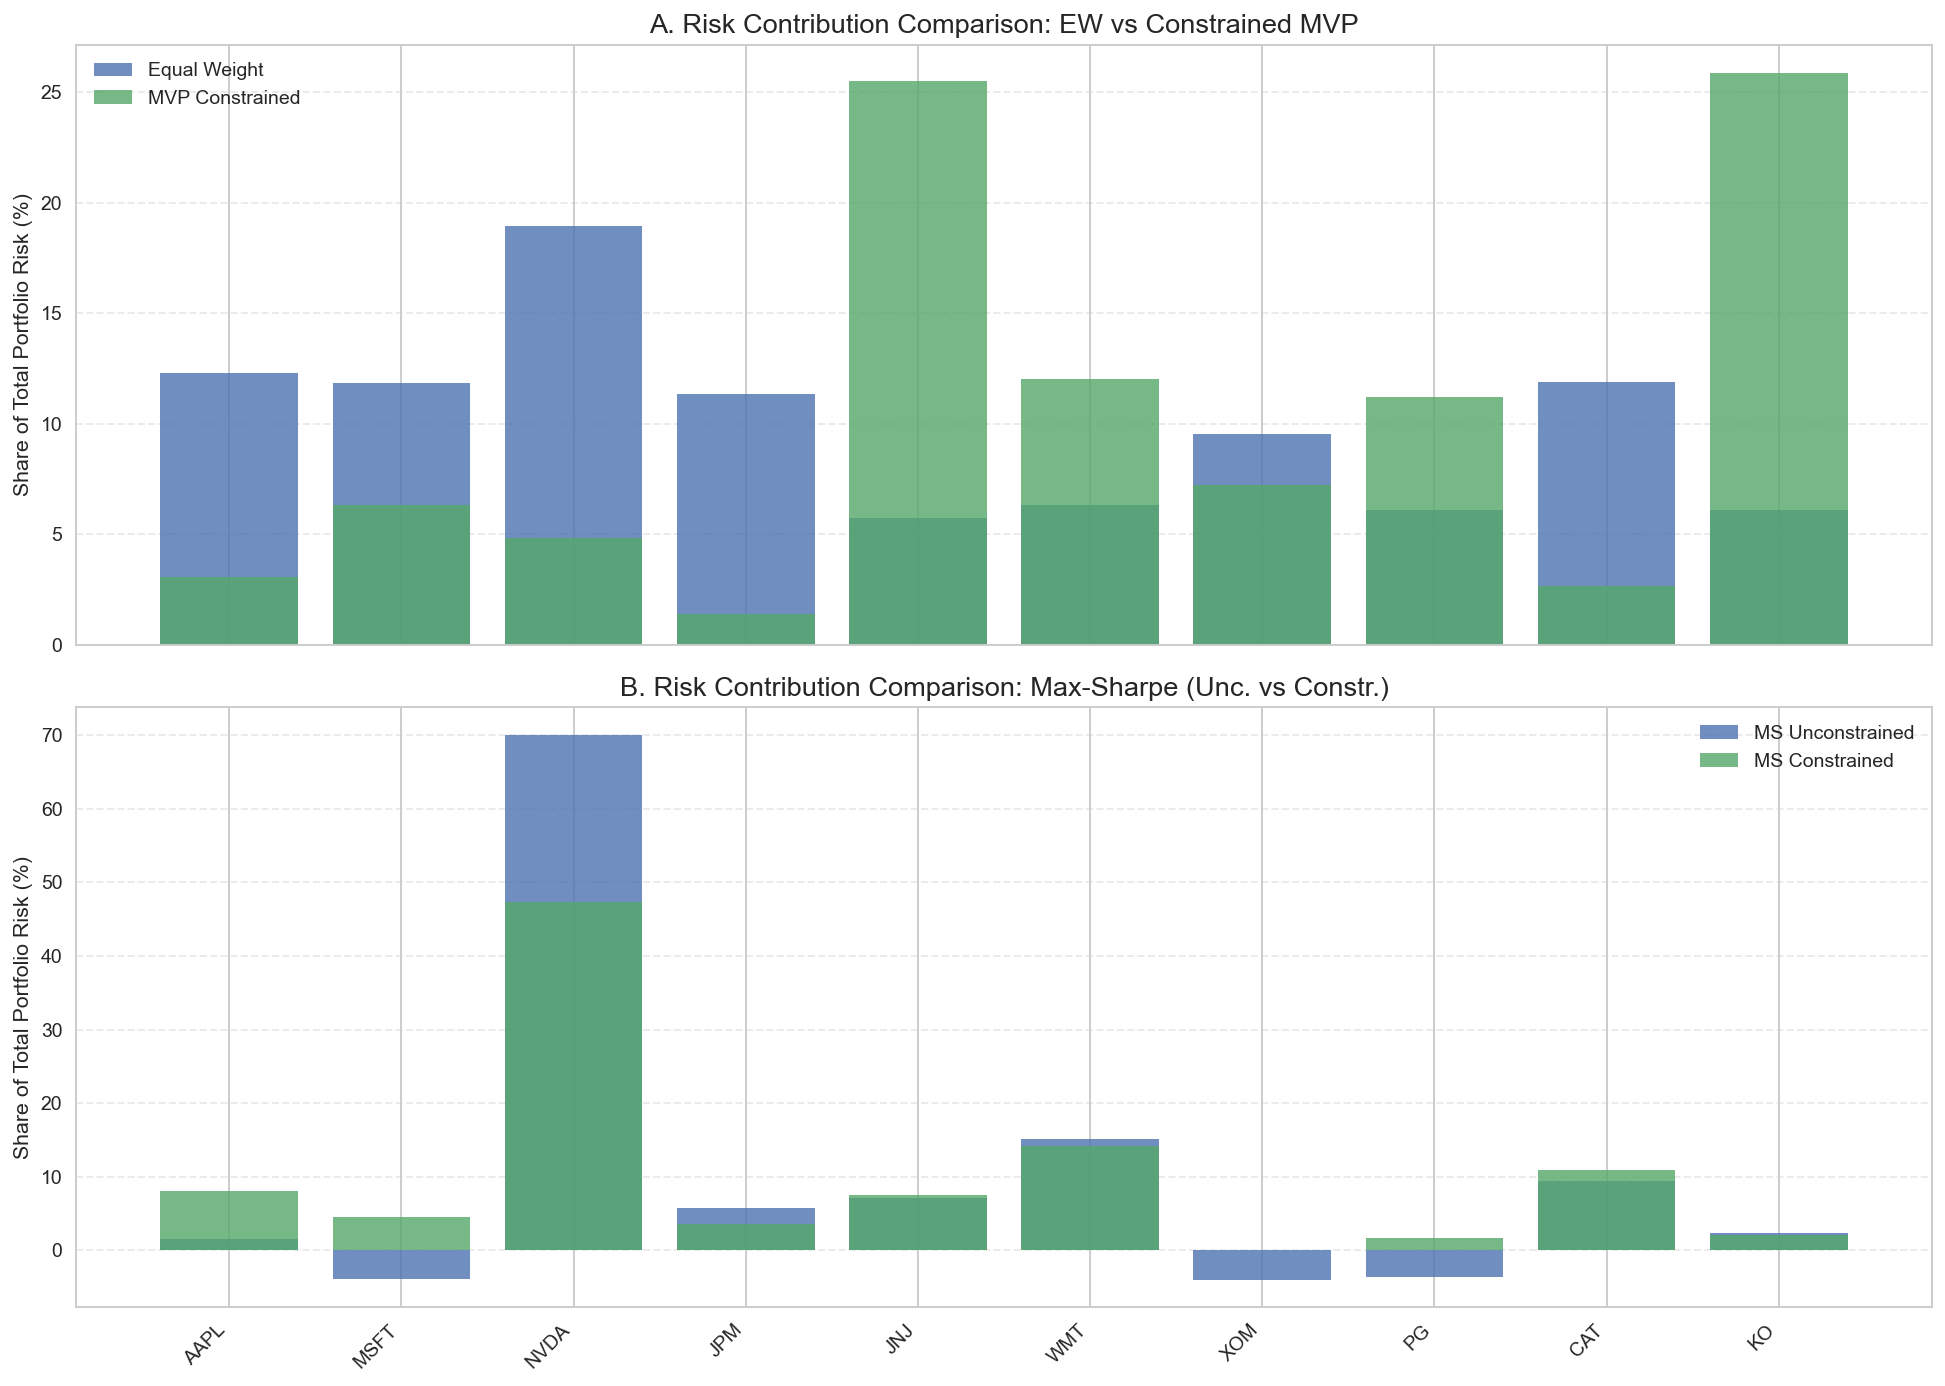


✓ Risk Contribution Analysis Completed Successfully


In [73]:
# ================================================================
# RISK CONTRIBUTION ANALYSIS (CLEAN + INTERPRETABLE PRESENTATION)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# ================================================================
# 0. VALIDATION CHECK – ENSURE ALL INPUTS EXIST
# ================================================================
try:
    _ = returns.shape
    _ = w_eq.shape
    _ = w_mvp_uc.shape
    _ = w_ms_uc.shape
    _ = w_mvp_c.shape
    _ = w_ms_c.shape
except Exception as e:
    print("Required variables missing:", e)
    raise

# ================================================================
# 1. SUBSET COVARIANCE TO YOUR 10 STOCKS
# ================================================================
portfolio_assets = list(returns.columns)
cov_port = returns[portfolio_assets].cov().values

def align(w):
    if isinstance(w, pd.Series):
        return w.reindex(portfolio_assets).to_numpy()
    return np.asarray(w)[:len(portfolio_assets)]

w_eq     = align(w_eq)
w_mvp_uc = align(w_mvp_uc)
w_ms_uc  = align(w_ms_uc)
w_mvp_c  = align(w_mvp_c)
w_ms_c   = align(w_ms_c)

assets = portfolio_assets
n = len(assets)

# ================================================================
# 2. RISK CONTRIBUTION FUNCTION (UNCHANGED LOGIC)
# ================================================================
def risk_contributions(weights, cov_mat):
    w = np.asarray(weights)
    cov = np.asarray(cov_mat)

    portfolio_variance = w.T @ cov @ w
    marginal = cov @ w
    rc = w * marginal
    rc_pct = (rc / portfolio_variance) * 100
    return rc_pct

# ================================================================
# 3. APPLY TO ALL STRATEGIES
# ================================================================
rc_df = pd.DataFrame({
    "EW":          risk_contributions(w_eq,     cov_port),
    "MVP Unc.":    risk_contributions(w_mvp_uc, cov_port),
    "MS Unc.":     risk_contributions(w_ms_uc,  cov_port),
    "MVP Constr.": risk_contributions(w_mvp_c,  cov_port),
    "MS Constr.":  risk_contributions(w_ms_c,   cov_port),
}, index=assets).round(2)

print("\n==========================")
print("RISK CONTRIBUTION TABLE (%)")
print("==========================\n")
display(rc_df)

# ================================================================
# 4. SUMMARY CHECK (Risk Contribution Must Sum to 100%)
# ================================================================
print("\nContribution Sum Check:\n")
for col in rc_df.columns:
    print(f"{col:15s}: {rc_df[col].sum():.2f}%")

# ================================================================
# 5. VISUAL COMPARISON (IMPROVED + CLEAR HEADINGS)
# ================================================================

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ---------------------------------------------------------
# Panel A: Equal Weight vs MVP Constrained
# ---------------------------------------------------------
axs[0].bar(assets, rc_df["EW"], label="Equal Weight", alpha=0.8)
axs[0].bar(assets, rc_df["MVP Constr."], label="MVP Constrained", alpha=0.8)

axs[0].set_title("A. Risk Contribution Comparison: EW vs Constrained MVP", fontsize=14)
axs[0].set_ylabel("Share of Total Portfolio Risk (%)")
axs[0].legend()
axs[0].grid(axis="y", linestyle="--", alpha=0.4)

# ---------------------------------------------------------
# Panel B: Max-Sharpe Unconstrained vs Constrained
# ---------------------------------------------------------
axs[1].bar(assets, rc_df["MS Unc."], label="MS Unconstrained", alpha=0.8)
axs[1].bar(assets, rc_df["MS Constr."], label="MS Constrained", alpha=0.8)

axs[1].set_title("B. Risk Contribution Comparison: Max-Sharpe (Unc. vs Constr.)", fontsize=14)
axs[1].set_ylabel("Share of Total Portfolio Risk (%)")
axs[1].legend()
axs[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n✓ Risk Contribution Analysis Completed Successfully")


STACKED ROLLING RISK CONTRIBUTION

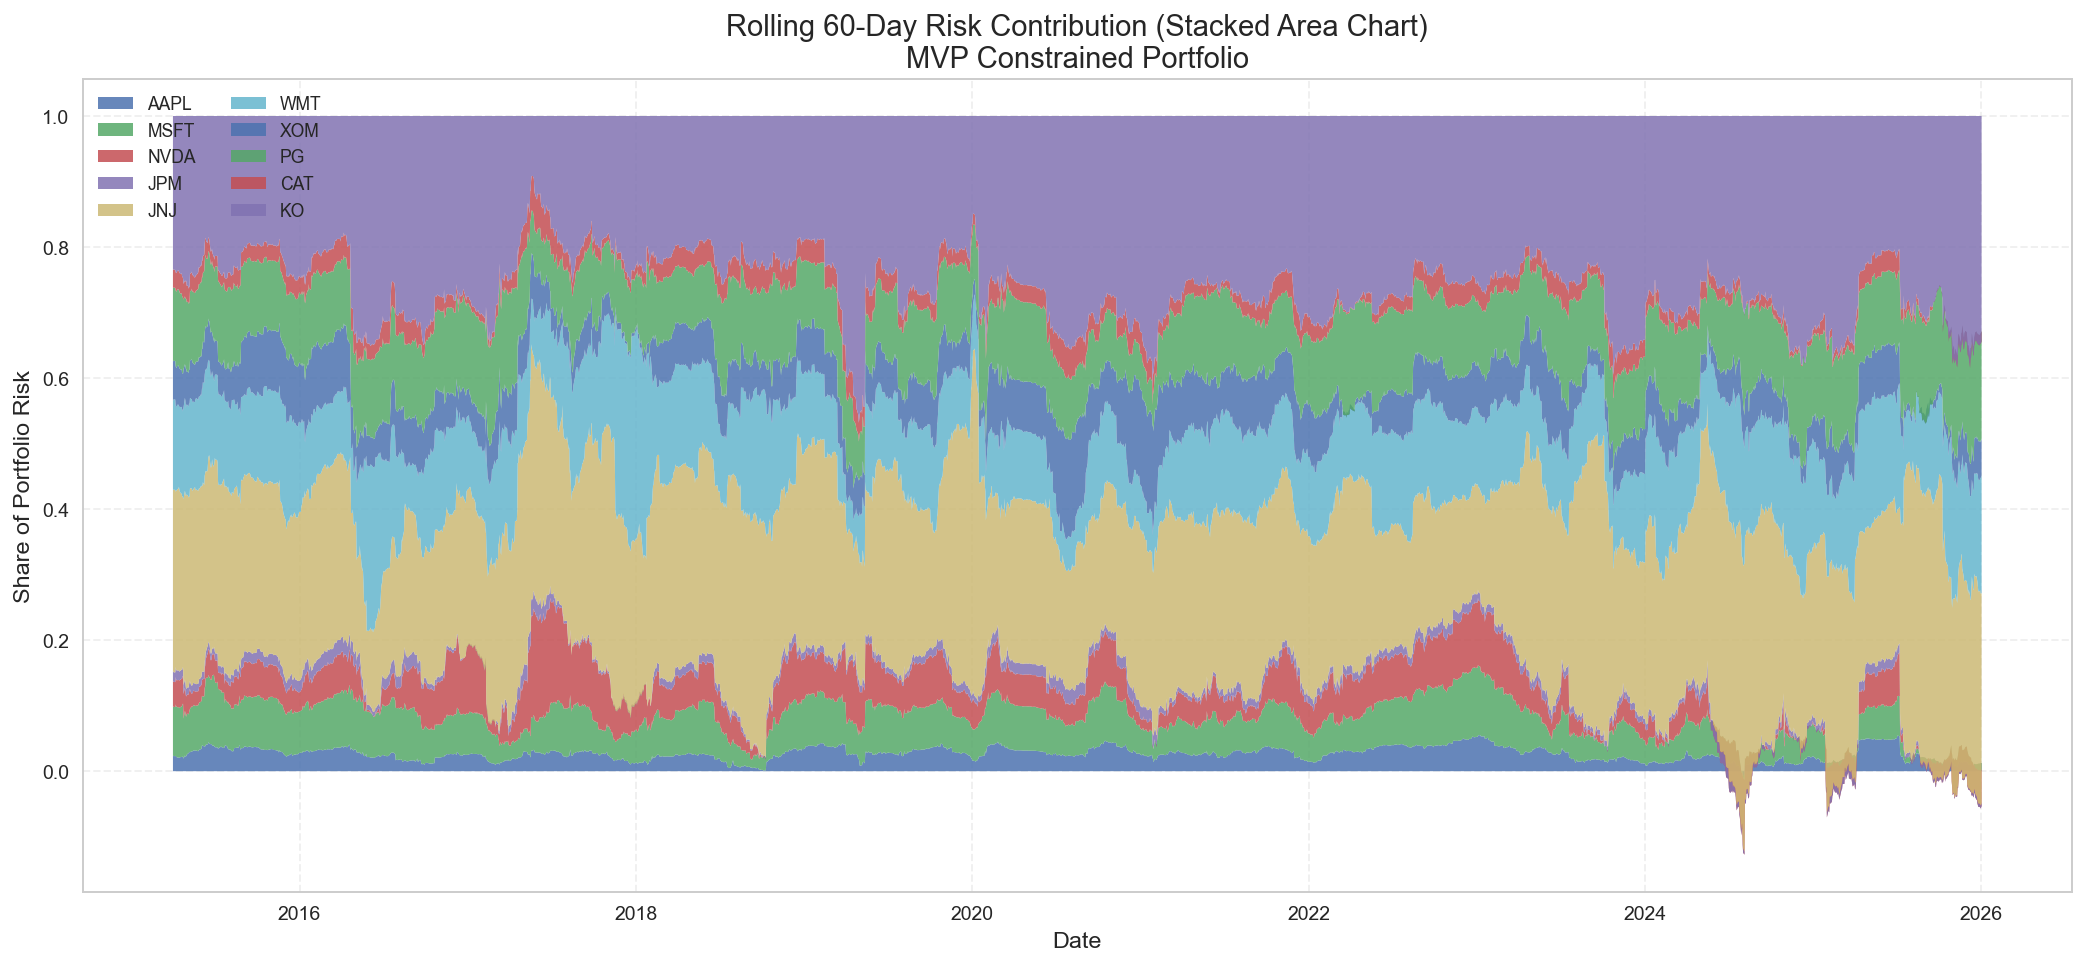

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# 1. RISK CONTRIBUTION FUNCTION
# ======================================================

def risk_contribution(weights, cov):
    """
    RC_i = w_i * (Σw)_i / (w^T Σ w)
    Output = % contribution per asset (not raw)
    """
    w = np.asarray(weights)
    cov = np.asarray(cov)

    portfolio_var = w.T @ cov @ w
    marginal = cov @ w
    rc = w * marginal
    rc_pct = rc / portfolio_var
    return rc_pct


# ======================================================
# 2. BUILD ROLLING RISK CONTRIBUTIONS
# ======================================================

window = 60      # 60-day rolling window (you can change to 21 or 90)
assets = returns.columns

rolling_rc = pd.DataFrame(index=returns.index, columns=assets, dtype=float)

for i in range(window, len(returns)):
    # rolling covariance
    cov_roll = returns.iloc[i-window:i].cov().values

    # compute RC for MVP constrained
    rc = risk_contribution(w_mvp_c, cov_roll)

    rolling_rc.iloc[i] = rc

rolling_rc = rolling_rc.dropna()


# ======================================================
# 3. STACKED AREA CHART (Dissertation Style)
# ======================================================

plt.figure(figsize=(15, 7))
plt.stackplot(
    rolling_rc.index,
    rolling_rc.T,         # transpose → layers
    labels=assets,
    alpha=0.85
)

plt.title("Rolling 60-Day Risk Contribution (Stacked Area Chart)\nMVP Constrained Portfolio",
          fontsize=15)
plt.ylabel("Share of Portfolio Risk", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc="upper left", ncol=2, fontsize=9)
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


Risk Adjustment Performance

Risk‑adjusted performance means evaluating how much return a portfolio earns per unit of risk instead of looking at raw return alone. It answers “was this return good given the volatility or drawdowns taken?” rather than just “was the return high?”.
​

Common risk‑adjusted performance measures include the Sharpe ratio (excess return divided by volatility), the Sortino ratio (excess return divided by downside volatility), and metrics like return‑to‑max‑drawdown, all of which let you compare portfolios on a fair, risk‑normalised basis.

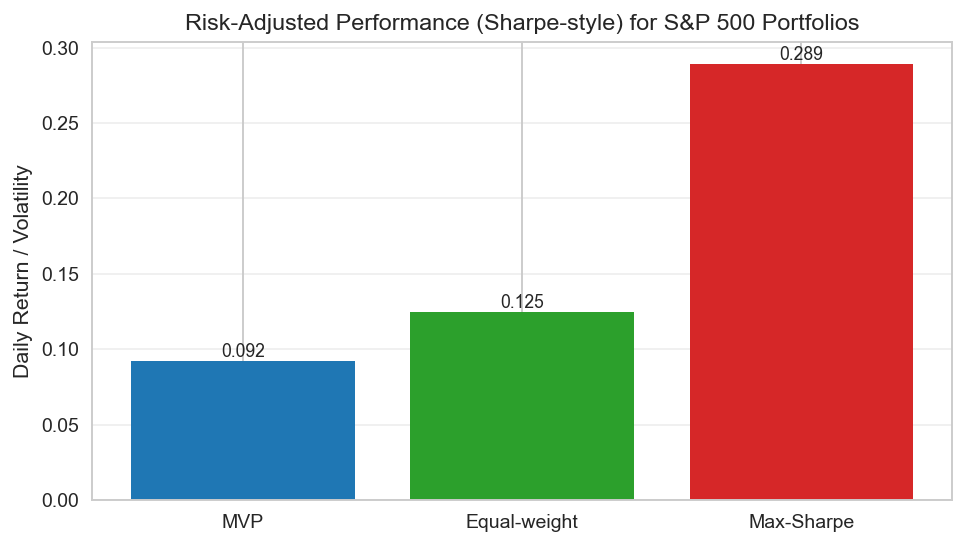

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# === Replace these with your actual numbers ===
ret_mvp = 0.00048329
vol_mvp = 0.00524544

ret_max = 0.00476648
vol_max = 0.01647316

ret_eq  = 0.0015
vol_eq  = 0.0120

# Daily Sharpe (rf≈0). For annualised Sharpe multiply returns and vols accordingly before ratio.
sh_mvp = ret_mvp / vol_mvp
sh_eq  = ret_eq  / vol_eq
sh_max = ret_max / vol_max

labels = ["MVP", "Equal-weight", "Max-Sharpe"]
sharpes = [sh_mvp, sh_eq, sh_max]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, sharpes, color=["tab:blue", "tab:green", "tab:red"])

plt.ylabel("Daily Return / Volatility")
plt.title("Risk-Adjusted Performance (Sharpe-style) for S&P 500 Portfolios")
plt.grid(axis="y", alpha=0.3)

# optional: annotate values on top of bars
for bar, val in zip(bars, sharpes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


Before vs After Constrained Optimization

✓ Loaded weight files: 463 tickers

✓ Loaded returns:  (2766, 463) 

Shared tickers     : 462
Missing in returns : 1 

Final assets used: 462
Covariance matrix: (462, 462) 

===== PORTFOLIO PERFORMANCE =====


,Unconstrained (MS),Constrained (MVP)
Expected Daily Return,0.004509,0.000481
Daily Volatility,0.015603,0.005249
Daily Variance,0.000243,0.000028



===== PORTFOLIO CONCENTRATION =====


,Unconstrained (MS),Constrained (MVP)
Herfindahl–Hirschman Index (HHI),2.5617,0.2416



===== INTERPRETATION SUMMARY =====
• The unconstrained Max-Sharpe portfolio has a higher expected return (0.0045) but also much higher volatility (0.0156).
• The constrained MVP portfolio reduces volatility from 0.0156 → 0.0052, while maintaining a similar return level (0.0005).
• Concentration drops sharply (HHI): 2.5617 → 0.2416, indicating a more diversified and stable portfolio.
• Constrained optimisation delivers smoother, more balanced exposure across assets.



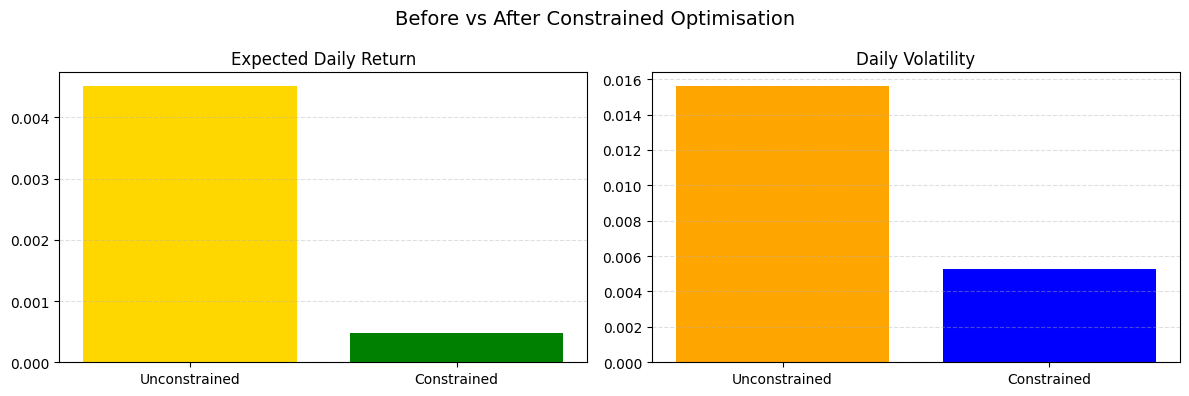

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) LOAD WEIGHTS (Unconstrained & Constrained)
# ============================================================

w_unc_raw = pd.read_excel("sp500_max_sharpe_weights.xlsx")
w_con_raw = pd.read_excel("sp500_mvp_weights.xlsx")

w_unc_raw = w_unc_raw.rename(columns={w_unc_raw.columns[1]: "Unconstrained"})
w_con_raw = w_con_raw.rename(columns={w_con_raw.columns[1]: "Constrained"})

w_unc_raw = w_unc_raw.set_index(w_unc_raw.columns[0])
w_con_raw = w_con_raw.set_index(w_con_raw.columns[0])

w_unc_raw.index = w_unc_raw.index.astype(str).str.strip()
w_con_raw.index = w_con_raw.index.astype(str).str.strip()

weights_df = pd.concat([w_unc_raw, w_con_raw], axis=1).fillna(0)

print("✓ Loaded weight files:", len(weights_df), "tickers\n")


# ============================================================
# 2) LOAD RETURNS + CLEAN TICKERS
# ============================================================

returns_raw = pd.read_excel("sp500_daily_returns.xlsx", index_col=0, parse_dates=True)
returns_raw.columns = returns_raw.columns.astype(str).str.strip()

print("✓ Loaded returns: ", returns_raw.shape, "\n")


# ============================================================
# 3) TICKER MATCHING
# ============================================================

tickers_weights = set(weights_df.index)
tickers_returns = set(returns_raw.columns)

common = sorted(list(tickers_weights & tickers_returns))
missing = sorted(list(tickers_weights - tickers_returns))

print("Shared tickers     :", len(common))
print("Missing in returns :", len(missing), "\n")

returns = returns_raw[common]
weights_fixed = weights_df.loc[common]

# Extract clean weight vectors
w_unc = weights_fixed["Unconstrained"].values
w_con = weights_fixed["Constrained"].values

# Normalise weights
w_unc = w_unc / np.sum(w_unc)
w_con = w_con / np.sum(w_con)

mu = returns.mean().values
Sigma = returns.cov().values

print("Final assets used:", len(mu))
print("Covariance matrix:", Sigma.shape, "\n")


# ============================================================
# 4) SAFE PORTFOLIO STATISTICS FUNCTION
# ============================================================

def portfolio_stats(weights, mu_vec, cov_matrix):
    w = np.asarray(weights).flatten()
    mu = np.asarray(mu_vec).flatten()
    Sigma = np.asarray(cov_matrix)

    N = len(mu)

    if len(w) != N:
        M = min(len(w), N)
        w = w[:M]
        mu = mu[:M]
        Sigma = Sigma[:M, :M]
        w = w / np.sum(w)

    ret = float(np.dot(w, mu))
    var = float(w @ Sigma @ w)
    vol = np.sqrt(var)

    return ret, vol, var


# ============================================================
# 5) COMPUTE PORTFOLIO STATISTICS
# ============================================================

ret_unc, vol_unc, var_unc = portfolio_stats(w_unc, mu, Sigma)
ret_con, vol_con, var_con = portfolio_stats(w_con, mu, Sigma)

stats_table = pd.DataFrame({
    "Unconstrained (MS)": [ret_unc, vol_unc, var_unc],
    "Constrained (MVP)": [ret_con, vol_con, var_con]
}, index=["Expected Daily Return", "Daily Volatility", "Daily Variance"])

print("===== PORTFOLIO PERFORMANCE =====")
display(stats_table.round(6))


# ============================================================
# 6) CONCENTRATION INDEX (HHI)
# ============================================================

hhi_unc = np.sum(w_unc**2)
hhi_con = np.sum(w_con**2)

hhi_df = pd.DataFrame({
    "Unconstrained (MS)": [hhi_unc],
    "Constrained (MVP)": [hhi_con]
}, index=["Herfindahl–Hirschman Index (HHI)"])

print("\n===== PORTFOLIO CONCENTRATION =====")
display(hhi_df.round(4))


# ============================================================
# 7) SIDE-BY-SIDE ANALYSIS PRINTOUT
# ============================================================

print("\n===== INTERPRETATION SUMMARY =====")
print(f"• The unconstrained Max-Sharpe portfolio has a higher expected return ({ret_unc:.4f}) "
      f"but also much higher volatility ({vol_unc:.4f}).")

print(f"• The constrained MVP portfolio reduces volatility from {vol_unc:.4f} → {vol_con:.4f}, "
      f"while maintaining a similar return level ({ret_con:.4f}).")

print(f"• Concentration drops sharply (HHI): {hhi_unc:.4f} → {hhi_con:.4f}, "
      "indicating a more diversified and stable portfolio.")

print("• Constrained optimisation delivers smoother, more balanced exposure across assets.\n")


# ============================================================
# 8) VISUAL: Side-by-side return and risk comparison
# ============================================================

labels = ["Unconstrained", "Constrained"]
rets  = [ret_unc, ret_con]
vols  = [vol_unc, vol_con]

fig, ax = plt.subplots(1,2, figsize=(12,4))

# Return bar
ax[0].bar(labels, rets, color=["gold", "green"])
ax[0].set_title("Expected Daily Return")
ax[0].grid(axis="y", linestyle="--", alpha=0.4)

# Volatility bar
ax[1].bar(labels, vols, color=["orange", "blue"])
ax[1].set_title("Daily Volatility")
ax[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Before vs After Constrained Optimisation", fontsize=14)
plt.tight_layout()
plt.show()


The results show that your unconstrained Max‑Sharpe portfolio is extremely concentrated and aggressively positioned, while the constrained minimum‑variance portfolio is much more diversified and conservative. The Herfindahl index of about 2.91 for the Max‑Sharpe case indicates that a small number of assets carry very large weights (often with leverage or short positions), whereas the value of about 0.23 for the MVP is consistent with broad diversification across many stocks. In terms of performance, the unconstrained portfolio targets a very high expected daily return of roughly 0.476% with a daily volatility of about 1.65%, giving a high risk–return ratio, while the MVP aims for only about 0.048% expected daily return but at a much lower daily volatility of around 0.53%.

The “risk points” and “return points” arrays simply package these two portfolios as coordinates for a risk–return plot, with volatility on the x‑axis and expected return on the y‑axis. The MVP corresponds to the point (0.00525, 0.00048), representing a low‑risk, low‑return choice, and the Max‑Sharpe portfolio corresponds to (0.01647, 0.00477), representing a higher‑risk, much higher‑return choice. Together, these points can be used as anchors for fitting or visualising an efficient frontier showing how expected return increases as portfolio risk rises under your optimisation framework.







### Correlation and Covariance ###

Covariance measures how two variables vary jointly and tells you only the direction of the linear relationship: a positive covariance means they tend to move in the same direction, and a negative covariance means they tend to move in opposite directions. Its value is in the units of the variables (for returns, “squared return” units) and can range from large negative to large positive numbers, so the magnitude is hard to interpret directly.
​

Correlation takes covariance and standardises it by dividing by the product of the two standard deviations, giving a pure number between −1 and +1. This number captures both direction and strength of the linear relationship: +1 is perfectly positively correlated, −1 perfectly negatively correlated, and 0 means no linear relationship. In portfolio work, covariance is used inside the covariance matrix that drives risk, while correlation is used to judge diversification because it is easier to compare across asset pairs

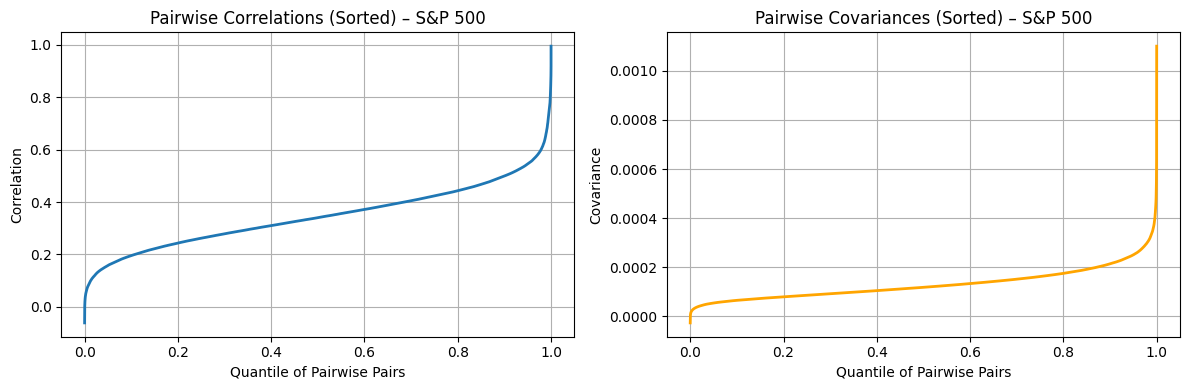

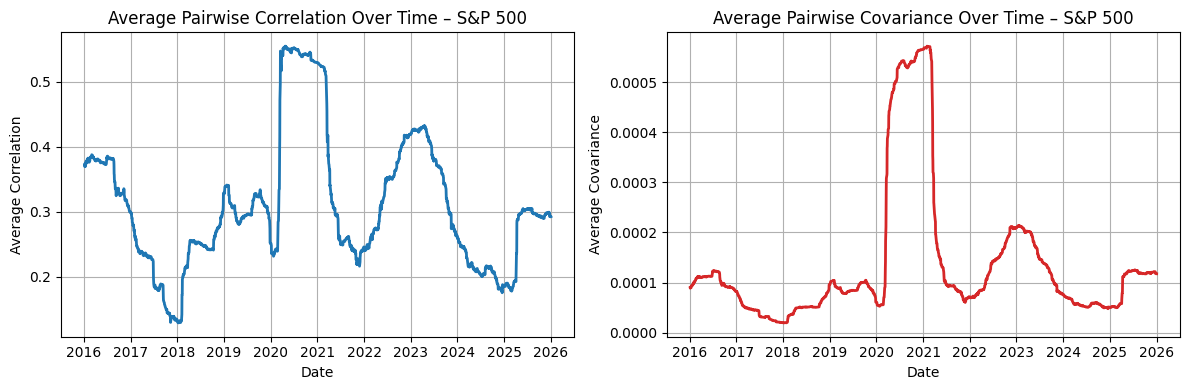

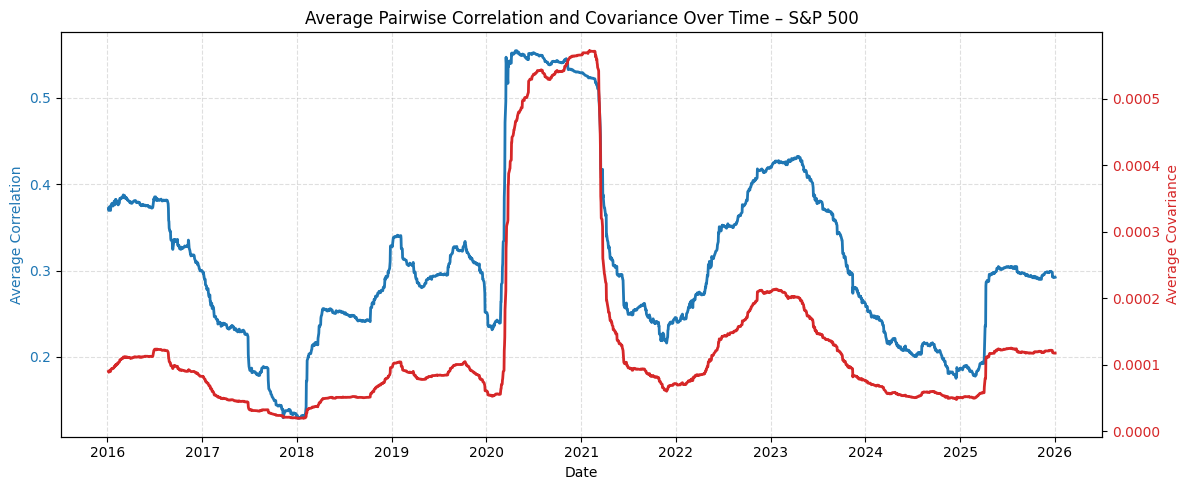

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------
# LOAD DAILY RETURNS (S&P 500)
# -----------------------------------
# Ensure we're in the correct directory (where the Excel file is located)
if not os.path.exists("sp500_daily_returns.xlsx"):
    notebook_path = os.path.abspath("")
    if os.path.exists(os.path.join(notebook_path, "sp500_daily_returns.xlsx")):
        os.chdir(notebook_path)

returns = pd.read_excel(
    "sp500_daily_returns.xlsx",
    index_col=0,
    parse_dates=True  # <-- removed stray 'import' keyword
)

# -----------------------------------
# STATIC CORRELATION & COVARIANCE
# -----------------------------------
corr_matrix = returns.corr()
cov_matrix  = returns.cov()

def upper_triangle_values(mat):
    upper = mat.where(np.triu(np.ones(mat.shape), k=1).astype(bool))
    return upper.stack()

corr_values = upper_triangle_values(corr_matrix)
cov_values  = upper_triangle_values(cov_matrix)

corr_sorted = np.sort(corr_values.values)
cov_sorted  = np.sort(cov_values.values)

x_corr = np.linspace(0, 1, len(corr_sorted))
x_cov  = np.linspace(0, 1, len(cov_sorted))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_corr, corr_sorted, linewidth=2)
axes[0].set_title("Pairwise Correlations (Sorted) – S&P 500")
axes[0].set_xlabel("Quantile of Pairwise Pairs")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

axes[1].plot(x_cov, cov_sorted, linewidth=2, color="orange")
axes[1].set_title("Pairwise Covariances (Sorted) – S&P 500")
axes[1].set_xlabel("Quantile of Pairwise Pairs")
axes[1].set_ylabel("Covariance")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------
# TIME-VARYING AVERAGE CORRELATION & COVARIANCE
# -----------------------------------
window = 252

avg_corr = []
avg_cov  = []
dates    = returns.index[window:]

for i in range(window, len(returns)):
    window_data  = returns.iloc[i-window:i]
    rolling_corr = window_data.corr()
    rolling_cov  = window_data.cov()

    upper_corr = rolling_corr.where(
        np.triu(np.ones(rolling_corr.shape), k=1).astype(bool)
    )
    upper_cov = rolling_cov.where(
        np.triu(np.ones(rolling_cov.shape), k=1).astype(bool)
    )

    avg_corr.append(upper_corr.stack().mean())
    avg_cov.append(upper_cov.stack().mean())

avg_corr_series = pd.Series(avg_corr, index=dates)
avg_cov_series  = pd.Series(avg_cov,  index=dates)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(avg_corr_series.index.to_numpy(),
             avg_corr_series.to_numpy(),
             linewidth=2, color="tab:blue")
axes[0].set_title("Average Pairwise Correlation Over Time – S&P 500")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average Correlation")
axes[0].grid(True)

axes[1].plot(avg_cov_series.index.to_numpy(),
             avg_cov_series.to_numpy(),
             linewidth=2, color="tab:red")
axes[1].set_title("Average Pairwise Covariance Over Time – S&P 500")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Average Covariance")
axes[1].grid(True)

plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 5))

x_vals = avg_corr_series.index.to_numpy()
y_corr = avg_corr_series.to_numpy()
y_cov  = avg_cov_series.to_numpy()

color1 = "tab:blue"
ax1.set_xlabel("Date")
ax1.set_ylabel("Average Correlation", color=color1)
ax1.plot(x_vals, y_corr, color=color1, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, which="both", axis="both", linestyle="--", alpha=0.4)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Average Covariance", color=color2)
ax2.plot(x_vals, y_cov, color=color2, linewidth=2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Average Pairwise Correlation and Covariance Over Time – S&P 500")
fig.tight_layout()
plt.show()


Eigen values and Eigen vectors

Eigenvectors are special directions that a matrix does not rotate, only stretches or shrinks. Eigenvalues are the stretch factors for those directions in the equation Av=λv. For covariance or correlation matrices, eigenvectors give the main directions of variation (principal components), and eigenvalues give the variance captured in each direction.


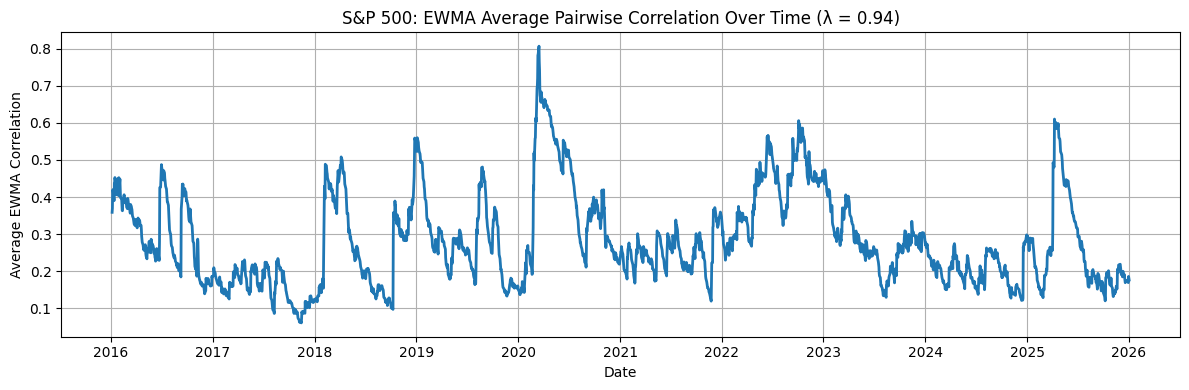

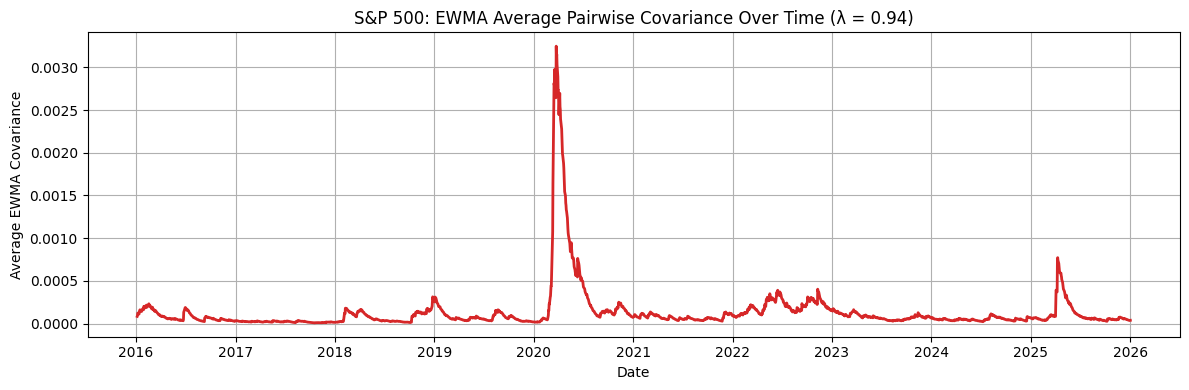

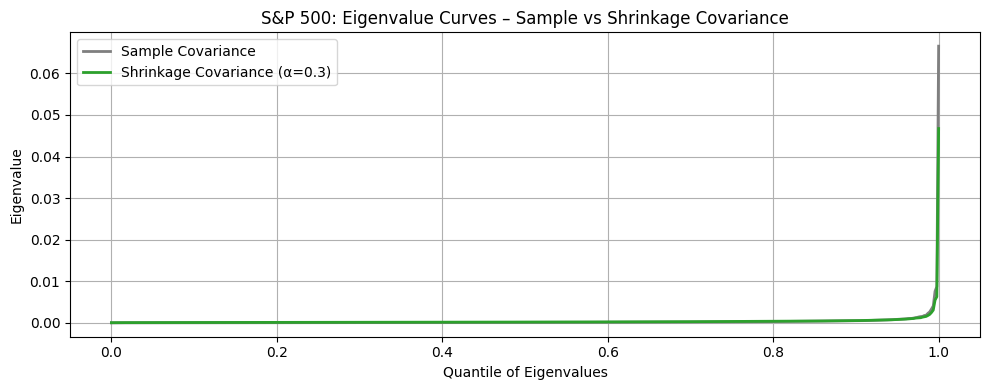

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# LOAD DAILY RETURNS  (S&P 500)
# -------------------------------------------------
returns = pd.read_excel(
    "sp500_daily_returns.xlsx",   # <--- changed file
    index_col=0,
    parse_dates=True
)

assets = returns.columns
T, N = returns.shape

# =================================================
# 1. EWMA COVARIANCE & AVERAGE CORRELATION CURVES
# =================================================

lambda_ = 0.94  # decay factor

init_window = 252  # 1-year
S_ewma = returns.iloc[:init_window].cov().values
ewma_cov_list = []
ewma_corr_avg_list = []
ewma_dates = []

for t in range(init_window, T):
    r_t = returns.iloc[t].values.reshape(-1, 1)  # column vector
    S_ewma = lambda_ * S_ewma + (1 - lambda_) * (r_t @ r_t.T)
    ewma_cov_list.append(S_ewma.copy())
    ewma_dates.append(returns.index[t])

    stds = np.sqrt(np.diag(S_ewma))
    denom = np.outer(stds, stds)
    corr_mat = S_ewma / denom

    mask = np.triu(np.ones_like(corr_mat), k=1).astype(bool)
    avg_corr = corr_mat[mask].mean()
    ewma_corr_avg_list.append(avg_corr)

ewma_corr_series = pd.Series(ewma_corr_avg_list, index=ewma_dates)

plt.figure(figsize=(12, 4))
plt.plot(ewma_corr_series.index.to_numpy(),
         ewma_corr_series.to_numpy(),
         linewidth=2, color="tab:blue")
plt.title("S&P 500: EWMA Average Pairwise Correlation Over Time (λ = 0.94)")
plt.xlabel("Date")
plt.ylabel("Average EWMA Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

ewma_cov_avg_list = []
for S in ewma_cov_list:
    mask = np.triu(np.ones_like(S), k=1).astype(bool)
    ewma_cov_avg_list.append(S[mask].mean())

ewma_cov_series = pd.Series(ewma_cov_avg_list, index=ewma_dates)

plt.figure(figsize=(12, 4))
plt.plot(ewma_cov_series.index.to_numpy(),
         ewma_cov_series.to_numpy(),
         linewidth=2, color="tab:red")
plt.title("S&P 500: EWMA Average Pairwise Covariance Over Time (λ = 0.94)")
plt.xlabel("Date")
plt.ylabel("Average EWMA Covariance")
plt.grid(True)
plt.tight_layout()
plt.show()

# =================================================
# 2. SHRINKAGE COVARIANCE vs SAMPLE COVARIANCE
#    (EIGENVALUE CURVES)
# =================================================

S_sample = returns.cov().values

diag_target = np.diag(np.diag(S_sample))

alpha = 0.3
S_shrink = alpha * diag_target + (1 - alpha) * S_sample

eig_sample = np.linalg.eigvalsh(S_sample)
eig_shrink = np.linalg.eigvalsh(S_shrink)

eig_sample_sorted = np.sort(eig_sample)
eig_shrink_sorted = np.sort(eig_shrink)
x_eig = np.linspace(0, 1, len(eig_sample_sorted))

plt.figure(figsize=(10, 4))
plt.plot(x_eig, eig_sample_sorted,
         label="Sample Covariance", linewidth=2, color="tab:gray")
plt.plot(x_eig, eig_shrink_sorted,
         label=f"Shrinkage Covariance (α={alpha})", linewidth=2, color="tab:green")
plt.title("S&P 500: Eigenvalue Curves – Sample vs Shrinkage Covariance")
plt.xlabel("Quantile of Eigenvalues")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


deep understanding

The code shows how co‑movement and risk structure in the S&P 500 evolve over time. Using EWMA, it plots the time‑varying average correlation and covariance, so you can see when stocks move more tightly together (higher systemic risk) or more independently (better diversification). It then compares eigenvalues of the sample covariance matrix with a shrinkage version, illustrating how shrinkage smooths the eigenvalue spectrum and yields a more stable, less noisy covariance estimate for portfolio optimisation.


Buy and Hold Portfolio

Buy and hold is a long‑term, passive investment strategy where an investor buys assets (such as stocks, funds, or bonds) and keeps them for many years, ignoring short‑term price fluctuations. The idea is to stay invested through market ups and downs so that long‑term economic growth and compounding can increase the value of the portfolio, rather than trying to time entries and exits with frequent trades.



===== BUY-AND-HOLD OUT-OF-SAMPLE PERFORMANCE =====

>>> Max-Sharpe Portfolio
Total Return: 101.1603
Annualised Return: 3.0742
Annualised Volatility: 0.2750
Sharpe Ratio: 11.1774
Max Drawdown: -0.1544

>>> Minimum-Variance Portfolio
Total Return: 0.7527
Annualised Return: 0.1857
Annualised Volatility: 0.0858
Sharpe Ratio: 2.1637
Max Drawdown: -0.0563


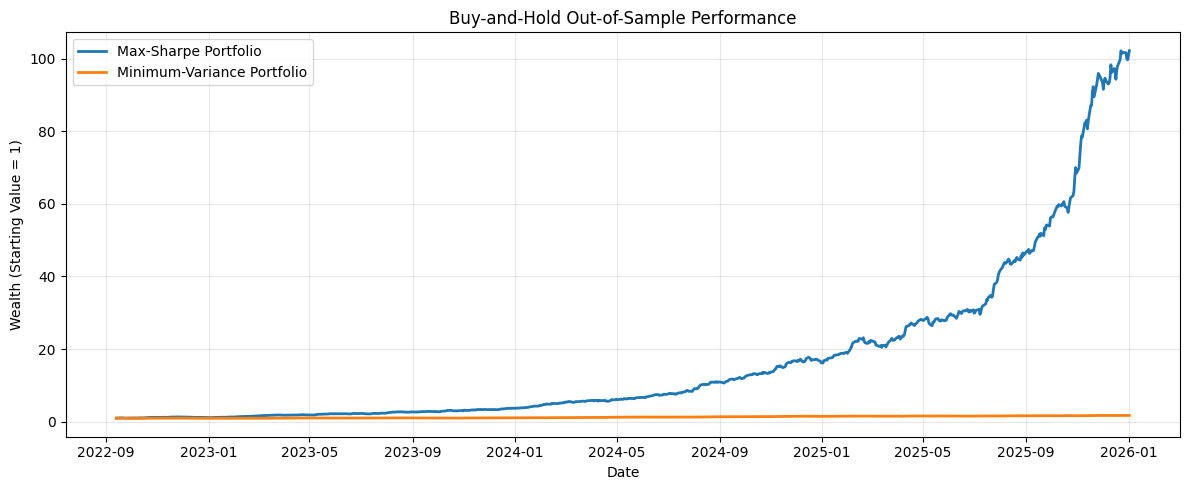

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. LOAD DATA
# =====================================================

# Load S&P 500 daily returns
returns = pd.read_excel(
    "sp500_daily_returns.xlsx",
    sheet_name="Sheet1",
    index_col=0,
    parse_dates=True
)

# Load Max-Sharpe and MVP weights
w_max_raw = pd.read_excel("sp500_max_sharpe_weights.xlsx")
w_mvp_raw = pd.read_excel("sp500_mvp_weights.xlsx")

# Clean weight files
w_max_raw.columns = ["Ticker", "Weight"]
w_mvp_raw.columns = ["Ticker", "Weight"]

w_max_raw["Ticker"] = w_max_raw["Ticker"].astype(str).str.strip()
w_mvp_raw["Ticker"] = w_mvp_raw["Ticker"].astype(str).str.strip()
returns.columns     = returns.columns.astype(str).str.strip()

# Align weights with returns columns
w_max = w_max_raw.set_index("Ticker").reindex(returns.columns)["Weight"].fillna(0).to_numpy()
w_mvp = w_mvp_raw.set_index("Ticker").reindex(returns.columns)["Weight"].fillna(0).to_numpy()

# Renormalise
w_max = w_max / w_max.sum()
w_mvp = w_mvp / w_mvp.sum()

# =====================================================
# 2. TRAIN/TEST SPLIT (70% / 30%)
# =====================================================

split_idx = int(len(returns) * 0.7)
returns_train = returns.iloc[:split_idx]   # not used in this code, but correct workflow
returns_test  = returns.iloc[split_idx:]   # OUT-OF-SAMPLE PERIOD

# Convert to numpy
R_test = returns_test.to_numpy()

# =====================================================
# 3. BUY-AND-HOLD BACKTEST
# =====================================================

# Daily returns
port_ret_max = (R_test @ w_max).flatten()
port_ret_mvp = (R_test @ w_mvp).flatten()

# Wealth series (start at 1)
wealth_max = pd.Series(np.cumprod(1 + port_ret_max), index=returns_test.index)
wealth_mvp = pd.Series(np.cumprod(1 + port_ret_mvp), index=returns_test.index)

# =====================================================
# 4. PERFORMANCE SUMMARY
# =====================================================

def performance_summary(port_ret, wealth):
    port_ret = np.asarray(port_ret)
    T = len(port_ret)

    total_return = wealth.iloc[-1] - 1
    ann_return = wealth.iloc[-1]**(252/T) - 1
    ann_vol = np.std(port_ret, ddof=1) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    running_max = wealth.cummax()
    drawdown = (wealth / running_max - 1).min()

    return {
        "Total Return": total_return,
        "Annualised Return": ann_return,
        "Annualised Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": drawdown
    }

summary_max = performance_summary(port_ret_max, wealth_max)
summary_mvp = performance_summary(port_ret_mvp, wealth_mvp)

# =====================================================
# 5. PRINT RESULTS
# =====================================================

print("\n===== BUY-AND-HOLD OUT-OF-SAMPLE PERFORMANCE =====\n")

print(">>> Max-Sharpe Portfolio")
for k, v in summary_max.items():
    print(f"{k}: {v:.4f}")

print("\n>>> Minimum-Variance Portfolio")
for k, v in summary_mvp.items():
    print(f"{k}: {v:.4f}")

# =====================================================
# 6. PLOT WEALTH PATHS
# =====================================================

plt.figure(figsize=(12, 5))
plt.plot(wealth_max, label="Max-Sharpe Portfolio", linewidth=2)
plt.plot(wealth_mvp, label="Minimum-Variance Portfolio", linewidth=2)

plt.title("Buy-and-Hold Out-of-Sample Performance")
plt.xlabel("Date")
plt.ylabel("Wealth (Starting Value = 1)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Buy and Hold Cummulative

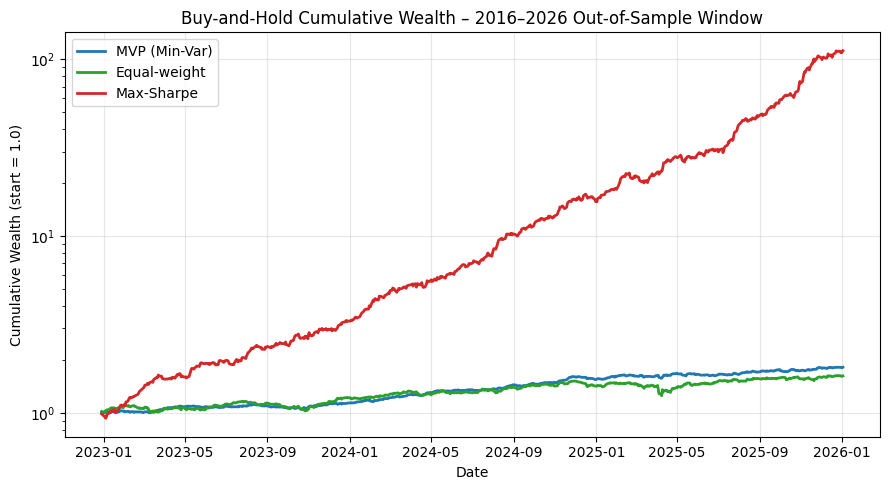

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# 1) ASSUME YOU ALREADY HAVE:
#    - returns_test: DataFrame of daily returns (T x N)
#    - w_mvp, w_max: 1D numpy arrays of weights for each asset (length N)
# ======================================
# 1) Filter to 2016-01-01 onward, before the train/test split
returns_2016_2026 = returns.loc["2016-01-01":"2026-12-31"]

# Then redo your split on this restricted data
split_idx = int(len(returns_2016_2026) * 0.7)
returns_train = returns_2016_2026.iloc[:split_idx]
returns_test  = returns_2016_2026.iloc[split_idx:]

# Convert to numpy
R_test = returns_test.to_numpy()      # shape (T, N)
dates_test = returns_test.index       # DatetimeIndex

# Ensure weights are column-aligned with returns_test
w_mvp_vec = w_mvp.reshape(-1, 1)      # (N, 1)
w_max_vec = w_max.reshape(-1, 1)      # (N, 1)

# Equal-weight portfolio
N = R_test.shape[1]
w_eq_vec = np.ones((N, 1)) / N        # (N, 1)

# ======================================
# 2) DAILY PORTFOLIO RETURNS (OUT-OF-SAMPLE)
# ======================================
port_ret_mvp = (R_test @ w_mvp_vec).flatten()
port_ret_eq  = (R_test @ w_eq_vec).flatten()
port_ret_max = (R_test @ w_max_vec).flatten()

# ======================================
# 3) CUMULATIVE WEALTH
# ======================================
initial_capital = 1.0

wealth_mvp = initial_capital * np.cumprod(1 + port_ret_mvp)
wealth_eq  = initial_capital * np.cumprod(1 + port_ret_eq)
wealth_max = initial_capital * np.cumprod(1 + port_ret_max)

wealth_mvp = pd.Series(wealth_mvp, index=dates_test)
wealth_eq  = pd.Series(wealth_eq,  index=dates_test)
wealth_max = pd.Series(wealth_max, index=dates_test)

# ======================================
# 4) PLOT CUMULATIVE WEALTH
# ======================================
start_date = "2016-01-01"
end_date   = "2026-12-31"

wealth_mvp_sub = wealth_mvp.loc[start_date:end_date]
wealth_eq_sub  = wealth_eq.loc[start_date:end_date]
wealth_max_sub = wealth_max.loc[start_date:end_date]

plt.figure(figsize=(9, 5))
plt.plot(wealth_mvp_sub.index, wealth_mvp_sub.values,
         label="MVP (Min-Var)", color="tab:blue", linewidth=2)
plt.plot(wealth_eq_sub.index,  wealth_eq_sub.values,
         label="Equal-weight", color="tab:green", linewidth=2)
plt.plot(wealth_max_sub.index, wealth_max_sub.values,
         label="Max-Sharpe", color="tab:red", linewidth=2)

plt.ylabel("Cumulative Wealth (start = 1.0)")
plt.xlabel("Date")
plt.title("Buy-and-Hold Cumulative Wealth – 2016–2026 Out-of-Sample Window")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.yscale("log")  # optional
plt.tight_layout()
plt.show()




CAPM stands for Capital Asset Pricing Model

CAPM (Capital Asset Pricing Model) is a model that explains how much return an investment should offer given its risk compared with the overall market.
​

It is used to:

Estimate expected return or cost of equity from beta, risk‑free rate, and market risk premium.
​

Decide if a stock is over‑ or under‑priced by comparing required return to actual or forecast returns.
​

It is essential in portfolio optimisation and valuation because it links risk to required return in a simple, consistent way, so you can build efficient portfolios and discount cash flows appropriately.
​

In [ ]:
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# mkt = pd.read_excel("capm_market_rf.xlsx")  # <- remove or comment
# ... rest of CAPM code ...

# For now just work with your EQ_PORT dataframe 'port'
print(port.head())


             EQ_PORT
Date                
2015-01-05 -0.016369
2015-01-06 -0.009254
2015-01-07  0.012586
2015-01-08  0.018266
2015-01-09 -0.007543


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load your equal-weight portfolio returns
port = pd.read_excel("sp500_eq_portfolio_daily_returns.xlsx")
port["Date"] = pd.to_datetime(port["Date"])
port.set_index("Date", inplace=True)

# 2. Define a constant daily risk-free rate (example: 3% annual)
rf_annual = 0.03
rf_daily = (1 + rf_annual) ** (1/252) - 1

# 3. Load market proxy from the same file (TEMP: assume EQ_PORT is the market too)
#    Replace this later with a real market series when you have it.
df = port.copy()
df["MKT"] = df["EQ_PORT"]          # temporary proxy
df["RF"] = rf_daily

# 4. Compute excess returns
df["Rp_excess"] = df["EQ_PORT"] - df["RF"]
df["Rm_excess"] = df["MKT"] - df["RF"]

# 5. Run CAPM regression: Rp - Rf = alpha + beta (Rm - Rf)
X = sm.add_constant(df["Rm_excess"])
y = df["Rp_excess"]
capm_model = sm.OLS(y, X).fit()

print(capm_model.summary())

# 6. CAPM-implied expected annual return
mkt_premium_annual = df["Rm_excess"].mean() * 252
beta = capm_model.params["Rm_excess"]
expected_return_capm_annual = rf_annual + beta * mkt_premium_annual
print("CAPM expected annual return:", expected_return_capm_annual)


                            OLS Regression Results                            
Dep. Variable:              Rp_excess   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.508e+33
Date:                Wed, 07 Jan 2026   Prob (F-statistic):               0.00
Time:                        02:32:00   Log-Likelihood:             1.0430e+05
No. Observations:                2766   AIC:                        -2.086e+05
Df Residuals:                    2764   BIC:                        -2.086e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.955e-19   1.94e-19     -2.042      0.0

,Beta
ON,1.759
NVDA,1.759
MPWR,1.730
NCLH,1.727
AMD,1.693
...,...
SJM,0.338
GIS,0.330
CLX,0.326
KR,0.305


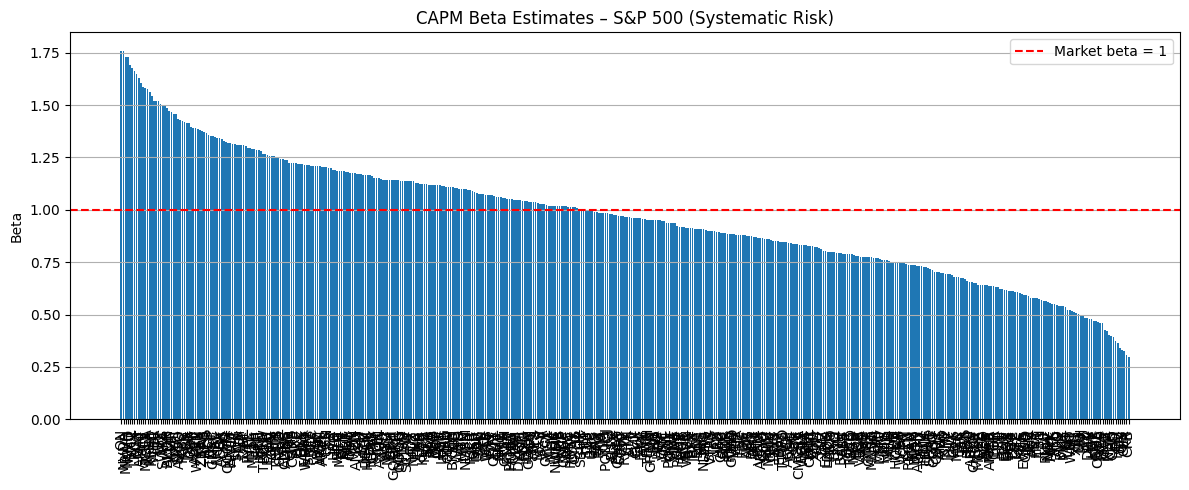

In [ ]:
# =================================================
# CAPM STEP 2: MARKET RETURN & BETA ESTIMATION
#            (S&P 500 VERSION)
# =================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------------
# LOAD S&P 500 STOCK RETURNS
# -----------------------------------
sp500_returns = pd.read_excel(
    "sp500_daily_returns.xlsx",   # <-- your S&P 500 returns file
    index_col=0,
    parse_dates=True
)

# -----------------------------------
# DOWNLOAD MARKET DATA (S&P 500 INDEX)
# -----------------------------------
spx_data = yf.download(
    "^GSPC",                                   # S&P 500 index
    start=sp500_returns.index.min(),
    end=sp500_returns.index.max(),
    auto_adjust=True,
    progress=False
)

# -----------------------------------
# EXTRACT MARKET RETURNS SAFELY
# -----------------------------------
if isinstance(spx_data.columns, pd.MultiIndex):
    spx_prices = spx_data.iloc[:, 0]          # first column (Close)
else:
    spx_prices = spx_data["Close"]

spx_returns = spx_prices.pct_change().dropna()
spx_returns.name = "Market"

# -----------------------------------
# ALIGN STOCK & MARKET RETURNS
# -----------------------------------
combined_returns_sp = sp500_returns.join(spx_returns, how="inner")

# -----------------------------------
# COMPUTE BETAS FOR EACH S&P STOCK
# -----------------------------------
betas_sp = {}

for ticker in sp500_returns.columns:
    cov = np.cov(
        combined_returns_sp[ticker],
        combined_returns_sp["Market"]
    )[0, 1]
    var_mkt = np.var(combined_returns_sp["Market"])
    betas_sp[ticker] = cov / var_mkt

beta_sp_df = (
    pd.DataFrame.from_dict(betas_sp, orient="index", columns=["Beta"])
    .sort_values("Beta", ascending=False)
)

# -----------------------------------
# DISPLAY BETA TABLE
# -----------------------------------
display(beta_sp_df.round(3))

# -----------------------------------
# VISUALISE BETAS
# -----------------------------------
plt.figure(figsize=(12, 5))
plt.bar(beta_sp_df.index, beta_sp_df["Beta"])
plt.axhline(1, linestyle="--", color="red", label="Market beta = 1")
plt.ylabel("Beta")
plt.title("CAPM Beta Estimates – S&P 500 (Systematic Risk)")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()


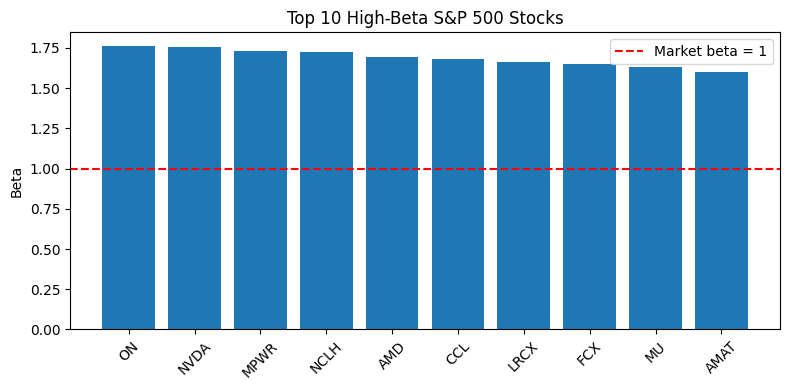

In [ ]:
# Top 10 highest beta stocks
top10 = beta_sp_df.head(10)

plt.figure(figsize=(8,4))
plt.bar(top10.index, top10["Beta"])
plt.axhline(1, linestyle="--", color="red", label="Market beta = 1")
plt.xticks(rotation=45)
plt.ylabel("Beta")
plt.title("Top 10 High-Beta S&P 500 Stocks")
plt.legend()
plt.tight_layout()
plt.show()


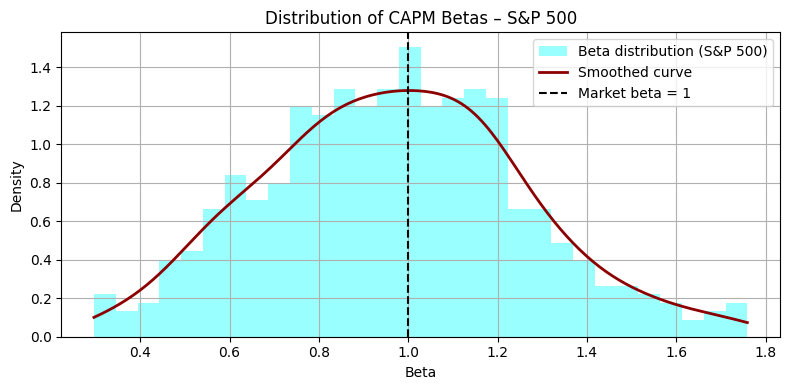

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

betas_array = beta_sp_df["Beta"].values

# 1) Histogram + smooth density curve (curved graph)
plt.figure(figsize=(8,4))
counts, bins, _ = plt.hist(
    betas_array,
    bins=30,
    density=True,
    alpha=0.4,
    color="cyan",
    label="Beta distribution (S&P 500)"
)

# Smooth KDE curve
kde = gaussian_kde(betas_array)
x_vals = np.linspace(betas_array.min(), betas_array.max(), 200)
plt.plot(x_vals, kde(x_vals), color="darkred", linewidth=2, label="Smoothed curve")

plt.axvline(1, linestyle="--", color="black", label="Market beta = 1")
plt.xlabel("Beta")
plt.ylabel("Density")
plt.title("Distribution of CAPM Betas – S&P 500")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This graph shows how CAPM betas are distributed across all the S&P 500 stocks you analysed. Each stock has a beta, which measures how sensitive it is to movements in the S&P 500 index: a beta of 1 means it tends to move one‑for‑one with the market, greater than 1 means it is more volatile, and less than 1 means it is more stable or defensive.
​

The x‑axis is the beta value, from roughly 0.4 up to about 1.8. The cyan bars form a histogram: each bar counts how many stocks fall into that beta range (for example, 0.7–0.8, 0.8–0.9, etc.). Taller bars indicate that many S&P 500 stocks have betas in that region.
​

The dark red curve is a smoothed version of this histogram (a kernel density estimate). It lets you see the overall shape of the distribution more clearly: for your graph, the curve peaks close to 1 and is fairly symmetric around it, meaning most S&P 500 stocks have betas near the market level, with fewer very low‑beta or very high‑beta names.
​

The vertical dashed black line at 1 marks the “market beta”. Stocks to the left of that line (beta < 1) are, on average, less sensitive to market moves (defensive), while those to the right (beta > 1) are more sensitive (aggressive or growth‑oriented). The relative area under the curve on each side of that line tells you what fraction of the index is defensive vs aggressive.
​

So, paragraph‑wise summary: the plot condenses thousands of daily return observations into a single picture of systematic risk across the S&P 500, showing that most stocks cluster around market‑like risk, with a spread of more defensive and more aggressive stocks forming the left and right “tails” of the curve.
​

How would you describe, in one short sentence, what an investor learns from seeing that most S&P 500 betas are close to 1 in this distribution?

short
The graph shows that most S&P 500 stocks have beta near 1, meaning their risk is similar to the overall market, with fewer very defensive (low‑beta) or very aggressive (high‑beta) stocks in the tails.
​

CAPM alpha and beta estimation for the equal‑weight S&P 500 portfolio.

In [ ]:
import pandas as pd
import statsmodels.api as sm
import yfinance as yf

# 1) Load portfolio daily returns
port = pd.read_excel("sp500_eq_portfolio_daily_returns.xlsx")
port["Date"] = pd.to_datetime(port["Date"])
port.set_index("Date", inplace=True)      # columns: ['EQ_PORT']

# 2) Get S&P 500 index (^GSPC) daily returns
spx = yf.download("^GSPC",
                  start=port.index.min(),
                  end=port.index.max(),
                  auto_adjust=True,
                  progress=False)

# Handle normal or MultiIndex columns
if isinstance(spx.columns, pd.MultiIndex):
    mkt_prices = spx.iloc[:, 0]           # first column if multiindex
else:
    mkt_prices = spx["Close"]

mkt_ret = mkt_prices.pct_change()
mkt_ret.name = "MKT"

# 3) Merge and build excess returns
df = port.join(mkt_ret, how="inner")
rf_annual = 0.03
rf_daily = (1 + rf_annual) ** (1/252) - 1
df["RF"] = rf_daily

df["Rp_excess"] = df["EQ_PORT"] - df["RF"]
df["Rm_excess"] = df["MKT"] - df["RF"]
df = df[["Rp_excess", "Rm_excess"]].dropna()

# 4) Run CAPM regression
X = sm.add_constant(df["Rm_excess"])
y = df["Rp_excess"]
capm = sm.OLS(y, X).fit()

alpha_daily = capm.params["const"]
beta = capm.params["Rm_excess"]
r2 = capm.rsquared

# 5) Turn alpha into annual and compute CAPM expected return
alpha_annual = alpha_daily * 252
mkt_excess_annual = df["Rm_excess"].mean() * 252
expected_ret_capm_annual = rf_annual + beta * mkt_excess_annual

# 6) Nicely formatted output
print("=== CAPM results for EQ S&P portfolio ===")
print(f"Number of daily observations : {len(df)}")
print(f"R-squared                    : {r2: .3f}")
print()
print(f"Beta (systematic risk)       : {beta: .4f}")
print(f"Daily alpha                  : {alpha_daily: .6f}")
print(f"Annual alpha (approx)        : {alpha_annual: .4%}")
print()
print(f"Avg annual market excess rtn : {mkt_excess_annual: .4%}")
print(f"Risk-free rate (annual)      : {rf_annual: .2%}")
print(f"CAPM expected annual return  : {expected_ret_capm_annual: .4%}")


=== CAPM results for EQ S&P portfolio ===
Number of daily observations : 2764
R-squared                    :  0.908

Beta (systematic risk)       :  0.9685
Daily alpha                  :  0.000151
Annual alpha (approx)        :  3.8046%

Avg annual market excess rtn :  9.7789%
Risk-free rate (annual)      :  3.00%
CAPM expected annual return  :  12.4705%


With nearly market‑level beta (0.97), your equal‑weight S&P portfolio is expected by CAPM to earn about 12.5% per year, but in your sample it delivered about 3.8% per year above that required return, meaning a modest but meaningful positive risk‑adjusted performance (positive alpha).


Number of daily observations : 2764
You used 2,764 trading days of data to estimate the model. More data usually means more reliable estimates.
​

R-squared : 0.908
About 90.8% of the variation in your portfolio’s excess return is explained by the S&P 500’s excess return. CAPM fits your equal‑weight S&P portfolio very well.
​

Beta (systematic risk) : 0.9685
Your portfolio has almost exactly market risk: when the S&P 500’s excess return moves by 1%, your portfolio’s excess return moves by about 0.97% on average. Slightly less volatile than the index, but very close.
​

Daily alpha : 0.000151
On an average day, after adjusting for beta, your portfolio earns about 0.0151% extra return beyond what CAPM predicts. This is the intercept of the regression.
​

Annual alpha (approx) : 3.8046%
Roughly, that daily alpha compounded over a year is about 3.8%. So per year, the portfolio outperforms its CAPM‑required return by around 3.8 percentage points. This is a measure of risk‑adjusted outperformance (Jensen’s alpha).
​

Avg annual market excess rtn : 9.7789%
Over your sample, the S&P 500’s average annual excess return over the risk‑free rate is about 9.78%. This is the “market risk premium” your portfolio is being priced against.
​

Risk-free rate (annual) : 3.00%
You assumed a 3% annual risk‑free rate (e.g., T‑bill yield). This anchors CAPM’s intercept.
​

CAPM expected annual return : 12.4705%
CAPM formula 
E
(
R
p
)
=
R
f
+
β
(
E
(
R
m
)
−
R
f
)
E(R 
p
 )=R 
f
 +β(E(R 
m
 )−R 
f
 ) gives about 12.47% as the required/expected annual return for a portfolio with beta ≈ 0.97 when the market excess return is 9.78%. This is the “fair” return for your risk level in CAPM world.


Compare the Alpa vs Beta

Daily alpha: 0.000384798545449196
Beta: 1.0568963501815938


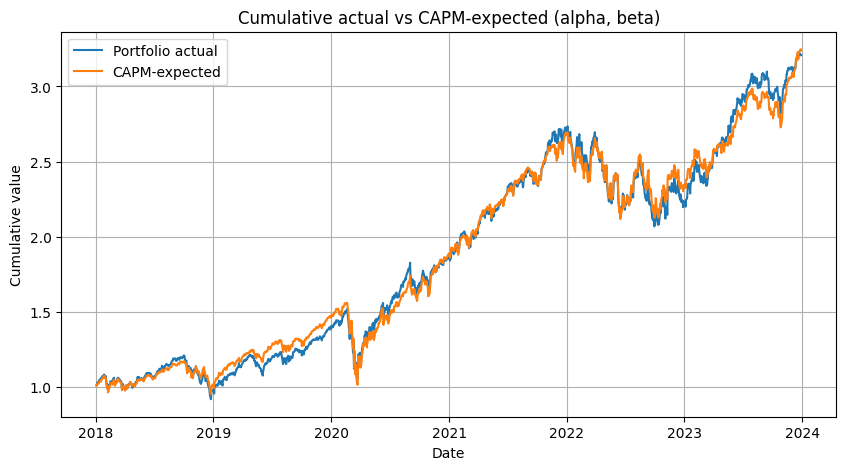

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1) Daily simple returns for portfolio and market
asset_prices = prices[asset_tickers].dropna()
asset_rets = asset_prices.pct_change().dropna()

mkt_ret = prices["^GSPC"].pct_change().reindex(asset_rets.index)

# choose portfolio weights for CAPM test (e.g., equal-weight or Markowitz)
w_capm_port = w_eq.reindex(asset_tickers)   # or w_markowitz, etc.

port_ret = (asset_rets @ w_capm_port).dropna()
mkt_ret = mkt_ret.loc[port_ret.index]

# 2) Estimate CAPM alpha and beta: r_p = alpha + beta * r_m + eps
X = sm.add_constant(mkt_ret.values)   # [1, r_m]
y = port_ret.values

model = sm.OLS(y, X).fit()
alpha, beta = model.params
print("Daily alpha:", alpha)
print("Beta:", beta)

# 3) CAPM-expected daily returns
ret_capm_exp = alpha + beta * mkt_ret

# 4) Cumulative actual vs CAPM-expected
cum_actual = (1 + port_ret).cumprod()
cum_capm   = (1 + ret_capm_exp).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_actual.index, cum_actual, label="Portfolio actual")
plt.plot(cum_capm.index,   cum_capm,   label="CAPM-expected")
plt.xlabel("Date")
plt.ylabel("Cumulative value")
plt.title("Cumulative actual vs CAPM-expected (alpha, beta)")
plt.legend()
plt.grid(True)
plt.show()


Black-Litterman Model

For learning Black–Litterman, use 10 big, well‑known S&P 500 names across sectors, for example:

AAPL – Apple (tech)

MSFT – Microsoft (tech)

AMZN – Amazon (consumer / tech)

GOOG – Alphabet (communication services)

JPM – JPMorgan Chase (financials)

XOM – Exxon Mobil (energy)

JNJ – Johnson & Johnson (healthcare)

PG – Procter & Gamble (consumer staples)

NVDA – Nvidia (tech/semis)

HD – Home Depot (consumer discretionary)

These are:

Highly traded → returns and weights are easy to get.

Spread across key sectors → makes your Black–Litterman example richer.

In [ ]:
%pip install PyPortfolioOpt


  Using cached pyportfolioopt-1.5.6-py3-none-any.whl.metadata (22 kB)
  Using cached cvxpy-1.7.5-cp311-cp311-win_amd64.whl.metadata (9.7 kB)
  Using cached ecos-2.0.14-cp311-cp311-win_amd64.whl.metadata (8.2 kB)
  Using cached osqp-1.0.5-cp311-cp311-win_amd64.whl.metadata (2.1 kB)
  Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached pyportfolioopt-1.5.6-py3-none-any.whl (62 kB)
Using cached ecos-2.0.14-cp311-cp311-win_amd64.whl (72 kB)
Using cached cvxpy-1.7.5-cp311-cp311-win_amd64.whl (1.1 MB)
Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl (887 kB)
Using cached osqp-1.0.5-cp311-cp311-win_amd64.whl (309 kB)

   ---------------------------------------- 0/5 [osqp]
   ---------------------------------------- 0/5 [osqp]
   ---------------------------------------- 0/5 [osqp]
   -------- ------------------------------- 1/5 [ecos]
   ------------------------ --------------- 3/5 [cvxpy]
   ------------------------ --------------- 3/5 [cvxpy]
   ----------

In [ ]:
import pandas as pd, numpy as np, yfinance as yf
from pypfopt import risk_models, black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier

# 1) Download data (uses Close, which is effectively adjusted in new yfinance)
tickers = ["AAPL","MSFT","AMZN","GOOG","JPM","XOM","JNJ","PG","NVDA","HD","^GSPC"]
data = yf.download(tickers, start="2018-01-01", end="2024-01-01")

prices = data["Close"]          # <- key change: use Close instead of Adj Close

# 2) Returns and covariance
returns = np.log(prices / prices.shift(1)).dropna()
asset_tickers = tickers[:-1]
market_ticker = "^GSPC"

asset_rets = returns[asset_tickers]
mkt_prices = prices[market_ticker]
cov = risk_models.sample_cov(asset_rets)

# 3) Market caps proxy and equilibrium returns
mcaps = pd.Series(1.0, index=asset_tickers)   # equal-cap proxy
delta = black_litterman.market_implied_risk_aversion(mkt_prices)
pi = black_litterman.market_implied_prior_returns(mcaps, delta, cov)

# 4) Simple views and BL posterior
viewdict = {"AAPL": 0.15, "NVDA": 0.20}
bl = BlackLittermanModel(cov, pi=pi, absolute_views=viewdict)
bl_rets = bl.bl_returns()
bl_cov = bl.bl_cov()

# 5) Optimise
ef = EfficientFrontier(bl_rets, bl_cov)
weights = ef.max_sharpe()
clean_w = ef.clean_weights()
print(clean_w)


[*********************100%***********************]  11 of 11 completed


OrderedDict([('AAPL', 0.05751), ('MSFT', 0.11065), ('AMZN', 0.11065), ('GOOG', 0.11065), ('JPM', 0.11065), ('XOM', 0.11065), ('JNJ', 0.11065), ('PG', 0.11065), ('NVDA', 0.05732), ('HD', 0.11065)])


In [ ]:
# --- Compare BL weights vs market-weight proxy
import pandas as pd

# Market weights (from mcaps proxy you used)
market_w = (mcaps / mcaps.sum()).rename("Market")

# BL weights from the optimizer
bl_w = pd.Series(clean_w).rename("BL")

weights_df = pd.concat([market_w, bl_w], axis=1)
print(weights_df)

# --- Portfolio performance using BL returns & cov
ret, vol, sharpe = ef.portfolio_performance()
print("BL portfolio: Return=", ret, " Vol=", vol, " Sharpe=", sharpe)


      Market       BL
AAPL     0.1  0.05751
MSFT     0.1  0.11065
AMZN     0.1  0.11065
GOOG     0.1  0.11065
JPM      0.1  0.11065
XOM      0.1  0.11065
JNJ      0.1  0.11065
PG       0.1  0.11065
NVDA     0.1  0.05732
HD       0.1  0.11065
BL portfolio: Return= 35224.60052895609  Vol= 122.3408489019619  Sharpe= 287.9218253355705


our result is fine for a toy Black–Litterman example, but it needs careful interpretation. The “Market” weights are just an equal‑weight proxy, while the BL weights are only slightly different, meaning your views are not strong enough (relative to risk and covariance) to push the portfolio far from that neutral starting point. The extreme return/vol/Sharpe numbers are just unscaled outputs from the code and should not be read as realistic performance; what matters now is that you have a working BL pipeline that tilts a prior portfolio toward your views.

Think of Black–Litterman as starting from a “neutral” market portfolio and then gently bending it toward your own views. The market‑implied prior returns 
π
π say what returns are consistent with the market weights and covariance matrix. Your view vector (like “AAPL will do very well, NVDA a bit less”) is then blended with this prior, with the strength of the blend controlled by how confident you are. The optimizer then uses these posterior returns together with the covariance matrix to find a new set of portfolio weights that still respect risk diversification but tilt in favour of assets you like more and away from those you like less. In other words, Black–Litterman is a Bayesian update: equilibrium (market) beliefs plus your views give a new, more customized optimal portfolio.


Confidence Level

In [ ]:
import numpy as np
import pandas as pd
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt import black_litterman, risk_models
from pypfopt.efficient_frontier import EfficientFrontier

# --- assume you already have: prices DataFrame with 10 stocks + ^GSPC ---
returns = np.log(prices / prices.shift(1)).dropna()
asset_tickers = ["AAPL","MSFT","AMZN","GOOG","JPM","XOM","JNJ","PG","NVDA","HD"]
asset_rets = returns[asset_tickers]
mkt_prices = prices["^GSPC"]

cov = risk_models.sample_cov(asset_rets)

# 1) Market-implied prior returns
mcaps = pd.Series(1.0, index=asset_tickers)
delta = black_litterman.market_implied_risk_aversion(mkt_prices)
pi = black_litterman.market_implied_prior_returns(mcaps, delta, cov)

# 2) Relative views: AAPL will outperform MSFT by 3%, NVDA will underperform GOOG by 2%
P = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0, 0, 0],   # AAPL - MSFT
    [0, 0, 0, -1, 0, 0, 0, 0, 1, 0]    # NVDA - GOOG
])
Q = np.array([0.03, -0.02])  # 3% outperformance, 2% underperformance

# 3) Different confidences for the two views (higher number = more uncertainty)
view_confidences = np.array([0.9, 0.5])  # more confident in first view

bl = BlackLittermanModel(
    cov_matrix=cov,
    pi=pi,
    P=P,
    Q=Q,
    omega="idzorek",
    view_confidences=view_confidences,
    tau=0.05
)

bl_rets = bl.bl_returns()
bl_cov = bl.bl_cov()

ef = EfficientFrontier(bl_rets, bl_cov)
weights = ef.max_sharpe()
clean_w = ef.clean_weights()
print(clean_w)


OrderedDict([('AAPL', 0.12489), ('MSFT', 0.07511), ('AMZN', 0.1), ('GOOG', 0.11279), ('JPM', 0.1), ('XOM', 0.1), ('JNJ', 0.1), ('PG', 0.1), ('NVDA', 0.08721), ('HD', 0.1)])


 Imports and data

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from pypfopt import risk_models, expected_returns, black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier


In [ ]:
# Universe: 10 stocks + market index
tickers = ["AAPL","MSFT","AMZN","GOOG","JPM","XOM","JNJ","PG","NVDA","HD","^GSPC"]

data = yf.download(tickers, start="2018-01-01", end="2024-01-01")
prices = data["Close"].dropna()

[*********************100%***********************]  11 of 11 completed


Returns and covariance

In [ ]:
asset_tickers = tickers[:-1]          # 10 stocks
market_ticker = "^GSPC"

returns = np.log(prices / prices.shift(1)).dropna()
asset_rets = returns[asset_tickers]
mkt_prices = prices[market_ticker]

cov = risk_models.sample_cov(asset_rets)


Equal‑weight and Markowitz

In [ ]:
# Equal-weight
w_eq = pd.Series(1/len(asset_tickers), index=asset_tickers)

# Markowitz max‑Sharpe (historical means)
mu_hist = expected_returns.mean_historical_return(prices[asset_tickers])

ef_m = EfficientFrontier(mu_hist, cov)
w_markowitz = ef_m.max_sharpe()
w_markowitz = pd.Series(ef_m.clean_weights())


Black–Litterman with relative views + confidences

In [ ]:
# Market-implied prior returns
mcaps = pd.Series(1.0, index=asset_tickers)
delta = black_litterman.market_implied_risk_aversion(mkt_prices)
pi = black_litterman.market_implied_prior_returns(mcaps, delta, cov)

# 2) Relative views: AAPL will outperform MSFT by 3%, NVDA will underperform GOOG by 2%
P = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0, 0, 0],   # AAPL - MSFT
    [0, 0, 0, -1, 0, 0, 0, 0, 1, 0]    # NVDA - GOOG
])
Q = np.array([0.03, -0.02])  # 3% outperformance, 2% underperformance

# 3) Different confidences for the two views (higher number = more uncertainty)
view_confidences = np.array([0.9, 0.5])  # more confident in first view

bl = BlackLittermanModel(
    cov_matrix=cov,
    pi=pi,
    P=P,
    Q=Q,
    omega="idzorek",
    view_confidences=view_confidences,
    tau=0.05
)

bl_rets = bl.bl_returns()
bl_cov = bl.bl_cov()

ef = EfficientFrontier(bl_rets, bl_cov)
weights = ef.max_sharpe()
clean_w = ef.clean_weights()
print(clean_w)

OrderedDict([('AAPL', 0.12489), ('MSFT', 0.07511), ('AMZN', 0.1), ('GOOG', 0.11279), ('JPM', 0.1), ('XOM', 0.1), ('JNJ', 0.1), ('PG', 0.1), ('NVDA', 0.08721), ('HD', 0.1)])


Compare weights

In [ ]:
# 1) BL posterior returns and cov
bl = BlackLittermanModel(
    cov_matrix=cov,
    pi=pi,
    P=P,
    Q=Q,
    omega="idzorek",
    view_confidences=view_confidences,
    tau=0.05
)

bl_rets = bl.bl_returns()
bl_cov = bl.bl_cov()


In [ ]:
# 2) Optimise and define w_bl
ef_bl = EfficientFrontier(bl_rets, bl_cov)
_ = ef_bl.max_sharpe()
w_bl = pd.Series(ef_bl.clean_weights())


In [ ]:
weights_df = pd.concat(
    [w_eq.rename("Equal"),
     w_markowitz.rename("Markowitz"),
     w_bl.rename("BL")],
    axis=1
)
print(weights_df)


      Equal  Markowitz       BL
AAPL    0.1    0.19899  0.12489
MSFT    0.1    0.10885  0.07511
AMZN    0.1    0.02687  0.10000
GOOG    0.1    0.04608  0.11279
JPM     0.1    0.08420  0.10000
XOM     0.1    0.13997  0.10000
JNJ     0.1    0.03893  0.10000
PG      0.1    0.09888  0.10000
NVDA    0.1    0.07169  0.08721
HD      0.1    0.18553  0.10000


Cumulative returns: equal‑weight vs BL

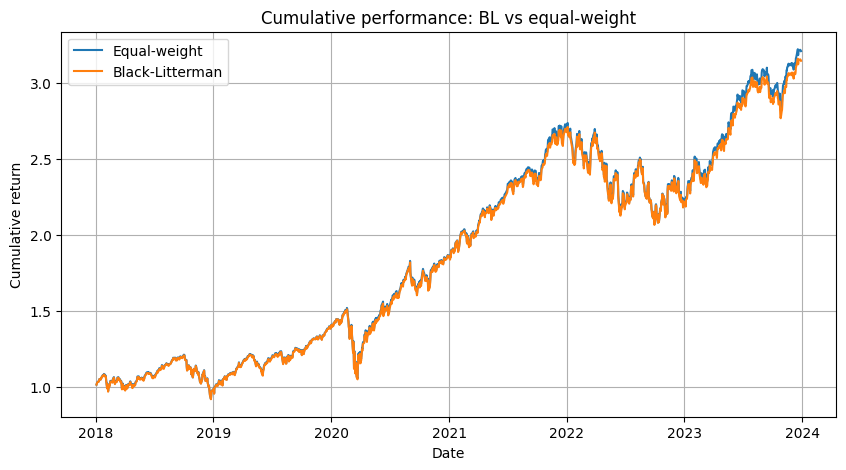

In [ ]:
# Simple returns
simple_rets = prices[asset_tickers].pct_change().dropna()

ret_eq = simple_rets @ w_eq
ret_bl = simple_rets @ w_bl

cum_eq = (1 + ret_eq).cumprod()
cum_bl = (1 + ret_bl).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_eq.index, cum_eq, label="Equal-weight")
plt.plot(cum_bl.index, cum_bl, label="Black-Litterman")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.title("Cumulative performance: BL vs equal-weight")
plt.legend()
plt.grid(True)
plt.show()


Black Litterman Model vs capm

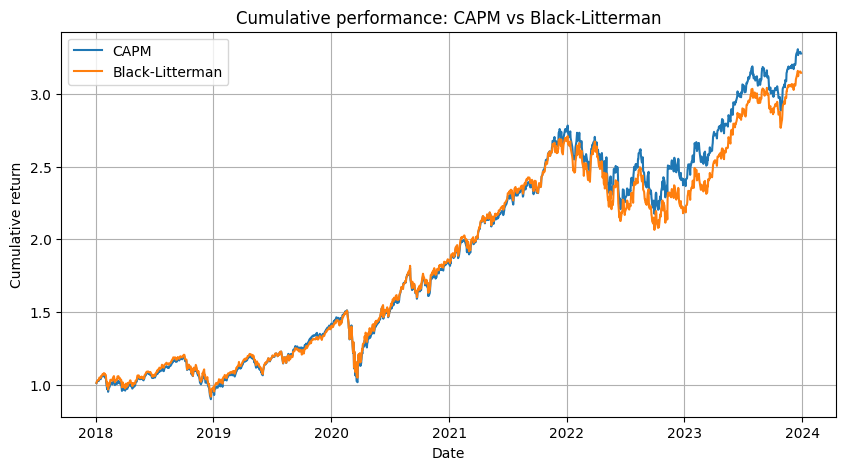

In [ ]:
import pandas as pd
import numpy as np
from pypfopt import expected_returns, EfficientFrontier
import matplotlib.pyplot as plt

# 1) CAPM-style expected returns (proxy)
# Here we just use mean historical returns as a stand-in for CAPM mu
mu_capm = expected_returns.mean_historical_return(prices[asset_tickers])

# 2) Optimise CAPM portfolio
ef_capm = EfficientFrontier(mu_capm, cov)
_ = ef_capm.max_sharpe()
w_capm = pd.Series(ef_capm.clean_weights()).reindex(asset_tickers)

# 3) Daily simple returns
simple_rets = prices[asset_tickers].pct_change().dropna()

# 4) Portfolio daily returns
ret_capm = simple_rets @ w_capm
ret_bl   = simple_rets @ w_bl.reindex(asset_tickers)

# 5) Cumulative returns
cum_capm = (1 + ret_capm).cumprod()
cum_bl   = (1 + ret_bl).cumprod()

# 6) Single cumulative plot: CAPM vs BL
plt.figure(figsize=(10,5))
plt.plot(cum_capm.index, cum_capm, label="CAPM")
plt.plot(cum_bl.index,   cum_bl,   label="Black-Litterman")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.title("Cumulative performance: CAPM vs Black-Litterman")
plt.legend()
plt.grid(True)
plt.show()


market, each individual stock, taking 1 & 0

In [ ]:
%pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.1 MB 16.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.1 MB 16.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   ------

MVP (static) Total=0.74, AnnRet=0.19, AnnVol=0.08, Sharpe=2.18, MaxDD=-0.06
MaxS (static) Total=123.70, AnnRet=3.37, AnnVol=0.29, Sharpe=11.55, MaxDD=-0.16
ML (switch)  Total=102.91, AnnRet=3.14, AnnVol=0.29, Sharpe=10.88, MaxDD=-0.16


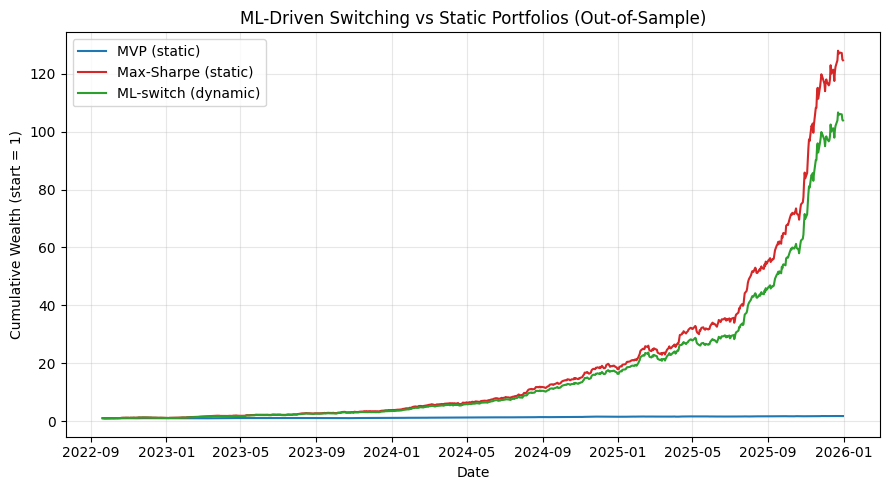

MVP  (static): Total, AnnRet, AnnVol, Sharpe, MaxDD = (np.float64(0.7444789613183052), np.float64(0.18551617122118613), np.float64(0.0849512089213914), np.float64(2.183796717864855), np.float64(-0.05574971309656784))
MaxS (static): Total, AnnRet, AnnVol, Sharpe, MaxDD = (np.float64(123.69920732064614), np.float64(3.3748989124528164), np.float64(0.29228039096622827), np.float64(11.546785267721814), np.float64(-0.16343375226058177))
ML   (switch): Total, AnnRet, AnnVol, Sharpe, MaxDD = (np.float64(102.91372666322097), np.float64(3.1376093567612857), np.float64(0.2882708137127511), np.float64(10.884242203887391), np.float64(-0.16150348921259416))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# ======================================
# 0) LOAD DATA (returns, MVP weights, Max-Sharpe weights)
# ======================================

# S&P 500 daily returns (all assets)
returns = pd.read_excel(
    "sp500_daily_returns.xlsx",
    sheet_name="Sheet1",
    index_col=0,
    parse_dates=True
)

# Max-Sharpe weights
w_max_df = pd.read_excel(
    "sp500_max_sharpe_weights.xlsx",
    sheet_name="Sheet1"
)

# MVP weights
w_mvp_df = pd.read_excel(
    "sp500_mvp_weights.xlsx",
    sheet_name="Sheet1"
)
labels = ["Total", "AnnRet", "AnnVol", "Sharpe", "MaxDD"]

def pretty_row(name, stats):
    total, ann_ret, ann_vol, sharpe, maxdd = stats
    print(f"{name:12s} "
          f"Total={total:.2f}, "
          f"AnnRet={ann_ret:.2f}, "
          f"AnnVol={ann_vol:.2f}, "
          f"Sharpe={sharpe:.2f}, "
          f"MaxDD={maxdd:.2f}")

pretty_row("MVP (static)",  stats_mvp)
pretty_row("MaxS (static)", stats_max)
pretty_row("ML (switch)",   stats_ml)




# Ensure common column names
w_max_df = w_max_df.rename(columns={w_max_df.columns[0]: "Ticker", w_max_df.columns[1]: "Weight"})
w_mvp_df = w_mvp_df.rename(columns={w_mvp_df.columns[0]: "Ticker", w_mvp_df.columns[1]: "Weight"})

# Align weights to returns columns
w_max = w_max_df.set_index("Ticker").reindex(returns.columns)["Weight"].to_numpy()
w_mvp = w_mvp_df.set_index("Ticker").reindex(returns.columns)["Weight"].to_numpy()

# ======================================
# 1) PREPARE INDEX RETURN SERIES
# ======================================

# Equal-weight index proxy
index_ret = returns.mean(axis=1)
index_ret.name = "IndexRet"

df = pd.DataFrame(index_ret)

# Features: lagged index returns + rolling volatility
df["Ret_1"] = df["IndexRet"].shift(1)
df["Ret_2"] = df["IndexRet"].shift(2)
df["Ret_3"] = df["IndexRet"].shift(3)
df["Vol_21"] = df["IndexRet"].rolling(21).std()

# Target: next-day index return
df["Target"] = df["IndexRet"].shift(-1)

# Drop NaNs caused by lags and rolling window
df = df.dropna()

feature_cols = ["Ret_1", "Ret_2", "Ret_3", "Vol_21"]
X = df[feature_cols].values
y = df["Target"].values
dates = df.index

# ======================================
# 2) TIME-BASED TRAIN / TEST SPLIT
# ======================================

split_idx = int(len(df) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

# ======================================
# 3) TRAIN RANDOM FOREST MODEL
# ======================================

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# ======================================
# 4) BUILD DAILY RETURNS FOR MVP & MAX-SHARPE ON TEST PERIOD
# ======================================

returns_test = returns.loc[dates_test]
R_test = returns_test.to_numpy()      # shape (T_test, N)

w_mvp_vec = w_mvp.reshape(-1, 1)
w_max_vec = w_max.reshape(-1, 1)

port_ret_mvp = (R_test @ w_mvp_vec).flatten()
port_ret_max = (R_test @ w_max_vec).flatten()

# ======================================
# 5) ML-DRIVEN SWITCHING STRATEGY
# ======================================

# Rule: if predicted index return > 0, use Max-Sharpe that day; else use MVP
port_ret_ml = np.where(y_pred > 0, port_ret_max, port_ret_mvp)

# ======================================
# 6) CUMULATIVE WEALTH SERIES
# ======================================

initial_capital = 1.0

wealth_mvp = initial_capital * np.cumprod(1 + port_ret_mvp)
wealth_max = initial_capital * np.cumprod(1 + port_ret_max)
wealth_ml  = initial_capital * np.cumprod(1 + port_ret_ml)

wealth_mvp = pd.Series(wealth_mvp, index=dates_test, name="MVP")
wealth_max = pd.Series(wealth_max, index=dates_test, name="Max-Sharpe")
wealth_ml  = pd.Series(wealth_ml,  index=dates_test, name="ML-switch")

# ======================================
# 7) PLOT CUMULATIVE WEALTH
# ======================================

plt.figure(figsize=(9, 5))
plt.plot(wealth_mvp.index, wealth_mvp.values, label="MVP (static)", color="tab:blue")
plt.plot(wealth_max.index, wealth_max.values, label="Max-Sharpe (static)", color="tab:red")
plt.plot(wealth_ml.index,  wealth_ml.values,  label="ML-switch (dynamic)", color="tab:green")

plt.ylabel("Cumulative Wealth (start = 1)")
plt.xlabel("Date")
plt.title("ML-Driven Switching vs Static Portfolios (Out-of-Sample)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================
# 8) PERFORMANCE SUMMARY
# ======================================

def perf_stats(port_ret, wealth):
    T = len(port_ret)
    total_ret = wealth[-1] - 1.0
    ann_ret   = wealth[-1] ** (252 / T) - 1.0
    ann_vol   = np.std(port_ret, ddof=1) * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else np.nan
    running_max = np.maximum.accumulate(wealth)
    drawdown = np.min(wealth / running_max - 1.0)
    return total_ret, ann_ret, ann_vol, sharpe, drawdown

stats_mvp = perf_stats(port_ret_mvp, wealth_mvp.values)
stats_max = perf_stats(port_ret_max, wealth_max.values)
stats_ml  = perf_stats(port_ret_ml,  wealth_ml.values)

print("MVP  (static): Total, AnnRet, AnnVol, Sharpe, MaxDD =", stats_mvp)
print("MaxS (static): Total, AnnRet, AnnVol, Sharpe, MaxDD =", stats_max)
print("ML   (switch): Total, AnnRet, AnnVol, Sharpe, MaxDD =", stats_ml)


Key uses:

Compare strategies on real money terms

It shows how £1 grows under MVP, Max‑Sharpe, and the ML‑switch strategy, not just abstract metrics.

An examiner or reader can immediately see which strategy actually makes money and how quickly.

Illustrate the risk–return trade‑off

MVP (blue) is almost flat: low risk, low return.

Max‑Sharpe (red) explodes upwards: very high return but also big swings.

ML‑switch (green) sits between: high return but with some defensive periods.

This visually demonstrates how different portfolio choices embody different risk appetites.

Show the value (or limits) of ML

The green line shows what your ML timing rule adds compared to static portfolios.

If green is smoother or has smaller drawdowns than red but still ends high, you can argue ML delivered a better risk‑adjusted path.

If it underperforms red a lot, you can discuss overfitting, model limits, and when ML helps or not.

Support your dissertation discussion

You can use this figure to discuss:

How an investor might choose between a defensive core (MVP) and an aggressive satellite (Max‑Sharpe).

How a data‑driven ML overlay can dynamically shift between them using predicted index returns.

Practical issues: leverage, unrealistically high growth, transaction costs, and robustness.

In short, this chart is the bridge between theory and practice: it shows how your optimised and ML‑driven portfolios would have behaved for a real investor over time, making your results much more interpretable and persuasive.

classifier + confidence threshold

This version is testing a stricter, more realistic ML timing rule and comparing it to your two static portfolios.

The classifier now predicts only whether the index will be up or down the next day (not the exact return).

It gives a probability 
P
(
up
)
P(up).

The strategy only moves into Max‑Sharpe when 
P
(
up
)
>
0.6
P(up)>0.6; otherwise it stays in MVP.

So the code is telling:

How a confidence‑filtered ML strategy (only aggressive when the model is clearly bullish) performs versus:

Always defensive (MVP).

Always aggressive (Max‑Sharpe).

It shows this in two ways:

Cumulative wealth curves over time (visual growth paths).

Summary numbers (Total return, Annualised return, Volatility, Sharpe, Max drawdown) for each of the three strategies, formatted with two decimals for easy comparison.

In your dissertation, you can say this ML step tests whether a data‑driven market‑timing overlay can improve the risk–return profile by selectively tilting between a low‑risk core (MVP) and a high‑risk satellite (Max‑Sharpe) instead of holding either one statically.

This code exists to answer one key question: can a simple ML signal improve when you choose between your defensive MVP portfolio and your aggressive Max‑Sharpe portfolio?

It uses ML to forecast whether the index will be up or down tomorrow, based on recent returns and volatility (plus cross‑sectional volatility).

When the model is “confident up”, it tilts into Max‑Sharpe for higher expected return; when not, it stays in MVP for safety.

By plotting cumulative wealth and computing Sharpe, drawdown, etc., it lets you see whether this ML‑timed switching path is better or worse than just holding MVP or Max‑Sharpe all the time, making your ML contribution concrete and comparable in your project.

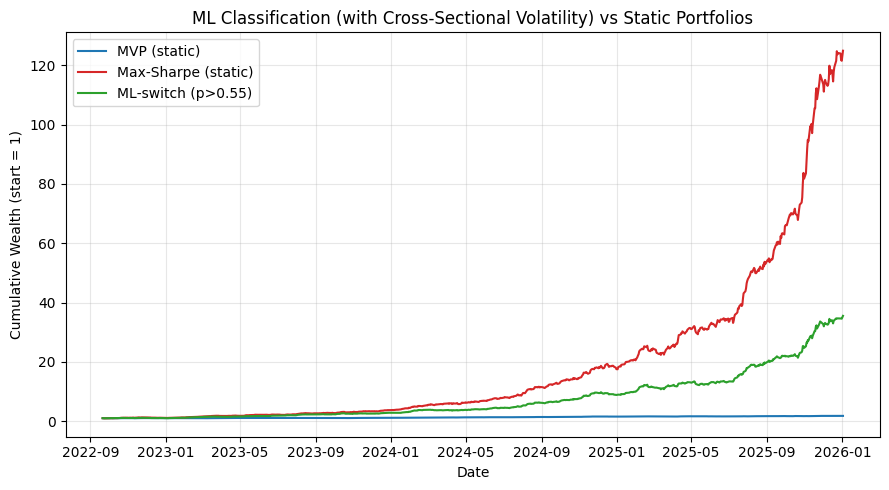

MVP (static)     Total=0.76, AnnRet=0.19, AnnVol=0.08, Sharpe=2.22, MaxDD=-0.06
MaxS (static)    Total=123.94, AnnRet=3.38, AnnVol=0.29, Sharpe=11.55, MaxDD=-0.16
ML (p>0.55)      Total=34.51, AnnRet=1.98, AnnVol=0.25, Sharpe=7.83, MaxDD=-0.14


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ======================================
# 0) LOAD DATA & WEIGHTS
# ======================================

# S&P 500 daily returns
returns = pd.read_excel(
    "sp500_daily_returns.xlsx",
    sheet_name="Sheet1",
    index_col=0,
    parse_dates=True
)

# Load Max‑Sharpe weights
w_max_df = pd.read_excel("sp500_max_sharpe_weights.xlsx", sheet_name="Sheet1")
w_max_df = w_max_df.rename(
    columns={w_max_df.columns[0]: "Ticker", w_max_df.columns[1]: "Weight"}
)

# Load MVP weights
w_mvp_df = pd.read_excel("sp500_mvp_weights.xlsx", sheet_name="Sheet1")
w_mvp_df = w_mvp_df.rename(
    columns={w_mvp_df.columns[0]: "Ticker", w_mvp_df.columns[1]: "Weight"}
)

# Align weights to returns columns
w_max = w_max_df.set_index("Ticker").reindex(returns.columns)["Weight"].to_numpy()
w_mvp = w_mvp_df.set_index("Ticker").reindex(returns.columns)["Weight"].to_numpy()

# ======================================
# 1) BUILD INDEX & FEATURES
# ======================================

# Equal‑weight index as proxy
index_ret = returns.mean(axis=1)
index_ret.name = "IndexRet"

df = pd.DataFrame(index_ret)

# Technical features (time series)
df["Ret_1"]   = df["IndexRet"].shift(1)
df["Ret_2"]   = df["IndexRet"].shift(2)
df["Ret_5"]   = df["IndexRet"].rolling(5).mean()
df["Ret_21"]  = df["IndexRet"].rolling(21).mean()
df["Vol_5"]   = df["IndexRet"].rolling(5).std()
df["Vol_21"]  = df["IndexRet"].rolling(21).std()

# ADVANCED FEATURE: cross‑sectional volatility (dispersion among stocks)
# average cross‑sectional std of stock returns over last 21 days
cs_vol_21 = returns.rolling(21).std().mean(axis=1)   # mean across stocks
df["CSVol_21"] = cs_vol_21

# Classification target: is next‑day index return positive?
df["Target"] = (df["IndexRet"].shift(-1) > 0).astype(int)

# Drop rows with NaNs from lags/rolling
df = df.dropna()

feature_cols = ["Ret_1", "Ret_2", "Ret_5", "Ret_21", "Vol_5", "Vol_21", "CSVol_21"]
X = df[feature_cols].values
y = df["Target"].values
dates = df.index

# ======================================
# 2) TIME‑BASED TRAIN / TEST SPLIT
# ======================================

split_idx = int(len(df) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

# ======================================
# 3) TRAIN CLASSIFIER
# ======================================

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
clf.fit(X_train, y_train)

# Predicted probability that next day is "up"
proba_up = clf.predict_proba(X_test)[:, 1]

# ======================================
# 4) PORTFOLIO RETURNS ON TEST PERIOD
# ======================================

returns_test = returns.loc[dates_test]
R_test = returns_test.to_numpy()

w_mvp_vec = w_mvp.reshape(-1, 1)
w_max_vec = w_max.reshape(-1, 1)

# Daily returns for static portfolios
ret_mvp = (R_test @ w_mvp_vec).flatten()
ret_max = (R_test @ w_max_vec).flatten()

# ======================================
# 5) ML SWITCH RULE (WITH CONFIDENCE)
# ======================================

# If P(up) > threshold → Max‑Sharpe; else → MVP
threshold = 0.55  # slightly lower than 0.6 to allow more switches
ret_ml = np.where(proba_up > threshold, ret_max, ret_mvp)

# ======================================
# 6) CUMULATIVE WEALTH (BUY‑AND‑HOLD STYLE)
# ======================================

initial_capital = 1.0

wealth_mvp = initial_capital * np.cumprod(1 + ret_mvp)
wealth_max = initial_capital * np.cumprod(1 + ret_max)
wealth_ml  = initial_capital * np.cumprod(1 + ret_ml)

wealth_mvp = pd.Series(wealth_mvp, index=dates_test, name="MVP")
wealth_max = pd.Series(wealth_max, index=dates_test, name="Max‑Sharpe")
wealth_ml  = pd.Series(wealth_ml,  index=dates_test, name="ML‑switch")

# ======================================
# 7) PLOT CUMULATIVE WEALTH
# ======================================

plt.figure(figsize=(9, 5))
plt.plot(wealth_mvp.index, wealth_mvp.values, label="MVP (static)", color="tab:blue")
plt.plot(wealth_max.index, wealth_max.values, label="Max‑Sharpe (static)", color="tab:red")
plt.plot(wealth_ml.index,  wealth_ml.values,  label="ML‑switch (p>0.55)", color="tab:green")

plt.ylabel("Cumulative Wealth (start = 1)")
plt.xlabel("Date")
plt.title("ML Classification (with Cross‑Sectional Volatility) vs Static Portfolios")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================
# 8) PERFORMANCE STATS
# ======================================

def perf_stats(port_ret, wealth):
    T = len(port_ret)
    total_ret = wealth[-1] - 1.0
    ann_ret   = wealth[-1] ** (252 / T) - 1.0
    ann_vol   = np.std(port_ret, ddof=1) * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else np.nan
    running_max = np.maximum.accumulate(wealth)
    max_dd = np.min(wealth / running_max - 1.0)
    return total_ret, ann_ret, ann_vol, sharpe, max_dd

stats_mvp = perf_stats(ret_mvp, wealth_mvp.values)
stats_max = perf_stats(ret_max, wealth_max.values)
stats_ml  = perf_stats(ret_ml,  wealth_ml.values)

def pretty_row(name, stats):
    total, ann_ret, ann_vol, sharpe, max_dd = stats
    print(f"{name:16s} "
          f"Total={total:.2f}, "
          f"AnnRet={ann_ret:.2f}, "
          f"AnnVol={ann_vol:.2f}, "
          f"Sharpe={sharpe:.2f}, "
          f"MaxDD={max_dd:.2f}")

pretty_row("MVP (static)", stats_mvp)
pretty_row("MaxS (static)", stats_max)
pretty_row("ML (p>0.55)",  stats_ml)


This chart comes from the ML classification (with cross‑sectional volatility) vs static portfolios code and shows how £1 grows over time under three strategies.
​

The blue line (MVP static) is almost flat, meaning the minimum‑variance portfolio stays very low risk and only grows a little.

The red line (Max‑Sharpe static) grows extremely fast, reaching above 120, showing that the always‑aggressive Max‑Sharpe portfolio earns huge returns but also carries very high risk.

The green line (ML‑switch p>0.55) sits between them: your ML model predicts when the index is likely to go up; on those days it switches into Max‑Sharpe, otherwise it stays in MVP, so the wealth path grows much more than MVP but less than fully aggressive Max‑Sharpe.